In [1]:
%pip install -U -q 'instructor[vertexai]' 'anthropic[vertex]' google-genai openai langgraph langchain_huggingface langchain-community langchain_experimental httpx sentence_transformers

In [2]:
%pip install -U -q neo4j

# Inputs

In [51]:
ontology = """sections:
  Metadata:
  PartI:
    - Business
    - RiskFactor
    - LegalProceeding
    - MineSafety

entities:
  Metadata:
    properties:
      name:
        type: str
        description: Form10K_2023
      type:
        type: str
        description: financial_report
      about:
        type: str
        description: Form 10K Annual report containing company's financial statements and operations
        index: true
      filingDate:
        type: str
        description: Date in YYYY-MM-DD format
      context:
        type: str
        description: Contains high level information about the document processed
        index: true
    relationships:
      ABOUT_COMPANY:
        target: Company
      HAS_PART1:
        target: PartI
  Company:
    properties:
      name:
        type: str
        description: Name of the Company
        unique: true
        required: true
      cik:
        type: str
        description: Cusip Identifier for Company
        unique: true
  PartI:
    relationships:
      HAS_BUSINESS:
        target: Business
      HAS_RISK_FACTOR:
        target: RiskFactor
      HAS_LEGAL_PROCEEDING:
        target: LegalProceeding
      HAS_MINE_SAFETY:
        target: MineSafety
  Business:
    properties:
      description:
        type: str
        description: General business description
      seasonality:
        type: str
        description: Business seasonality patterns
      employees:
        type: int
        description: Number of employees
      regulatoryEnvironment:
        type: str
        description: Regulatory framework description
    relationships:
      HAS_SEGMENT:
        target: BusinessSegment
      HAS_PRODUCT:
        target: Product
      HAS_COMPETITION:
        target: Company
      HAS_RAW_MATERIAL:
        target: RawMaterial
      HAS_INTELLECTUAL_PROPERTY:
        target: IntellectualProperty
  BusinessSegment:
    properties:
      name:
        type: str
        description: Name of the segment
        unique: true
        required: true
  Product:
    properties:
      name:
        type: str
        description: Name of the product
        unique: true
        required: true
  RawMaterial:
    properties:
      name:
        type: str
        description: Name of the raw material
        unique: true
        required: true
  IntellectualProperty:
    properties:
      name:
        type: str
        description: Name of the IntellectualProperty
        unique: true
        required: true
  RiskFactor:
    properties:
      name:
        type: str
        description: Risk factor name
        unique: true
        required: true
      description:
        type: str
        description: General risk description
      potentialImpact:
        type: str
        description: Potential impact of the risk on business
      mitigationStrategy:
        type: str
        description: Risk mitigation strategy
    relationships:
      HAS_RISK_CATEGORY:
        target: RiskCategory
  RiskCategory:
    properties:
      name:
        type: str
        description: Name of the Risk Category
        unique: true
        required: true
  LegalProceeding:
    properties:
      name:
        type: str
        description: Legal proceeding name
        unique: true
        required: true
      description:
        type: str
        description: Legal case description
      jurisdiction:
        type: str
        description: Legal jurisdiction
      status:
        type: str
        description: Current proceeding status
      potentialLiability:
        type: str
        description: Potential financial liability
      expectedResolution:
        type: str
        description: Expected resolution timeline
  MineSafety:
    properties:
      name:
        type: str
        description: Mine safety record name
        unique: true
        required: true
      violations:
        type: str
        description: Number of safety violations
      assessments:
        type: str
        description: Number of financial assessments or penalties
    relationships:
      HAS_CITATION:
        target: Citation
  Citation:
    properties:
      name:
        type: str
        description: Citation name
        unique: true
        required: true
      description:
        type: str
        description: Citation description
"""

In [4]:
text = """Title: PART I\n  Title: Items 1 and 2. Business and Properties.\n  Title: General\n  Adams Resources & Energy, Inc. (“AE”) is a publicly traded Delaware corporation organized in 1973. Our common shares are listed on the NYSE American LLC (“NYSE American”) under the ticker symbol “AE”. Through our subsidiaries, we are primarily engaged in crude oil marketing, truck and pipeline transportation of crude oil, and terminalling and storage in various crude oil and natural gas basins in the lower 48 states of the United States (“U.S.”). In addition, we conduct tank truck transportation of liquid chemicals, pressurized gases, asphalt and dry bulk primarily in the lower 48 states of the U.S. with deliveries into Canada and Mexico, and with seventeen terminals across the U.S. We also recycle and repurpose off-specification fuels, lubricants, crude oil and other chemicals from producers in the U.S. Our headquarters are located in 22,197 square feet of office space located at 17 South Briar Hollow Lane, Suite 100, Houston, Texas 77027. Unless the context requires otherwise, references to “we,” “us,” “our,” the “Company” or “AE” are intended to mean the business and operations of Adams Resources & Energy, Inc. and its consolidated subsidiaries.\nWe operate and report in four business segments: (i) crude oil marketing, transportation and storage; (ii) tank truck transportation of liquid chemicals, pressurized gases, asphalt and dry bulk; (iii) pipeline transportation, terminalling and storage of crude oil; and (iv) interstate bulk transportation logistics of crude oil, condensate, fuels, oils and other petroleum products and recycling and repurposing of off-specification fuels, lubricants, crude oil and other chemicals. For detailed financial information regarding our business segments, see Note 9 in the Notes to Consolidated Financial Statements included under Part II, Item 8 of this annual report.\n\n\nTitle: Business Segments\n  Title: Crude Oil Marketing\n  Our crude oil marketing segment consists of the operations of our wholly owned subsidiary, GulfMark Energy, Inc. (“GulfMark”). Our crude oil marketing activities generate revenue from the sale and delivery of crude oil purchased either directly from producers or from others on the open market. We also derive revenue from third party transportation contracts. We purchase crude oil and arrange sales and deliveries to refiners and other customers, primarily onshore in Texas, North Dakota, Michigan, Wyoming, Colorado and Louisiana. 2\nOur crude oil marketing activities includes a fleet of 163 tractor-trailer rigs, the majority of which we own and operate, used to transport crude oil. We also maintain approximately 180 pipeline inventory locations or injection stations. We have the ability to barge crude oil from six crude oil storage facilities along the Intracoastal Waterway of Texas and Louisiana, and we have access to approximately 889,000 barrels of storage capacity at the dock facilities in order to access waterborne markets for our products.\nThe following table shows the age of our owned and leased tractors and trailers within our crude oil marketing segment at December 31, 2023:\n____________________ (1) Includes twenty-seven 2024 tractors, twenty-one 2023 tractors, sixteen 2021 tractors and five 2019 tractors that we lease from third parties under finance lease agreements. (2) Includes two 2024 trailers, one 2007 trailer and two 2004 trailers that we lease from third parties under finance lease agreements. See Note 17 in the Notes to Consolidated Financial Statements for further information.\nWe purchase crude oil at the field (wellhead) level. Volume and price information were as follows for the periods indicated:\n____________________ (1) Reflects the volume purchased from third parties at the field level of operations. 3\nField level purchase volumes depict our day-to-day operations of acquiring crude oil at the wellhead, transporting crude oil, and delivering it to market sales points. We held crude oil inventory at a weighted average composite price as follows at the dates indicated (in barrels):\nWe deliver physical supplies to refinery customers or enter into commodity exchange transactions from time to time to protect from a decline in inventory valuation. During the year ended December 31, 2023, we had sales to two customers that comprised approximately 11.4 percent and 11.1 percent, respectively, of total consolidated revenues. We believe alternative market outlets for our commodity sales are readily available and a loss of any of these customers would not have a material adverse effect on our operations. See Note 19 in the Notes to Consolidated Financial Statements for further information regarding credit risk.\nOperating results for our crude oil marketing segment are sensitive to a number of factors. These factors include commodity location, grades of product, individual customer demand for grades or location of product, localized market price structures, availability of transportation facilities, actual delivery volumes that vary from expected quantities, and the timing and costs to deliver the commodity to the customer.\n\n\nTitle: Transportation\n  Our transportation segment consists of the operations of our wholly owned subsidiary, Service Transport Company (“STC”). STC transports liquid chemicals, pressurized gases, asphalt and dry bulk on a “for hire” basis throughout the continental U.S., and into Canada and Mexico. For deliveries into Mexico, our drivers meet a third party carrier at the border, and the third party contractor delivers the products to the customer within Mexico. We do not own any of the products that we haul; rather we act as a third party carrier to deliver our customers’ products from point A to point B, using predominately our employees and our owned or leased tractors and trailers. However, we also use contracted independent owner operators to provide transportation services. Transportation services are provided to customers under multiple load contracts in addition to loads covered under STC’s standard price list. Our customers include major oil and chemical companies and large and mid-sized industrial companies.\nSTC operates seventeen terminals in ten states: (i) Texas, with terminals in Houston, Corpus Christi, Nederland and Freeport; (ii) Louisiana, with terminals in Baton Rouge (St. Gabriel), St. Rose and Sterlington; (iii) Florida, with terminals in Jacksonville and Tampa; (iv) Augusta, Georgia; (v) Mobile, Alabama; (vi) Charlotte, North Carolina; (vii) Cincinnati, Ohio; (viii) South Charleston, West Virginia; (ix) Memphis, Tennessee; and (x) Illinois, with terminals in East St. Louis and Joliet. The St. Gabriel, Louisiana and the Corpus Christi, Texas terminals are situated on 11.5 acres and 3.5 acres, respectively, that we own, and both include an office building, maintenance bays and tank cleaning facilities.\nTransportation operations are headquartered at a terminal facility situated on 26.5 acres that we own in Houston, Texas. This property includes maintenance facilities, administrative offices and terminal facility, tank wash rack facilities and a water treatment system. Pursuant to regulatory requirements, STC holds a Hazardous Materials Certificate of Registration issued by the U.S. Department of Transportation (“DOT”).\nThe following table shows the age of our owned and leased tractors and trailers within our transportation segment at December 31, 2023:\n____________________ (1) Excludes 90 contracted independent owner operator tractors. (2) Includes fifteen 2024 tractors, thirty-five 2023 tractors and thirty-three 2021 tractors that we lease from third parties under finance lease agreements. (3) Includes fourteen 2024 trailers, twenty-two 2023 trailers, twenty 2020 trailers and twenty 2018 trailers that we lease from third parties under finance lease agreements. See Note 17 in the Notes to Consolidated Financial Statements for further information.\nMiles traveled was as follows for the periods indicated (in thousands):\nAll company and independent contractor tractors are equipped with in-cab communication technology, enabling two-way communications between our dispatch office and our drivers, through both standardized and free-form messaging, including electronic logging. We have also installed electronic logging devices (ELDs) on 100 percent of our tractor fleet. This technology enables us to dispatch drivers efficiently in response to customers’ requests and to provide real-time information to customers about the status of their shipments. We have also equipped our tractor fleet with forward-facing and inward facing event recorders. These cameras are constantly recording the movements of the vehicles, and our management team is alerted via email in the event the unit triggers a G-force event. A snapshot of this recording is then sent to our management team for review.\nSTC holds the American Chemistry Council’s certification as a Responsible Care Management System (“RCMS”) company. The scope of this RCMS certification covers the carriage of bulk liquids throughout STC’s area of operations as well as the tank trailer cleaning facilities and equipment maintenance. Certification was granted based on STC’s conformance to the RCMS’s comprehensive environmental health, safety and security requirements. STC’s quality management process is one of its major assets. The practice of using statistical process control covering safety, on-time performance and customer satisfaction aids continuous improvement in all areas of quality service. 5\nSTC is a Partner in the U.S. Environmental Protection Agency’s (“EPA”) SmartWay Transport Partnership, a national voluntary program developed by the EPA and freight industry representatives to reduce greenhouse gases and air pollution and promote cleaner, more efficient ground freight transportation.\nDuring 2020, STC applied for and received its first bronze star rating from EcoVadis, a global leader in monitoring, benchmarking and enabling sustainability in global supply chains.\nDuring 2022, STC won the National Tank Truck Carriers’ (“NTTC”) Heil Trophy Award for its 2021 efforts. This esteemed award recognizes tank truck operations in North America with the best safety program and safety record for the year. STC claimed NTTC’s Heil Trophy Award in the Harvison division, which spotlights carriers whose trucks traveled more than 15 million miles during the previous year. NTTC’s longest-running safety contest annually recognizes North American for-hire and private tank truck fleets with elite safety programs and records. Winners are determined by their safety records, safety and preventive maintenance programs, personnel safety programs and record, and contributions to tank truck industry and general highway safety causes.\nSTC is a member of Texas TRANSCAER®, a non-profit organization with membership from the chemical, transportation and emergency response industries. The mission of Texas TRANSCAER® is to promote safe transportation and handling of hazardous materials, educate about the safety and security of hazardous materials that are transported through communities, and provide education and training for emergency responders along transportation routes. As members of Texas TRANSCAER®, STC Safety Personnel assist with training events for first responders all over Texas.\nOur strategy is to build long-term relationships with our customers based upon the highest level of customer service, safety and reliability. We believe that our commitment to safety, flexibility, size and capabilities provide us with a competitive advantage over other carriers.\n\n\nTitle: Pipeline and Storage\n  Our pipeline and storage segment consists of the operations of two of our wholly-owned subsidiaries, which constitute the VEX Pipeline System: (i) Victoria Express Pipeline, L.L.C. (“VEX”), which we acquired on October 22, 2020 and which owns the VEX pipeline, and (ii) GulfMark Terminals, LLC (“GMT”), which was formed in October 2020 to hold the related terminal facility assets we acquired with the VEX Pipeline System. The VEX Pipeline System complements our existing storage terminal and dock at the Port of Victoria, where with our crude oil marketing segment, we control approximately 450,000 barrels of storage with three docks.\nThrough 2021, pipeline and storage segment revenues were earned from a third-party shipper under a contract that had been in place at the time of the acquisition, and revenues were also earned from GulfMark, an affiliated shipper. The third-party contract ended in 2021, and all pipeline and storage segment revenues through mid-2023 were earned from GulfMark. In mid-2023, we began receiving revenue from an unaffiliated shipper. We are also currently constructing a new pipeline connection between the VEX Pipeline System and the Max Midstream pipeline system, and we expect to complete construction and place the assets into commercial service during the second half of 2024. In addition, we are exploring new connections with several other pipeline systems, for new crude oil supply opportunities both upstream and downstream of the pipeline, to enhance the crude oil supply and take-away capability of the system.\nVolume information was as follows for the periods indicated (in barrels per day):\nThe VEX Pipeline System, with truck and storage terminals at both Cuero and the Port of Victoria, Texas, is a crude oil and condensate pipeline system, which connects the heart of the Eagle Ford Basin to the Gulf Coast waterborne market. The VEX Pipeline System includes 56 miles of 12-inch pipeline, which spans DeWitt County to Port of Victoria in Victoria County, Texas, with approximately 400,000 barrels of above ground storage at its two terminals. The pipeline system has a current capacity of 90,000 barrels per day and is regulated by the Federal Energy Regulatory Commission (“FERC”) and the Texas Railroad Commission. The VEX Pipeline System can receive crude oil by pipeline and truck, and has downstream pipeline connections to two terminals today, with potential for additional downstream connection opportunities in the future.\nThe Cuero terminal has 40,000 barrels per day of offload capacity via eight truck unloading stations, with two 100,000-barrel storage tanks and one 16,000-barrel storage tank. The Port of Victoria terminal has 30,000 barrels per day of truck offload capacity via six truck unloading stations and water access via two barge docks, which have been leased from the Port Authority in Victoria. The Port of Victoria has four 50,000-barrel storage tanks and one 10,000-barrel storage tank.\nThe VEX Pipeline System supports GulfMark’s Gulf Coast region crude oil supply and marketing business and integrates into GulfMark’s value chain, serving as the link between producers/operators and our end-user markets we supply directly along the Gulf Coast waterborne market. We have the opportunity to increase our efficiency by more effectively managing the pipeline and terminalling portion of our overall transportation costs.\n\n\nTitle: Logistics and Repurposing\n  Our logistics and repurposing segment consists of the operations of two of our wholly-owned subsidiaries, Firebird and Phoenix, which we acquired on August 12, 2022. Firebird is headquartered in Humble, Texas, and currently operates seven terminal locations throughout Texas. Firebird transports crude oil, condensate, fuels, oils and other petroleum products on a “for hire” basis largely in the Eagle Ford basin. We do not own any of the products that we haul through Firebird; rather we act as a third-party carrier to deliver our customers’ products from point A to point B, using predominately our employees and our owned or leased tractors and trailers. However, we also use contracted independent owner-operators to provide transportation services. Firebird provides transportation services to customers under multiple load contracts in addition to loads covered under its standard price list. Our customers include major oil and chemical companies and large and mid-sized industrial companies. Firebird provides transportation services to Phoenix, and crude oil transportation services to GulfMark, when additional trucking capacity is required.\nPhoenix is also headquartered in Humble, Texas. Phoenix repurposes and finds beneficial uses for off-specification fuels, lubricants, crude oil and other chemicals from producers in the U.S. With an advanced laboratory, sophisticated technology, and access to an expansive fleet of trucks, Phoenix can provide a solution for customers needing help managing off-specification fuels or oils. In addition to the removal from the customer site, Phoenix markets these refinery and plant co-products into the fuels or feedstock markets. Phoenix markets on approximately six different levels, ranging from heavy fuel oils to light-end naphthas. Phoenix utilizes Firebird’s fleet to assist in the transportation of these products, and has begun to utilize STC to also assist in the transportation of these products.\nOn May 4, 2023, we acquired approximately 10.6 acres of land in the Gulf Inland Industrial Park, located in Dayton, Texas, for approximately $1.8 million to build a new processing facility for Phoenix with rail spur and siding, product storage, and truck rack. Phoenix intends to build new infrastructure to service its existing customers and to create opportunities for growing the business. Phoenix also plans to relocate its headquarters from Humble, Texas to this new location. We expect to break ground on the Dayton facility during the second quarter of 2024. When completed, this facility will allow us to operate our rail and trucking business more efficiently, as well as open up opportunities to process a wider variety of products. 7\nThe following table shows the age of our owned and leased tractors and trailers within our logistics and repurposing segment at December 31, 2023:\n____________________ (1) Excludes 10 contracted independent owner operator tractors. (2) Includes six 2024 tractors and two 2023 tractors that we lease from third parties under finance lease agreements. See Note 17 in the Notes to Consolidated Financial Statements for further information.\nAll company and independent tractors in this segment are equipped with similar in-cab communication technology and event recorders as our STC tractors, described above under “—Transportation”. All tractors are also equipped with electronic logs.\n\n\nTitle: Investment in Unconsolidated Affiliate\n  We own an approximate 15 percent equity interest (less than 3 percent voting interest) in VestaCare, Inc., a California corporation (“VestaCare”), through Adams Resources Medical Management, Inc. (“ARMM”), a wholly owned subsidiary. We acquired our interest in VestaCare in April 2016 for a $2.5 million cash payment, which we impaired in 2017. VestaCare provides an array of software as a service (SaaS) electronic payment technologies to medical providers, payers and patients including VestaCare’s product offering, VestaPay™. VestaPay™ allows medical care providers to structure fully automated and dynamically updating electronic payment plans for their patients. We do not currently have any plans to pursue additional medical-related investments. See Note 2 in the Notes to Consolidated Financial Statements for further information.\n\n\nTitle: Competition\n  In all phases of our operations, we encounter strong competition from a number of regional and national entities. Many of these competitors possess financial resources substantially in excess of ours and may have a more expansive geographic footprint than we have. We face competition principally in establishing trade credit, pricing of available materials, quality of service and location of service. Our strategy is to build long-term partnerships with our customers based upon the safety of our operations, reliability and superior customer service.\nOur crude oil marketing segment and our logistics and repurposing segment compete with major crude oil companies and other large industrial concerns that own or control significant refining, midstream and marketing facilities. These major crude oil companies may offer their products to others on more favorable terms than those available to us.\nIn the trucking industry, the tank lines transportation business is extremely competitive and fragmented. Price, service and location are the major competitive factors in each local market.\n\n\nTitle: Seasonality\n  In the trucking industry, revenue has historically followed a seasonal pattern for various commodities and customer businesses. Peak freight demand has historically occurred in the months of September, October and November. After the December holiday season and during the remaining winter months, freight volumes are typically lower as many customers reduce shipment levels. Operating expenses have historically been higher in the winter months primarily due to decreased fuel efficiency, increased cold weather-related maintenance costs, and increased insurance claim costs attributable to adverse winter weather conditions. Revenue can also be impacted by weather, holidays and the number of business days that occur during a given period, as revenue is directly related to the available working days of shippers.\nAlthough our crude oil marketing segment and our logistics and repurposing segment are not materially affected by seasonality, certain aspects of our operations are impacted by seasonal changes, such as tropical weather conditions, energy demand in connection with heating and cooling requirements and the summer driving season.\n\n\nTitle: Inflation and Other Cost Increases\n  Most of our operating expenses are inflation-sensitive, with inflation generally producing increased costs of operations. We are experiencing increased inflation in the costs of various goods and services we use to operate our business, including the cost of equipment, tires, repairs and maintenance and compensation paid to drivers. These and other factors may continue to impact our costs, expenses and capital expenditures, and could continue to have an impact on customer demand for our services as customers manage the impact of inflation on their resources.\nIn order to mitigate the effect of price increases on our business, from time to time, we enter into monthly commodity purchase and sale contracts for up to 300,000 barrels of crude oil and commodity purchase contracts for the purchase of diesel fuel. See Note 13 in the Notes to Consolidated Financial Statements for further information regarding these contracts.\nIn addition to inflation, fluctuations in fuel prices can affect profitability. Most of our transportation contracts with customers contain fuel surcharge provisions. Although we historically have been able to pass through most long-term increases in fuel prices and operating taxes to transportation customers in the form of surcharges and higher rates, there is no guarantee that this will be possible in the future. In addition, we are not able to obtain the benefit of a fuel surcharge on the crude oil marketing segment private fleet. See “Part I, Item 1A. Risk Factors .”\n\n\nTitle: Regulatory Matters\n  We are subject to an extensive variety of evolving federal, state and local laws, rules and regulations governing the storage, transportation, manufacture, use, discharge, release and disposal of product and contaminants into the environment, or otherwise relating to the protection of the environment. Below is a non-exclusive listing of the environmental laws, each as amended, that potentially impact our business.\n• The Solid Waste Disposal Act, as amended by the Resource Conservation and Recovery Act of 1976. • The Clean Water Act of 1972. • The Clean Air Act of 1970. • The Comprehensive Environmental Response Compensation and Liability Act. • The Toxic Substances Control Act of 1976. • The Emergency Planning and Community Right-to-Know Act. • The Occupational Safety and Health Act of 1970. • Texas Clean Air Act. • Texas Solid Waste Disposal Act. • Texas Water Code. • Texas Oil Spill Prevention and Response Act of 1991.\n\n\nTitle: Railroad Commission of Texas (“RRC”)\n  The RRC regulates, among other things, the drilling and operation of crude oil and natural gas wells, the operation of crude oil and natural gas pipelines, the disposal of crude oil and natural gas production wastes, and certain storage of crude oil and natural gas in Texas. RRC regulations govern the generation, management and disposal of waste from these crude oil and natural gas operations and provide for the cleanup of contamination from crude oil and natural gas operations. These regulations primarily affect our crude oil marketing segment, our pipeline and storage segment and our logistics and repurposing segment.\n\n\nTitle: Louisiana Office of Conservation\n  The Louisiana Office of Conservation has primary statutory responsibility for regulation and conservation of crude oil, natural gas, and other natural resources in the State of Louisiana. Their objectives are to (i) regulate the exploration and production of crude oil, natural gas and other hydrocarbons, (ii) control and allocate energy supplies and distribution thereof, and (iii) protect public safety and the environment from oilfield waste, including the regulation of underground injection and disposal practices.\n\n\nTitle: Trucking Activities\n  Our crude oil marketing, transportation and logistics and repurposing businesses operate truck fleets pursuant to the authority of the DOT and various state authorities. Trucking operations must be conducted in accordance with various laws relating to pollution and environmental control as well as safety requirements prescribed by states and by the DOT. Matters such as weight and dimension of equipment are also subject to federal and state regulations. These regulations also require mandatory drug testing of drivers and require certain tests for alcohol levels in drivers and other safety personnel. The regulations also impose hours of service restrictions and mandatory rest periods. The trucking industry is subject to possible regulatory and legislative changes, such as increasingly stringent environmental requirements or limits on vehicle weight and size. Regulatory change may affect the economics of the industry by requiring changes in operating practices or by changing the demand for private and common or contract carrier services or the cost of providing truckload services. In addition, our tank wash facilities are subject to increasingly stringent local, state and federal environmental regulations.\nWe have implemented security procedures for drivers and terminal facilities. Satellite tracking transponders installed in the power units are used to communicate emergencies to us and to maintain constant information as to the unit’s location. If necessary, our terminal personnel will notify local law enforcement agencies. In addition, we are able to advise a customer of the status and location of their loads. Remote cameras and enhanced lighting coverage in the staging and parking areas have augmented terminal security. We have a focus on safety in the communities in which we operate, including leveraging camera technology to enhance driver behavior and awareness. Our crude oil marketing and transportation businesses are Partners in the EPA’s SmartWay Transport Partnership, a national voluntary program developed by the EPA and freight industry representatives to reduce greenhouse gases and air pollution and promote cleaner, more efficient ground freight transportation.\n\n\nTitle: FERC Regulation\n  The VEX Pipeline System, which we acquired in 2020, is regulated by the FERC as a common carrier interstate pipeline under the Interstate Commerce Act (“ICA”), the Energy Policy Act of 1992, and related rules and orders. The ICA and its implementing regulations give the FERC authority to regulate the rates charged for service on interstate common carrier pipelines and generally require the rates and practices of interstate liquids pipelines to be just, reasonable, not unduly discriminatory and not unduly preferential. The ICA also requires tariffs that set forth the rates a common carrier pipeline charges for providing transportation services on its interstate common carrier liquids pipelines, as well as the rules and regulations governing these services, to be maintained on file with the FERC and posted publicly. The Energy Policy Act of 1992 and its implementing regulations allow interstate common carrier liquids pipelines to annually index their rates up to a prescribed ceiling level and require that such pipelines index their rates down to the prescribed ceiling level if the index is negative. In addition, the FERC retains cost-of-service ratemaking, market-based rates and settlement rates as alternatives to the indexing approach. The ICA also permits interested parties to challenge new or changed rates and gives the FERC the authority to change rates and order refunds.\nChanges in the FERC’s methodologies for approving rates could adversely affect us. In addition, challenges to our regulated rates could be filed with the FERC and future decisions by the FERC regarding our regulated rates could adversely affect our cash flows. We believe the transportation rates currently charged by our interstate liquids pipeline is in accordance with the ICA and applicable FERC regulations. However, we cannot predict the rates we will be allowed to charge in the future for transportation services by such pipeline.\n\n\nTitle: Pipeline Safety\n  We are subject to regulation by the DOT as authorized under various provisions of Title 49 of the United States Code and comparable state statutes relating to the design, installation, testing, construction, operation, replacement and management of our pipeline facilities. Among other things, these statutes also require companies that own or operate pipelines to permit access to and copying of pertinent records, file certain reports and provide other information as required by the U.S. Secretary of Transportation. The DOT regulates natural gas and hazardous liquids pipelines through its Pipeline and Hazardous Materials Safety Administration (“PHMSA”). PHMSA continues to implement and enforce these rules and has discretion to assess significant fines should non-compliance be determined.\nThe development and/or implementation of more stringent requirements pursuant to DOT regulations, as well as any implementation of the PHMSA rules thereunder or reinterpretation of guidance by PHMSA or any state agencies with respect thereto, may result in us incurring significant and unanticipated expenditures to comply with such standards. Until any such proposed regulations or guidance are finalized or issued, the impact on our operations, if any, cannot be known.\n\n\nTitle: Regulatory Status and Potential Environmental Liability\n  Our operations and facilities are subject to numerous federal, state and local environmental laws and regulations including those described above, as well as associated permitting and licensing requirements. We regard compliance with applicable environmental regulations as a critical component of our overall operation, and devote significant attention to providing quality service and products to our customers, protecting the health and safety of our employees, and protecting our facilities from damage.\nWe have, where appropriate, implemented operating procedures at each of our facilities designed to assure compliance with environmental laws and regulation. However, given the nature of our business, we are subject to environmental risks, and the possibility remains that our ownership of our facilities and our operations and activities could result in civil or criminal enforcement and public as well as private actions against us, which may necessitate or generate mandatory cleanup activities, revocation of required permits or licenses, denial of application for future permits, and/or significant fines, penalties or damages, any and all of which could have a material adverse effect on us. See “Item 1A. Risk Factors ” for further discussion.\n\n\nTitle: Human Capital Resources\n  Title: General\n  Our business strategy and ability to serve customers relies on employing talented professionals and attracting, training, developing and retaining a skilled workforce.\nThere is substantial competition for qualified truck drivers in the trucking industry. Recruitment, training, and retention of a professional driver workforce is essential to our continued growth and fulfillment of customer needs. We hire qualified professional drivers who hold a valid commercial driver’s license, satisfy applicable federal and state safety performance and measurement requirements, and meet our hiring criteria. These guidelines relate primarily to safety history, road test evaluations, and various other evaluations, which include physical examinations and mandatory drug and alcohol testing. We provide comfortable, late model equipment, encourage direct communication with management, pay competitive wages and benefits, and offer other incentives intended to encourage driver safety, retention and long-term employment. Prior to being released for individual duty, each new hire is required to undergo a mandatory training and evaluation period by a certified driver trainer/instructor. The length of this training period will be dependent on experience and the new hire adaptation to company policies and procedures.\n\n\nTitle: Employees\n  At December 31, 2023, we employed 741 persons, of which 485, or 65 percent, were truck drivers. We believe our employee relations are satisfactory, and none of our employees are subject to union contracts or part of a collective bargaining unit.\n\n\nTitle: Independent Contractors\n  In addition to company drivers, we enter into contracts with independent contractors, who provide a tractor and a driver and are responsible for all operating expenses in exchange for an agreed upon fee structure. At December 31, 2023, we had 100 independent contractor operated tractors in our transportation and logistics and repurposing segments, which comprised approximately 17 percent of our professional truck driving fleet.\n\n\nTitle: Health and Safety\n  Safety is one of our guiding principles as we are committed to providing our employees a safe working environment. We have implemented safety programs and management practices to promote a culture of safety. We are continuously working toward maintaining a strong safety culture to emphasize the importance of our employees’ role in identifying, mitigating and communicating safety risks.\nIn light of the current COVID-19 pandemic, we have updated and implemented our pandemic plan to ensure the continuation of safe and reliable service to customers and to maintain the safety of our employees, as well as to incorporate any new governmental guidance and rules and regulations regarding workplace safety. Since the beginning of the pandemic, we have been deemed an essential entity by virtue of the transportation services we provide.\n\n\nTitle: Diversity and Inclusion\n  We are committed to providing a professional work environment where all employees are treated with respect and dignity and provided with equal opportunities. We do not discriminate based upon race, religion, color, national origin, gender (including pregnancy, childbirth, or related medical conditions), sexual orientation, gender identity, gender expression, age, status as a protected veteran, status as an individual with a disability or other applicable legally protected characteristics. We also support the hiring of veterans and are honored to provide opportunities to men and women who have served their respective countries .\nWe also partner with the Women in Trucking Association to support our efforts to advance the careers of women and gender diversity. It is our goal to empower the professional development of all employees and to operate from a mindset of sharing, caring, inclusion and equity.\nWe support basic human rights throughout our business enterprise and prohibit the use of child, compulsory or forced labor. Our employees are strictly prohibited from using our equipment to transport, or our facilities to shelter, unauthorized persons, or to take any other act in support of human trafficking or human rights abuses. Employees are required to immediately report any human trafficking concerns to the appropriate law enforcement agency.\nWe work with Truckers Against Trafficking (“TAT”) to train all over-the-road drivers on how to spot and report signs of human trafficking. Our drivers receive training from TAT and become registered as TAT trained and certified.\n\n\nTitle: Benefits\n  Our compensation and benefits programs are designed to attract, retain and motivate our employees and to reward them for their services and success. In addition to providing competitive salaries and other compensation opportunities, we offer comprehensive and competitive benefits to our eligible employees including, depending on location, life and health (medical, dental and vision) insurance, prescription drug benefits, flexible spending accounts, parental leave, disability coverage, mental and behavioral health resources, paid time off and retirement savings plan.\n\n\nTitle: Available Information\n  We electronically file certain documents with the U.S. Securities and Exchange Commission (“SEC”). We file Annual Reports on Form 10-K; Quarterly Reports on Form 10-Q; and Current Reports on Form 8-K (as appropriate); along with any related amendments and supplements thereto.\nWe also make available free of charge, through the “Investor Relations” link on our website, www.adamsresources.com , our Annual Reports on Form 10-K, Quarterly Reports on Form 10-Q, Current Reports on Form 8-K and any amendments to those reports filed or furnished pursuant to Section 13(a) or 15(d) of the Exchange Act, simultaneously with or as soon as reasonably practicable after filing such materials with, or furnishing such materials to, the SEC. The information on our website, or information about us on any other website, is not incorporated by reference into this report.\n\n\nTitle: Item 1A. Risk Factors .\n  An investment in our common stock involves certain risks. If any of the following key risks were to occur, it could have a material adverse effect on our financial position, results of operations and cash flows. In any such circumstance and others described below, the trading price of our securities could decline and you could lose part or all of your investment.\n\n\nTitle: Risk Related to our Business\n  Title: Difficulty in attracting and retaining drivers could negatively affect our operations and limit our growth.\n  There is substantial competition for qualified personnel, particularly drivers, in the trucking industry. We operate in geographic areas where there is currently a shortage of drivers. Regulatory requirements, including electronic logging, and an improving U.S. jobs market, could continue to reduce the number of eligible drivers in our markets. Any shortage of drivers could result in temporary under-utilization of our equipment, difficulty in meeting our customers’ demands and increased compensation levels, each of which could have a material adverse effect on our business, results of operations and financial condition. A loss of qualified drivers could lead to an increased frequency in the number of accidents, potential claims exposure and, indirectly, insurance costs.\nDifficulty in attracting qualified drivers could also require us to limit our growth. Our strategy is to grow in part by expanding existing customer relationships into new markets. However, we may have difficulty finding qualified drivers on a timely basis when presented with new customer opportunities, which could result in our inability to accept or service this business or could require us to increase the wages we pay in order to attract drivers. If we are unable to hire qualified drivers to service business opportunities in new markets, we may have to temporarily send drivers from existing terminals to those new markets, causing us to incur significant costs relating to out-of-town driver pay and expenses. In making acquisitions and converting private fleets, some of the drivers in those fleets may not meet our standards, which would require us to find qualified drivers to replace them. If we are unable to find and retain such qualified drivers on terms acceptable to us, we may be forced to forgo opportunities to expand or maintain our business.\n\n\nTitle: Our business is dependent on the ability to obtain trade and other credit .\n  Our future development and growth depends, in part, on our ability to successfully obtain credit from suppliers and other parties. We rely on trade credit arrangements as a significant source of liquidity for capital requirements not satisfied by operating cash flow, our revolving line of credit or letters of credit. If global financial markets and economic conditions disrupt and reduce stability in general, and the solvency of creditors specifically, the availability of funding from credit markets would be reduced as many lenders and institutional investors would enact tighter lending standards, refuse to refinance existing debt on terms similar to current debt or, in some cases, cease to provide funding to borrowers. These issues coupled with weak economic conditions would make it more difficult for us, our suppliers and our customers to obtain funding. If we are unable to obtain trade or other forms of credit on reasonable and competitive terms, the ability to continue our marketing businesses, pursue improvements, and continue future growth will be limited. We cannot assure you that we will be able to maintain future credit arrangements on commercially reasonable terms.\n\n\nTitle: We have a concentrated customer base and receive half of our revenue from a small number of customers .\n  Our largest customers consist of large multinational integrated crude oil companies and independent domestic refiners of crude oil. In addition, we transact business with independent crude oil producers, major chemical companies, crude oil trading companies and a variety of commercial energy users. Within this group of customers, we derive approximately 50 percent of our revenue from four to five large crude oil refining customers. During the year ended December 31, 2023, we had sales to two customers that comprised approximately 11.4 percent and 11.1 percent, respectively, of total consolidated revenues. While we believe alternative markets are available, our financial condition and results of operations may be adversely affected if we lose these customers or if these customers experience operating and financial performance decline or there is a decrease in their demand.\n\n\nTitle: The financial soundness of customers could affect our business and operating results.\n  Constraints in the financial markets and other macro-economic challenges that might affect the economy of the U.S. and other parts of the world could cause our customers to experience cash flow concerns. As a result, if our customers’ operating and financial performance deteriorates, or if they are unable to make scheduled payments or obtain credit, customers would not be able to pay, or may delay payment of, accounts receivable owed to us. Any inability of current and/or potential customers to pay for services may adversely affect our financial condition and results of operations.\n\n\nTitle: We generate revenues under contracts that must be renegotiated periodically.\n  Substantially all of our revenues are generated under contracts which expire periodically or which must be frequently renegotiated, extended or replaced. Whether these contracts are renegotiated, extended or replaced is often subject to factors beyond our control. These factors include sudden fluctuations in crude oil and natural gas prices, our counterparties’ ability to pay for or accept the contracted volumes and, most importantly, an extremely competitive marketplace for the services we offer. We cannot assure you that the costs and pricing of our services can remain competitive in the marketplace or that we will be successful in renegotiating our contracts.\n\n\nTitle: Anticipated or scheduled volumes will differ from actual or delivered volumes.\n  Our crude oil marketing business purchases initial production of crude oil at the wellhead under contracts requiring us to accept the actual volume produced. We generally resell this production under contracts requiring a fixed volume to be delivered. We estimate our anticipated supply and match that supply estimate for both volume and pricing formulas with committed sales volumes. Since actual wellhead volumes produced will rarely equal anticipated supply, our marketing margins may be adversely impacted. In many instances, any losses resulting from the difference between actual supply volumes compared to committed sales volumes must be absorbed by us.\n\n\nTitle: We may face opposition to the operation of our pipeline and facilities from various groups.\n  We may face opposition to the operation of our pipeline and facilities from environmental groups, landowners, tribal groups, local groups and other advocates. Such opposition could take many forms, including organized protests, attempts to block or sabotage our operations, intervention in regulatory or administrative proceedings involving our assets, or lawsuits or other actions designed to prevent, disrupt or delay the operation of our assets and business. In addition, acts of sabotage or eco-terrorism could cause significant damage or injury to people, property or the environment or lead to extended interruptions of our operations. Any such event that interrupts the revenues generated by our operations, or which causes us to make significant expenditures not covered by insurance, could reduce our cash available for paying dividends to our shareholders and, accordingly, adversely affect our financial condition and the market price of our securities.\n\n\nTitle: Our pipeline integrity program as well as compliance with pipeline safety laws and regulations may impose significant costs and liabilities on us.\n  If we were to incur material costs in connection with our pipeline integrity program or pipeline safety laws and regulations, those costs could have a material adverse effect on our financial condition, results of operations and cash flows.\nThe DOT requires pipeline operators to develop integrity management programs to comprehensively evaluate their pipelines. The majority of the costs to comply with this integrity management rule are associated with pipeline integrity testing and any repairs found to be necessary as a result of such testing. Changes such as advances in pipeline inspection tools and identification of additional threats to a pipeline’s integrity, among other things, can have a significant impact on the costs to perform integrity testing and repairs. We will continue our pipeline integrity testing programs to assess and maintain the integrity of our pipeline. The results of these tests could cause us to incur significant and unanticipated capital and operating expenditures for repairs or upgrades deemed necessary to ensure the continued safe and reliable operation of our pipeline.\n\n\nTitle: The rates of our regulated assets are subject to review and possible adjustment by federal and state regulators, which could adversely affect our revenues.\n  The FERC regulates the tariff rates and terms and conditions of service for our interstate common carrier liquids pipeline operations. To be lawful under the ICA, interstate tariff rates, terms and conditions of service must be just and reasonable and not unduly discriminatory, and must be on file with the FERC. In addition, pipelines may not confer any undue preference upon any shipper. Shippers may protest (and the FERC may investigate) the lawfulness of new or changed tariff rates. The FERC can suspend those tariff rates for up to seven months. It can also require refunds of amounts collected pursuant to rates that are ultimately found to be unlawful and prescribe new rates prospectively. The FERC and interested parties can also challenge tariff rates that have become final and effective. The FERC can also order new rates to take effect prospectively and order reparations for past rates that exceed the just and reasonable level up to two years prior to the date of a complaint. Due to the complexity of rate making, the lawfulness of any rate is never assured. A successful challenge of our rates could adversely affect our revenues.\nThe intrastate liquids pipeline transportation services we provide are subject to various state laws and regulations that apply to the rates we charge and the terms and conditions of the services we offer. Although state regulation typically is less onerous than FERC regulation, the rates we charge and the provision of our services may be subject to challenge.\n\n\nTitle: Environmental liabilities and environmental regulations may have an adverse effect on us.\n  Our business is subject to environmental hazards such as spills, leaks or any discharges of petroleum products and hazardous substances. These environmental hazards could expose us to material liabilities for property damage, personal injuries, and/or environmental harms, including the costs of investigating, remediating and monitoring contaminated properties.\nFederal, state and local environmental laws and regulations govern many aspects of our business, such as transportation and waste management, as well as permitting and licensing requirements. There are no assurances that we will be able to comply with conditions or restrictions contained in any permit issued by a regulatory agency governing our operations. Further, additional conditions may be included in the renewal or amendment of any permit issued to or held by us, and any permit that has been issued remains subject to renewal, modification, suspension, or revocation by the agency with jurisdiction. Compliance with environmental laws and regulations can require significant costs or may require a decrease in business activities. Moreover, noncompliance with these laws and regulations could subject us to significant administrative, civil, and/or criminal fines and/or penalties, as well as potential injunctive relief. In many instances, liability is often “strict,” meaning it is imposed without a requirement of intent or fault by the regulated entity, and this can include not only fines and penalties, but also liability relating to the cleanup of contaminated properties. See discussion under “Item 1 and 2. Business and Properties — Regulatory Matters ,” for additional detail.\n\n\nTitle: Restrictions and covenants in our Credit Agreement reduce operating flexibility and create the potential for defaults, which could adversely affect our business, financial condition and results of operations.\n  Under our credit agreement with Cadence Bank (“Credit Agreement”), we may borrow or issue letters of credit in an aggregate of up to $60.0 million under a revolving credit facility, subject to our compliance with certain financial covenants. The Credit Agreement also includes a term loan in the initial principal amount of $25.0 million. At December 31, 2023, we had $21.9 million of borrowings outstanding under the term loan and $13.0 million of letters of credit issued under the Credit Agreement.\nThe terms of our Credit Agreement restrict our ability to, among other things (and subject in each case, to various exceptions and conditions):\n• incur additional indebtedness, • create additional liens on our assets, • make certain investments, • pay dividends, • dispose of our assets or engage in a merger or other similar transaction, or • engage in transactions with affiliates.\nOur ability to comply with the financial covenants in the Credit Agreement depends on our operating performance, which in turn depends significantly on prevailing economic, financial and business conditions and other factors that are beyond our control. Therefore, despite our best efforts and execution of our strategic plan, we may be unable to comply with these financial covenants in the future.\nAt December 31, 2023, we were in compliance with all financial covenants. However, if in the future there are economic declines, we can make no assurance that these declines will not negatively impact our financial results and, in turn, our ability to meet these financial covenant requirements. If we fail to comply with certain covenants, including our financial covenants, we could be in default under our Credit Agreement. In the event of such a default, the lenders under the Credit Agreement are entitled to take various actions, including the acceleration of the maturity of all loans and to take all actions permitted to be taken by a secured creditor against the collateral under the related security documents and applicable law. Any of these events could adversely affect our business, financial condition and results of operations.\nIn addition, these restrictions reduce our operating flexibility and could prevent us from exploiting certain investment, acquisition, or other time-sensitive business opportunities.\n\n\nTitle: Our indebtedness, along with the variable interest rates we pay on our indebtedness, could adversely affect our business and our ability to execute our business strategy.\n  We have a $25.0 million term loan and a revolving credit facility that permits us to borrow up to $60.0 million in additional loans and letters of credit (with letters of credit not to exceed $30.0 million). Our Credit Agreement bears interest at variable rates, which will generally change as interest rates change. During our fiscal year ended December 31, 2023, we experienced, and we may continue to experience, increases in interest on our variable rate loans. If interest rates increase and we do not hedge such variable rates, our debt service obligations will increase even when the amount borrowed may stay the same. In an increasing interest rate environment, we bear the risk that the rates we are charged by the lenders under our Credit Agreement will increase faster than the earnings and cash flow of our business, which could reduce our profitability, adversely affect our ability to service our debt, cause us to breach covenants in our Credit Agreement, or divert capital that we would otherwise be able to use to grow the business or declare dividends in order to fulfill our debt service requirements.\n\n\nTitle: Risk Related to our Industry\n  Title: Public health emergencies, including the COVID-19 pandemic, could disrupt or continue to disrupt our operations and adversely impact our business and financial results.\n  The COVID-19 pandemic resulted in a number of adverse economic effects, including changes in consumer behavior related to the economic slowdown, disruption of historical supply and demand patterns, and changes in the work force, which has affected our business and the businesses of our customers and suppliers. These adverse economic effects of the COVID-19 outbreak have impacted our operations and services.\nThe COVID-19 pandemic has created business challenges primarily related to changes in the work force, which have impacted our ability to hire and retain qualified truck drivers, and created issues with the supply chain, resulting in delays in purchasing items, including new tractors. While demand for transportation of products and demand for crude oil has largely rebounded from 2020 levels during the initial stages of the pandemic, our growth has been limited in certain markets by the availability of truck drivers.\nWe have been seeking ways to overcome supply shortages in tractors, by additional maintenance to extend vehicle lives, shortages in tires and other inventory by having additional items on hand and increases in the price of diesel fuel by continuing to pass costs through to customers or attempting to reduce costs through efficiencies. If the pandemic continues to affect global supply chains and fuel costs, we may be unable to pass costs through to customers or maintain our operating margins.\nWe continue to monitor the effect of the pandemic on our financial condition, liquidity, operations, customers, industry and workforce. If the pandemic and its economic effects continue or worsen, particularly in light of new and variant strains of the virus and the plateau of vaccination rates, it may have a material adverse effect on our results of future operations, financial position and liquidity.\nShould the coronavirus continue to spread, our business operations could be delayed or interrupted. For instance, our operations would be adversely impacted if a number of our administrative personnel, drivers or field personnel are infected and become ill or are quarantined. At this time, we believe that our business would generally be exempted from shelter-in-place orders or other mandated local travel restrictions as an essential service but there can be no assurance as the scope of restrictions imposed by local or state governments.\nWhile the potential economic impact brought by and the duration of public health emergencies such as the coronavirus may be difficult to assess or predict, such emergencies may cause significant disruption of global financial markets, which may reduce our ability to access capital either at all or on favorable terms. In addition, a recession, depression or other sustained adverse market event resulting from the spread or worsening of the coronavirus or other public health emergencies could materially and adversely affect our business and financial results. 18\n\n\nTitle: General economic conditions could reduce demand for chemical-based trucking services.\n  Customer demand for our products and services is substantially dependent upon the general economic conditions for the U.S., which are cyclical in nature. In particular, demand for liquid chemical truck transportation services is dependent on activity within the petrochemical sector of the U.S. economy. Chemical sector demand typically varies with the housing and auto markets as well as the relative strength of the U.S. dollar to foreign currencies. A relatively strong U.S. dollar exchange rate may be adverse to our transportation operation since it tends to suppress export demand for petrochemicals. Conversely, a weak U.S. dollar exchange rate tends to stimulate export demand for petrochemicals.\n\n\nTitle: Fluctuations in crude oil prices could have an adverse effect on us .\n  Our future financial condition, revenues, results of operations and future rate of growth are materially affected by crude oil prices that historically have been volatile and are likely to continue to be volatile in the future. Crude oil prices depend on factors outside of our control. These factors include:\n• supply and demand for crude oil and expectations regarding supply and demand; • political conditions in other crude oil-producing countries, including the possibility of insurgency or war in such areas; • economic conditions in the U.S. and worldwide; • the impact of public health epidemics, like the global coronavirus outbreak beginning in 2020; • governmental regulations and taxation; • the impact of energy conservation efforts; • the price and availability of alternative fuel sources; • weather conditions; • availability of local, interstate and intrastate transportation systems; and • market uncertainty.\n\n\nTitle: Increases in the price of diesel fuel and availability of diesel fuel could have an adverse effect on us.\n  As an integral part of our crude oil marketing, transportation and logistics and repurposing businesses, we operate approximately 605 tractors, and diesel fuel costs are a significant component of our operating expenses. The market price for fuel can be extremely volatile and is affected by a number of economic and political factors. In addition, changes in federal or state regulations can impact the price of fuel, as well as increase the amount we pay in fuel taxes.\nIn our transportation segment, we typically incorporate a fuel surcharge provision in our customer contracts. During periods of high prices, we attempt to recoup rising diesel fuel costs through the pricing of our services. However, our customers may be able to negotiate contracts that minimize or eliminate our ability to pass on fuel price increases. We are also not able to obtain the benefit of a fuel surcharge on the crude oil marketing segment private fleet.\nOur operations may also be adversely affected by any limit on the availability of fuel. Disruptions in the political climate in key oil producing regions in the world, particularly in the event of wars or other armed conflicts, could severely limit the availability of fuel in the U.S. In the event we face significant difficulty in obtaining fuel, our business, results of operations and financial condition would be materially adversely affected.\n\n\nTitle: Insurance and claims expenses, including for self-insured risks, could significantly reduce our earnings.\n  Transportation of hazardous materials involves certain operating hazards such as automobile accidents, explosions, fires and pollution. Any of these operating hazards could cause serious injuries, fatalities or property damage, which could expose us to liability. The payment of any of these liabilities could reduce, or even eliminate, the funds available for other areas. 19\nConsistent with the industry standard, our insurance policies provide limited coverage for losses or liabilities relating to pollution, with broader coverage provided for sudden and accidental occurrences. Insurance might be inadequate to cover all liabilities. Obtaining insurance for our line of business can become difficult and costly. Typically, when insurance cost escalates, we may reduce our level of coverage, and more risk may be retained to offset cost increases.\nBeginning in 2021, we self-insure a significant portion of our claims exposure resulting from auto liability, general liability and workers’ compensation through our wholly owned captive insurance company. Although we reserve for anticipated losses and expenses based on actuarial reviews and periodically evaluate and adjust our claims reserves to reflect our experience, estimating the number and severity of claims, as well as related costs to settle or resolve them, is inherently difficult, and such costs could exceed our estimates. Accordingly, our actual losses associated with insured claims may differ materially from our estimates and adversely affect our financial condition and results of operations in material amounts.\nWe maintain an insurance program for potential losses that are in excess of the amounts that we insure through the captive, as well as potential losses from other categories of claims. Although we believe our aggregate insurance limits should be sufficient to cover our historic or future claims amounts, it is possible that one or more claims could exceed our aggregate coverage limits. If any claim were to exceed our aggregate insurance coverage, we would bear the excess, in addition to the amount in the captive.\nGiven the current claims settlement environment, the amount of commercially available insurance coverage is decreasing, and the premiums for this coverage are increasing significantly. For the foregoing reasons, our insurance and claims expenses may increase, or we could increase our self-insured retention as policies are renewed or replaced. In addition, we may assume additional risk within our captive insurance company that we may or may not reinsure. Our results of operations and financial condition could be materially and adversely affected if (1) our costs or losses significantly exceed our aggregate self-insurance and excess coverage limits, (2) we are unable to obtain affordable insurance coverage in amounts we deem sufficient, (3) our insurance carriers fail to pay on our insurance claims, or (4) we experience a claim for which coverage is not provided.\n\n\nTitle: Counterparty credit default could have an adverse effect on us.\n  Our revenues are generated under contracts with various counterparties, and our results of operations could be adversely affected by non-performance under the various contracts. A counterparty’s default or non-performance could be caused by factors beyond our control. A default could occur as a result of circumstances relating directly to the counterparty, or due to circumstances caused by other market participants having a direct or indirect relationship with the counterparty. We seek to mitigate the risk of default by evaluating the financial strength of potential counterparties; however, despite mitigation efforts, contractual defaults do occur from time to time.\n\n\nTitle: Our business is subject to changing government regulations .\n  Federal, state or local government agencies may impose environmental, labor or other regulations that increase costs and/or terminate or suspend operations. Our business is subject to federal, state and local laws and regulations. These regulations relate to, among other things, transportation of crude oil and natural gas. Existing laws and regulations could be changed, and any changes could increase costs of compliance and costs of operations.\n\n\nTitle: Climate change legislation or regulations restricting emissions of “greenhouse gases” (“GHGs”) could result in increased operating or compliance costs and reduced demand for the crude oil we market and transport.\n  More stringent laws and regulations relating to climate change and GHGs may be adopted which could cause us to incur material expenses to comply with such laws and regulations. In 2014, the U.S. Supreme Court upheld the EPA’s authority to regulate GHG emissions. Pursuant to EPA regulations, a permit governing GHG emission may be required, in conjunction with authorization of emissions of other pollutants. The EPA also requires, pursuant to its GHG Reporting Rule, specified large GHG emission sources to report their GHG emissions. Regulated sources include, without limitation, onshore and offshore crude oil and natural gas production facilities and onshore crude oil and natural gas processing, transmission, storage and distribution facilities. Reporting of GHG emissions from such large facilities is required on an annual basis. We do not presently operate any such large GHG emissions sources, but if we were to do so, we would incur costs associated with evaluating and meeting this reporting obligation.\nOur industry is subject to regular enactment of new or amended federal, state, and local environmental health and safety statutes, regulation, and ballot initiatives, as well as judicial decisions interpreting these requirements, which have become more stringent over time. We expect these trends to continue, which could lead to material increases in our costs for future environmental, health, and safety compliance. These requirements may also impose substantial capital and operating costs and operational limitations on us and may adversely affect our business.\nRegulation of methane and volatile organic compound (“VOC”) emissions has varied significantly between recent administrations, but regulation of these emissions is becoming increasingly stringent. Increased regulatory oversight by the EPA may result in increased compliance costs for our business. More directly, these costs may extend to our customers and the industry as a whole, which could lead to a diminution in our customers’ business and their exploration and production activities, and ultimately detrimentally affect our business.\nRegulation of menthane and VOC emissions from oil and gas operation in particular is becoming more pervasive and comprehensive. In December 2023, EPA issued a final rule to further regulate methane emissions and VOCs from oil and gas industry sources—implementing regulations known as OOOOb and OOOOc. The rule includes a comprehensive suite of pollution reduction standards including, among others, the creation of a new New Source Performance Standard (NSPS) for oil and gas industry sources; a requirement that all well sites and compressor stations be routinely monitored for leaks; and the creation of what is known as a Super Emitter Program that authorizes third parties to remotely monitor regulated facilities and notify EPA when certain significant methane releases occur. Under OOOOb, a new NSPS includes generally more stringent standards for “new” emission sources not regulated previously under the previous rules—this being any facility constructed, reconstructed, or modified after December 6, 2022. Under OOOOc, the rule includes the first oil and gas emission guidelines for existing sources, which requires states to enforce standards largely consistent with those of Subpart OOOOb on existing oil and gas emissions sources. The state implementation plans are required to be submitted within two years of the rule’s finalization and regulated entities will be required to comply within three years of the submittal deadline.\nThese rules may require us and the industry to expend material sums on compliance, including equipment repair, replacement, and monitoring, which may reduce overall industry activity and demands which could have an adverse impact on our business. Further, states may adopt laws or regulations more stringent than the federal rules, which would remain in place regardless of the outcome of any federal rules stay or litigation, thus potentially causing additional impact on our business and the industry as a whole, which could adversely affect our business.\nThe Bureau of Land Management (“BLM”) has similarly promulgated proposed and final methane emission rulemakings, which also seek to reduce methane emissions from venting, flaring, and leaks during crude oil and natural gas operations on public lands. The increased regulation of the oil and gas industry’s operations could adversely affect our business, our customers’ business, and others. The heightened standards may increase the cost to our customers in delivering hydrocarbons and, as a result, may result in a diminution of product transported and our business generally. 21\nIn addition, the U.S. Congress has considered legislation to reduce emissions of GHGs, and many states and regions have already taken legal measures to reduce or measure GHG emission levels, often involving the planned development of GHG emission inventories and/or regional cap and trade programs. Most of these cap and trade programs require major sources of emissions or major producers of fuels to acquire and surrender emission allowances. Generally, the number of allowances available for purchase is reduced each year in an effort to reduce overall GHG emissions, and the cost of these allowances could escalate significantly over time. In the markets in which we currently operate, our operations are not materially affected by such GHG cap and trade programs. On an international level, almost 200 nations agreed in December 2015 to an international climate change agreement in Paris, France that calls for countries to set their own GHG emissions targets and to be transparent about the measures each country will use to achieve its GHG emissions targets. Although the U.S. withdrew from the Paris accord in November 2020, it rejoined under the new administration in February 2021. Further, several states and local governments remain committed to the principles of the international climate agreement in their effectuation of policy and regulations. It is not possible at this time to predict how or when the U.S. might impose restrictions on GHGs as a result of the international climate change agreement. The adoption and implementation of any legislation or regulatory programs imposing GHG reporting obligations on, or limiting emissions of GHGs from, our equipment and operations could require us to incur costs to reduce emissions of GHGs associated with our operations including costs to operate and maintain our facilities, install new emission controls on our facilities, acquire allowances to authorize our GHG emissions, pay any taxes related to GHG emissions and administer and manage a GHG emissions program. Such programs also could adversely affect demand for the crude oil that we market and transport.\nGenerally, the promulgation of climate change laws or regulations restricting or regulating GHG emissions from our operations could increase our costs to operate by increasing control technology requirements or changing regulatory obligations. In the United States, the EPA’s current and proposed regulation of GHG emissions may result in an increased cost of our operations as well as that of our customers, which in either case could adversely affect our business.\nIn addition to the regulation of operations, the SEC has adopted disclosure rules in March 2024 that will generally require public companies, after a transition period, to disclose climate-related risks and impacts, mitigation or adaptation activities, board oversight of climate-related risks, capitalized costs, expenses and losses incurred as a result of severe weather events and other natural conditions, and other climate-related information, and will require many public companies to monitor and report direct GHG emissions and indirect GHG emissions from the purchase of energy. Even though we will be exempt from the more onerous emissions-related disclosure requirements for so long as we continue to qualify as a “smaller reporting company,” the rules may impose substantial compliance costs on our business, the impact of which we are currently unable to quantify.\n\n\nTitle: The Inflation Reduction Act may have implications for our customers and our business operations.\n  The Inflation Reduction Act of 2022 (“IR Act”) put in place broad-reaching tax, loan, incentive and other programs. The IR Act’s provisions include, but are not limited to: incentives for carbon capture and hydrogen projects; royalties on gas produced from federal land, including gas consumed or lost by venting, flaring or equipment releases; new charges for methane emissions from certain oil and gas operations; and new and expanded tax credits for certain renewable energy projects, among others. It is possible that, as implemented, the IR Act could in some ways alter our operations as well as those of our customers. There is the possibility that incentives for carbon capture and hydrogen projects may, among other things, prompt development of new or repurposing existing pipeline infrastructure. It is not clear how these developments will impact our business.\n\n\nTitle: Our reputation may be adversely affected if we are not able to achieve our Environmental, Social and Governance (“ESG”) goals.\n  There is increasing shareholder and stakeholder focus upon the development and implementation of more robust ESG and sustainability policies, practices, and disclosures around climate-related risk identification and mitigation—as shown by the SEC’s proposed Climate Change Disclosure Rule. This focus has included, but is not limited to, expansion of mandatory and voluntary reporting, including disclosures on climate change, sustainability efforts, natural resources, waste reduction, energy, human capital, and risk oversight. Developing and implementing these new ESG and sustainability practices, new disclosure requirement responses, and monitoring networks can involve significant costs and require extended time commitment from employees, officers, and directors.\nFurther, certain investors and lenders are integrating ESG factors into their decision making in conjunction with traditional financial considerations. To the extent that ESG and sustainability metrics and targets become applicable to our operations (whether voluntary, aspirational, or otherwise), our failure to achieve these targets, or a perception among key stakeholders that such targets are insufficient, unattainable, or merely placeholders, could damage our reputation, competitive position, share price, and overall business.\n\n\nTitle: General Risk Factors\n  Title: Economic developments could damage our operations and materially reduce our profitability and cash flows.\n  Potential disruptions in the credit markets and concerns about global economic growth could have a significant adverse impact on global financial markets and commodity prices. These factors could contribute to a decline in our stock price and corresponding market capitalization. If commodity prices experience a period of rapid decline, or a prolonged period of low commodity prices, our future earnings will be reduced. We currently rely on our bank Credit Agreement to issue letters of credit and to fund certain working capital needs from time to time. If the capital and credit markets experience volatility and the availability of funds become limited, our customers and suppliers may incur increased costs associated with issuing commercial paper and/or other debt instruments and this, in turn, could adversely affect our ability to secure supply and make profitable sales.\n\n\nTitle: Current and future litigation could have an adverse effect on us.\n  We are currently involved in certain administrative and civil legal proceedings as part of the ordinary course of our business. Moreover, as incidental to operations, we sometimes become involved in various lawsuits and/or disputes. Lawsuits and other legal proceedings can involve substantial costs, including the costs associated with investigation, litigation and possible settlement, judgment, penalty or fine. Although we maintain insurance to mitigate these costs, we cannot guarantee that costs associated with lawsuits or other legal proceedings will not exceed the limits of insurance policies. Our results of operations could be adversely affected if a judgment, penalty or fine is not fully covered by insurance.\n\n\nTitle: We could be adversely affected by changes in tax laws or regulations .\n  The Internal Revenue Service, the U.S. Treasury Department, Congress and the states frequently review federal or state income tax legislation. We cannot predict whether, when, or to what extent new federal or state tax laws, regulations, interpretations or rulings will be adopted. Any such legislative action may prospectively or retroactively modify tax treatment and, therefore, may adversely affect taxation of us.\n\n\nTitle: We are subject to potential physical risks associated with climate change.\n  The potential physical effects of climate change and the potential increase in frequency of severe weather events on our operations and business are highly uncertain and vary largely depending on the geographical and environmental features of each facility and region. Regardless, our facilities still face the risk of these physical effects. Examples of potential physical risks include floods, water shortages and quality, hurricane-force winds, wildfires, freezing temperatures and snowstorms, and rising sea levels at our coastal or near-coastal facilities.\nOur pipeline and storage facilities are fixed in place and in some cases near the coast, which may be particularly vulnerable. Depending on the physical effects of weather events, these facilities could potentially be required to temporarily or even permanently shut down operations. Further, these potential disruptions may hinder or prevent our ability to transport or receive products in these areas. Extended periods of disruption could have an adverse effect on our operations and therefore our business. Further, the overall oil and gas industry within the same region may also be negatively affected and/or disrupted resulting in diminution in our business and that of our customers.\nWe currently have systems in place to manage physical risks, but if such events occur they may still have an adverse effect on our assets and operations. We have incurred and will continue to incur costs to protect our assets from physical risks and to further mitigate such risks. If such events were to occur, operations may be adversely affected, including: disruption of our marketing and transportation activities, increases in our costs of operation, reductions in the efficiency of our operations, incurrence of substantial costs to repair damaged facilities; and potential increased costs for insurance coverage in the aftermath of such events.\nThese effects could also have an indirect effect on our financing and operations by disrupting the transportation or process-related services provided by companies or suppliers with whom we have a business relationship. Additionally, the demand for and consumption of our services (due to changes in both costs and weather patterns), and the economic health of the regions in which we operate, could have a material adverse impact on our business, our customers, and our suppliers—thus, further indirectly impacting us.\n\n\nTitle: Cyber-attacks or other disruptions to our information technology systems could lead to reduced revenue, increased costs, liability claims, fines or harm to our competitive position.\n  We rely on our information technology systems to conduct our business, including systems of third-party vendors. These systems include information used to operate our assets and cloud-based services. These systems have been subject to attempted security breaches and cyber-attacks in the past, and may be subject to such attacks in the future.\nCyber-attacks are becoming more sophisticated, and U.S. government warnings have indicated that infrastructure assets, including pipelines, may be specifically targeted by certain groups. These attacks include, without limitation, malicious software, ransomware, attempts to gain unauthorized access to data, and other electronic security breaches. These attacks may be perpetrated by state-sponsored groups, “hacktivists”, criminal organizations or private individuals (including employee malfeasance). These cybersecurity risks include cyber-attacks on both us and third parties who provide material services to us. In addition to disrupting operations, cyber security breaches could also affect our ability to operate or control our facilities, render data or systems unusable, or result in the theft of sensitive, confidential or customer information. These events could also damage our reputation, and result in losses from remedial actions, loss of business or potential liability to third parties.\nWe may incur increasing costs in connection with our efforts to enhance and ensure security and in response to actual or attempted cybersecurity attacks. Substantial aspects of our business depend on the secure operation of our computer systems and websites. Security breaches could expose us to a risk of loss, misuse or interruption of sensitive and critical information and functions, including our own proprietary information and that of our customers, suppliers and employees. Such breaches could result in operational impacts, reputational harm, competitive disadvantage, litigation, regulatory enforcement actions and liability. While we devote substantial resources to maintaining adequate levels of cybersecurity, we cannot assure you that we will be able to prevent all of the rapidly evolving types of cyberattacks. Actual or anticipated attacks and risks may cause us to incur increasing costs for technology, personnel and services to enhance security or to respond to occurrences.\nWe have programs, processes and technologies in place to attempt to prevent, detect, contain, respond to and mitigate security-related threats and potential incidents. We undertake ongoing improvements to our systems, connected devices and information-sharing products in order to minimize vulnerabilities, in accordance with industry and regulatory standards; however, the techniques used to obtain unauthorized access change frequently and can be difficult to detect. Anticipating, identifying or preventing these intrusions or mitigating them if and when they occur is challenging and makes us more vulnerable to cyberattacks than other companies not similarly situated.\nIf our security measures are circumvented, proprietary information may be misappropriated, our operations may be disrupted, and our computers or those of our customers or other third parties may be damaged. Compromises of our security may result in an interruption of operations, violation of applicable privacy and other laws, significant legal and financial exposure, damage to our reputation, and a loss of confidence in our security measures.\n\n\nTitle: Item 1B. Unresolved Staff Comments .\n  None.\n\n\nTitle: Item 1C. Cybersecurity .\n  We operate in the logistics and crude oil distribution sector, which is subject to various cybersecurity risks from cybersecurity threats that could have a material adverse effect on our business, financial condition, operations, cash flows or reputation.\nWhile we have not experienced material cybersecurity threats or incidents, or threats or incidents that are reasonably likely to materially affect us, there can be no guarantee that we will not be the subject of future successful attacks, threats or incidents. Information on cybersecurity risks and threats we face can be found in Part I, Item 1A. Risk Factors —“Cyber-attacks or other disruptions to our information technology systems could lead to reduced revenue, increased costs, liability claims, fine or harm to our competitive position”.\nOur business depends on the availability, reliability and security of our information systems, networks, data, and intellectual property. Any disruption, compromise, or breach of our systems or data due to a cybersecurity threat or incident could adversely affect our operations, physical assets and infrastructure, customer service, product development and competitive position. They may also result in a breach of our contractual obligations or legal duties to protect the privacy and confidentiality of our stakeholders. Such a breach could expose us to business interruption, lost revenue, ransom payments, remediation costs, liabilities to affected parties, cybersecurity protection costs, lost assets, litigation, regulatory scrutiny and actions, reputational harm, customer dissatisfaction, harm to our relationships, or loss of market share.\n\n\nTitle: Governance\n  Our Board has delegated the primary responsibility to oversee cybersecurity matters to the Audit Committee. The Audit Committee regularly reviews the measures we implement to identify and mitigate data protection and cybersecurity risks. As part of such reviews, the Board and Audit Committee receive reports and presentations from members of our senior leadership for overseeing our cybersecurity risk management, including our Corporate Information Technology Director, which address a wide range of topics including recent developments, evolving standards, vulnerability assessments, third-party and independent reviews, the threat environment, technological trends and information security considerations arising with respect to our peers and third parties. Such members of our senior leadership also report to the Board directly at least annually on cybersecurity matters, including information security and cybersecurity risk.\nAt the management level, our Corporate Information Technology Director, who has extensive cybersecurity knowledge and skills gained from over 30 years of work experience at our company and elsewhere, heads the team responsible for implementing, monitoring, and maintaining information security and cybersecurity practices across our businesses and reports directly to the Chief Financial Officer.\nThe Corporate Information Technology Director receives reports on information security and cybersecurity threats and, in conjunction with management, regularly reviews risk management measures we implement to identify and mitigate information security and cybersecurity risks. In addition to our internal cybersecurity capabilities, we also regularly engage assessors, consultants, auditors, and other third parties to assist with assessing, identifying, and managing cybersecurity risks.\nWe have protocols by which certain cybersecurity incidents that meet established reporting thresholds are escalated within the Company and, where appropriate, reported promptly to the Board and Audit Committee, as well as ongoing updates regarding any such incident until it has been addressed.\n\n\nTitle: Risk Management and Strategy\n  We have implemented a risk-based approach to identify and assess the cybersecurity threats that could affect our business and information systems. This approach includes a variety of mechanisms, controls, technologies, methods, systems, protocols and physical safeguards, along with the use of third-party consultants and experts, that are reasonably designed to protect our information, and that of our stakeholders, against cybersecurity threats that may result in material adverse effects on the confidentiality, integrity, and availability of our information systems. We monitor and evaluate our cybersecurity posture and performance on an ongoing basis through regular vulnerability scans, penetration tests and threat intelligence feeds.\nWe continue to improve our cybersecurity risk assessment program and activities for assessing, identifying and managing cybersecurity risks through industry standard security frameworks and leading practices, including risk assessments and remediations, software and services, continuous systems monitoring, vendor risk management processes, incident response plans, phishing simulations, employee training, and communication programs, among other measures. We also employ processes designed to assess, identify, and manage the potential impact of a security incident at various customers and critical partners, including third-party vendors, service providers, or any cybersecurity incident otherwise impacting the third-party technology and systems we use.\nWe engage with third-party service providers in order to maintain awareness of the latest security trends and continuously promote comprehensive cybersecurity practices consistent with industry best practices.\n\n\nTitle: Item 3. Legal Proceedings .\n  From time to time as incidental to our operations, we may become involved in various lawsuits and/or disputes. As an operator of an extensive trucking fleet, we are a party to motor vehicle accidents, workers’ compensation claims and other items of general liability as would be typical for the industry. We are currently unaware of any claims against us that are either outside the scope of insurance coverage or that may exceed the level of insurance coverage and could potentially represent a material adverse effect on our financial position or results of operations.\nSee Note 18 in the Notes to Consolidated Financial Statements for further discussion.\n\n\nTitle: Item 4. Mine Safety Disclosures .\n  Not applicable."""

# Ontology Processing

In [5]:
from anthropic import AnthropicVertex
import instructor
import vertexai
from vertexai.generative_models import GenerativeModel
from pydantic import BaseModel

def call_llm(messages, response_model):
  LOCATION = 'us-east5'
  PROJECT_ID = 'graphit-sandbox'
  MODEL = 'claude-3-5-haiku@20241022'

  vertexai.init(project=PROJECT_ID, location=LOCATION)

  client = AnthropicVertex(region=LOCATION, project_id=PROJECT_ID)
  llm = instructor.from_anthropic(client)
  return llm.messages.create(
      model=MODEL,
      messages=messages,
      response_model=response_model,
      max_tokens=8000
  )

In [6]:
import instructor
import google.generativeai as genai
import vertexai  # type: ignore
from vertexai.generative_models import GenerativeModel


def call_llm_gemini(messages, response_model):
  LOCATION = 'us-central1'
  PROJECT_ID = 'graphit-sandbox'
  MODEL = "gemini-2.0-flash-exp"

  vertexai.init(project=PROJECT_ID, location=LOCATION)

  client = instructor.from_vertexai(
      client=GenerativeModel(MODEL),
      mode=instructor.Mode.VERTEXAI_TOOLS,
  )
  return client.chat.completions.create(
      messages=messages,
      response_model=response_model
  )

In [7]:
import yaml
from pydantic import BaseModel

form10k = dict(**yaml.safe_load(ontology))
form10k

{'sections': {'Metadata': None,
  'PartI': ['Business', 'RiskFactor', 'LegalProceeding', 'MineSafety']},
 'entities': {'Metadata': {'properties': {'name': {'type': 'str',
     'description': 'Form10K_2023'},
    'type': {'type': 'str', 'description': 'financial_report'},
    'about': {'type': 'str',
     'description': "Form 10K Annual report containing company's financial statements and operations",
     'index': True},
    'filingDate': {'type': 'str',
     'description': 'Date in YYYY-MM-DD format',
     'unique': True},
    'context': {'type': 'str',
     'description': 'Contains high level information about the document processed',
     'index': True}},
   'relationships': {'ABOUT_COMPANY': {'target': 'Company'}}},
  'Company': {'properties': {'name': {'type': 'str',
     'description': 'Name of the Company',
     'unique': True,
     'required': True},
    'cik': {'type': 'str',
     'description': 'Cusip Identifier for Company',
     'unique': True}}},
  'PartI': {'relationships

# Chunking

In [8]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from typing import List
from langchain_core.documents import Document

def do_semantic_chunking(text: str) -> List[Document]:
  text_splitter = SemanticChunker(
      HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"),
      breakpoint_threshold_type="gradient"
  )
  return text_splitter.create_documents([text])

# Extraction

In [9]:
from typing import Any, Dict, List, Optional
from pydantic import BaseModel, Field

class Metadata(BaseModel):
  section: str = Field(
    ..., description="Section Id associated with the text chunk"
  )
  subsections: List[str] = Field(
    ..., description="Sub Section Id associated with the text chunk"
  )
  properties: Dict[str, Any] = Field(
    {}, description="Attributes for the metadata"
  )


class Node(BaseModel):
  id: str = Field(..., description="Unique identifier for the node")
  type_: Optional[str] = Field('Node', alias="type")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the node"
  )


class Edge(BaseModel):
  from_: str = Field(..., alias="from", description="Origin node ID")
  to: str = Field(..., description="Destination node ID")
  relationship: str = Field(..., description="Name of relationship between the nodes, in SNAKE_CASE")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the edge"
  )


class KnowledgeGraph(BaseModel):
  """Generate a knowledge graph with entities and relationships.
  """

  metadata: Metadata = Field(..., description="Metadata for the knowledge graph")
  nodes: List[Node] = Field(..., description="List of nodes in the knowledge graph")
  edges: List[Edge] = Field(..., description="List of edges in the knowledge graph")

In [10]:
from langchain_core.documents import Document

def extract_knowledge_graph(docs: List[Document], ontology: dict) -> List[KnowledgeGraph]:
  results = []
  section_map = {}
  for sec, subsections in ontology['sections'].items():
    section_map[sec] = {'subsections': subsections}

  for doc in docs:
    prompt = f"""
    Help me understand the following by describing as a detailed knowledge graph.
    For the section and subsection property inside metadata, please decide based on the below map of sections and subsections:
    {str(section_map)}

    Text:
    {doc.page_content}
    """
    result = call_llm([{"role": "user", "content":prompt}], KnowledgeGraph)
    results.append(result)

  return results

In [11]:
class KnowledgeGraphManager:
  def merge_graphs(self, graphs: List[KnowledgeGraph]) -> Dict[str, Dict[str, KnowledgeGraph]]:
    section_graphs = {}

    for graph in graphs:
        section = graph.metadata.section
        subsection = '|'.join(sorted(graph.metadata.subsections))

        if section not in section_graphs:
            section_graphs[section] = {}

        if subsection not in section_graphs[section]:
            section_graphs[section][subsection] = graph
            continue

        existing = section_graphs[section][subsection]

        merged_nodes = {
            node.id: Node(
                id=node.id,
                properties=node.properties.copy()
            ) for node in existing.nodes
        }

        for node in graph.nodes:
            if node.id in merged_nodes:
                merged_nodes[node.id].properties.update(node.properties)
            else:
                merged_nodes[node.id] = Node(
                    id=node.id,
                    properties=node.properties.copy()
                )

        edge_map = {
            (e.from_, e.to, e.relationship): Edge.model_validate({
                "from": e.from_,
                "to": e.to,
                "relationship": e.relationship,
                "properties": e.properties.copy()
            }) for e in existing.edges
        }

        for edge in graph.edges:
            key = (edge.from_, edge.to, edge.relationship)
            if key in edge_map:
                edge_map[key].properties.update(edge.properties)
            else:
                edge_map[key] = Edge.model_validate({
                    "from": edge.from_,
                    "to": edge.to,
                    "relationship": edge.relationship,
                    "properties": edge.properties.copy()
                })

        section_graphs[section][subsection] = KnowledgeGraph(
            metadata=Metadata(
                section=section,
                subsections=graph.metadata.subsections
            ),
            nodes=list(merged_nodes.values()),
            edges=list(edge_map.values())
        )

    return section_graphs

    def get_section_graph(self, graphs: Dict[str, Dict[str, KnowledgeGraph]],
                        section: str, subsection: str = None) -> KnowledgeGraph:
        if section not in graphs:
            return None

        if subsection:
            return graphs[section].get(subsection)

        return graphs[section]

    def filter_by_section(self, graphs: Dict[str, KnowledgeGraph], section: str) -> KnowledgeGraph:
       return {k:v for k,v in graphs.items() if section in k}

In [12]:
class KnowledgeGraphYAMLExporter:
   @staticmethod
   def to_yaml(kg) -> str:
       import yaml

       def _model_to_dict(obj):
           if isinstance(obj, BaseModel):
               data = obj.model_dump(by_alias=True)
               return {k: _model_to_dict(v) for k, v in data.items()}
           elif isinstance(obj, list):
               return [_model_to_dict(item) for item in obj]
           elif isinstance(obj, dict):
               return {k: _model_to_dict(v) for k, v in obj.items()}
           return obj

       kg_dict = _model_to_dict(kg)
       return yaml.dump(kg_dict, sort_keys=False, allow_unicode=True)

In [41]:
from typing import Dict, List, Optional, Any, Type, Set
from pydantic import BaseModel, Field, create_model, field_validator, root_validator, model_validator
import yaml
import threading
import contextlib
from uuid import uuid4
from typing import ClassVar

class GraphContext:
    """Thread-safe context manager for node validation"""
    _thread_local = threading.local()

    def __init__(self, context_id: str):
        self.context_id = context_id

    @classmethod
    def _get_context_stack(cls):
        if not hasattr(cls._thread_local, 'contexts'):
            cls._thread_local.contexts = {}
        return cls._thread_local.contexts

    @contextlib.contextmanager
    def register_nodes(self, nodes: List[Dict]):
        """Thread-safe context manager for registering nodes"""
        try:
            # Initialize context for this instance
            contexts = self._get_context_stack()
            contexts[self.context_id] = {node['id'] for node in nodes}
            contexts[f"{self.context_id}_types"] = {node['id']: node['type'] for node in nodes}
            yield
        finally:
            # Cleanup context
            contexts = self._get_context_stack()
            contexts.pop(self.context_id, None)

    def get_node_ids(self) -> Set[str]:
        """Get node IDs for current context"""
        contexts = self._get_context_stack()
        return contexts.get(self.context_id, set())

    def get_node_types(self) -> Dict[str, str]:
      contexts = self._get_context_stack()
      return contexts.get(f"{self.context_id}_types", {})

class OntologyParser:
   def __init__(self, yaml_content: str):
       self.ontology = yaml.safe_load(yaml_content)
       self.models = {}
       self.relationships = {}

   def create_pydantic_models(self):
       for entity_name, entity_spec in self.ontology['entities'].items():
           properties = {}
           relationships = {}

           if 'properties' in entity_spec:
               for prop_name, prop_spec in entity_spec['properties'].items():
                   field_type = self._get_field_type(prop_spec['type'])
                   field_desc = prop_spec.get('description', '')
                   required = prop_spec.get('required', False)

                   properties[prop_name] = (
                       field_type,
                       Field(None if not required else ..., description=field_desc)
                   )

           if 'relationships' in entity_spec:
               for rel_name, rel_spec in entity_spec['relationships'].items():
                   relationships[rel_name] = rel_spec['target']

           model = create_model(
               entity_name,
               **properties,
               __base__=BaseModel
           )

           self.models[entity_name] = model
           self.relationships[entity_name] = relationships

   def _get_field_type(self, type_str: str) -> Type:
       type_map = {
           'str': str,
           'int': int,
           'float': float,
           'bool': bool
       }
       return type_map.get(type_str, str)

   def get_common_elements(self) -> Dict[str, Set]:
       all_targets = set()
       all_rels = set()
       sections = set(self.ontology.get('sections', {}).keys())

       for rels in self.relationships.values():
           for rel_name, target in rels.items():
               if not any(rel_name.startswith(section) for section in sections):
                   all_rels.add(rel_name)
               if not any(target.startswith(section) for section in sections):
                   all_targets.add(target)

       return {
           'common_nodes': all_targets,
           'common_relationships': all_rels
       }

class DynamicSchemaGenerator:
  def __init__(self, yaml_content: str):
    self.parser = OntologyParser(yaml_content)
    self.parser.create_pydantic_models()
    self.common_entities = self._get_common_entities()

  def _get_common_entities(self) -> Set[str]:
    common = set()
    for entity_spec in self.parser.ontology['entities'].values():
        if 'relationships' in entity_spec:
            for rel in entity_spec['relationships'].values():
                common.add(rel['target'])
    return common

  def create_section_knowledge_graph(self, section: str, subsection: str) -> Type[BaseModel]:
    valid_types = set([section])
    context_id = f'{section}-{subsection}'
    graph_context = GraphContext(context_id)
    ontology_entities = self.parser.ontology['entities']

    if subsection is not None:
      valid_types.add(subsection)
      for key, entity_spec in self.parser.ontology['entities'][subsection].items():
          if key == 'relationships':
            for rel in entity_spec.values():
                valid_types.add(rel['target'])

    class SectionNode(BaseModel):
        id: str
        type_: str = Field(..., alias="type")
        properties: Dict[str, Any] = Field(default_factory=dict)

        @field_validator('type_')
        @classmethod
        def validate_type(cls, v):
            if v not in valid_types:
                raise ValueError(f"Type must be one of: {valid_types}")
            return v

        @field_validator('properties')
        @classmethod
        def validate_properties(cls, v, info):
            entity_type = info.data.get('type_')
            if entity_type in valid_types:
                entity_spec = self.parser.ontology['entities'][entity_type]
                allowed_props = entity_spec.get('properties', {})
                return {k: v for k, v in v.items() if k in allowed_props}
            return v

    class SectionEdge(BaseModel):
      from_: str = Field(..., alias="from")  # Changed from Node to str
      to: str
      relationship: str
      properties: Dict[str, Any] = Field(default_factory=dict)

      @field_validator('from_')
      @classmethod
      def validate_from(cls, v):
          node_ids = graph_context.get_node_ids()
          if not node_ids:
              return v
          if v not in node_ids:
              raise ValueError(f"From node '{v}' does not exist in nodes")
          return v

      @field_validator('to')
      @classmethod
      def validate_to(cls, v):
          node_ids = graph_context.get_node_ids()
          if not node_ids:
              return v
          if v not in node_ids:
              raise ValueError(f"To node '{v}' does not exist in nodes")
          return v

      @model_validator(mode='after')
      def validate_relationship(self):
          # Get node types from context
          node_types = graph_context.get_node_types()  # Need to add this to GraphContext
          if not node_types or len(node_types) == 0:
              return self
          if self.from_ is None or self.from_ not in node_types:
              raise ValueError(f"Invalid from_ node type '{self.from_}'")
          from_type = node_types[self.from_]

          if self.to is None or self.to not in node_types:
              raise ValueError(f"Invalid to node type '{self.to}'")
          to_type = node_types[self.to]
          valid_rels = ontology_entities[from_type].get('relationships', {})
          if self.relationship not in valid_rels:
              raise ValueError(f"Invalid relationship {self.relationship} for type {from_type}")
          if valid_rels[self.relationship]['target'] != to_type:
              raise ValueError(f"Invalid target type {to_type} for relationship {self.relationship}")

          return self

    def validate_graph(cls, values):
        nodes = values.get('nodes', [])
        with graph_context.register_nodes(nodes):
            for node in nodes:
                SectionNode.model_validate(node)
            edges = values.get('edges', [])
            for edge in edges:
                SectionEdge.model_validate(edge)
        return values

    return create_model(
        f"KnowledgeGraph_{section}_{subsection}",
        metadata=(Metadata, ...),
        nodes=(List[SectionNode], Field(default_factory=list, description="List of node definitions")),
        edges=(List[SectionEdge], Field(default_factory=list, description="List of edge definitions")),
        __base__=BaseModel,
        model_config=dict(ignored_types=(classmethod,)),
        __validators__={'validate_all': model_validator(mode='before')(validate_graph)}
    )

  def create_schema_map(self) -> Dict[str, Dict[str, Type[BaseModel]]]:
      schema_map = {}

      for section, subsections in self.parser.ontology['sections'].items():
          if section not in schema_map:
            schema_map[section] = {}
          if subsections is None:
            continue
          for subsection in subsections:
              schema_map[section][subsection] = self.create_section_knowledge_graph(section, subsection)

      return schema_map

In [14]:
import json
def extract_by_ontology(ontology: str,
                        merged: Dict[str, Dict[str, Type[BaseModel]]]) -> List[Type[BaseModel]]:
  schema_gen = DynamicSchemaGenerator(ontology)
  schema_map = schema_gen.create_schema_map()

  def get_section_schema(section: str, subsection: str):
    if section not in schema_gen.parser.ontology['entities'] or subsection not in schema_gen.parser.ontology['entities']:
      return None
    section_spec = schema_gen.parser.ontology['entities'][section]
    subsection_spec = schema_gen.parser.ontology['entities'][subsection]

    # Get valid entities and relationships
    rel_targets = {rel['target'] for spec in [section_spec, subsection_spec]
                  for rel in spec.get('relationships', {}).values()}
    valid_entities = {section, subsection} | rel_targets

    valid_rels = {rel_name: {'from': spec_name, 'to': spec['relationships'][rel_name]['target']}
              for spec_name, spec in [(section, section_spec), (subsection, subsection_spec)]
              for rel_name in spec.get('relationships', {})
              if spec_name == subsection or (spec['relationships'][rel_name]['target'] == subsection)}

    return {
        "entities": set(valid_entities),
        "relationships": valid_rels,
        "properties": {
            entity: schema_gen.parser.ontology['entities'][entity].get('properties', {})
            for entity in valid_entities
        }
    }

  results = []
  for section, sub in merged.items():
    if sub is None:
      continue
    for subsection, kg in sub.items():
      kg_yaml = KnowledgeGraphYAMLExporter.to_yaml(kg)
      schema = get_section_schema(section, subsection)
      if schema is None:
          continue

      prompt = f"""Extract knowledge graph following schema:
      Valid entities and required properties:
      {json.dumps(schema['properties'], indent=2)}

      Valid relationships per entity:
      {json.dumps(schema['relationships'], indent=2)}

      Rules:
      - Every node must have ALL required properties for its type
      - Skip nodes with missing required data
      - Follow relationship schema exactly
      - Ensure that the from and to nodes mentioned in the relationship are extracted as well and rightly referenced by their ids
      - Keep full info from source for complete nodes

      Source YAML: {kg_yaml}
      """
      response_model = schema_map[section][subsection]
      result = call_llm([{"role": "user", "content":prompt}], response_model)
      results.append(result)

  return results


In [15]:
def extract_metadata(ontology: str, text: str) -> KnowledgeGraph:
  schema_gen = DynamicSchemaGenerator(ontology)
  def get_metadata_schema():
    section = "Metadata"
    if section not in schema_gen.parser.ontology['entities']:
      return None
    section_spec = schema_gen.parser.ontology['entities'][section]

    # Get valid entities and relationships
    rel_targets = {rel['target'] for spec in [section_spec]
                  for rel in spec.get('relationships', {}).values()}
    valid_entities = {section} | rel_targets

    valid_rels = {rel_name: {'from': spec_name, 'to': spec['relationships'][rel_name]['target']}
              for spec_name, spec in [(section, section_spec)]
              for rel_name in spec.get('relationships', {})}

    return {
      "entities": set(valid_entities),
      "relationships": valid_rels,
      "properties": {
        entity: schema_gen.parser.ontology['entities'][entity]['properties']
        for entity in valid_entities
        if 'properties' in schema_gen.parser.ontology['entities'][entity]
      }
    }

  schema = get_metadata_schema()
  if schema is None:
      return None

  prompt = f"""Extract knowledge graph following schema:
  Valid entities and required properties:
  {json.dumps(schema['properties'], indent=2)}

  Valid relationships per entity:
  {json.dumps(schema['relationships'], indent=2)}

  Rules:
  - Every node must have ALL required properties for its type
  - Skip nodes with missing required data
  - Follow relationship schema exactly
  - Keep full info from source for complete nodes

  Document text: {text}
  """
  response_model = KnowledgeGraph
  result = call_llm([{"role": "user", "content":prompt}], response_model)

  return result

# Langgraph

In [16]:
from typing import TypedDict, List, Dict, Type
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image
from langchain_core.documents import Document
from langchain.callbacks.manager import trace_as_chain_group
from operator import itemgetter
from concurrent.futures import ThreadPoolExecutor
import asyncio

class State(TypedDict):
    text: str
    chunks: List[Document]
    graphs: List[KnowledgeGraph]
    ontology_str: str
    ontology_obj: dict
    merged_graphs: Dict[str, Dict[str, Type[BaseModel]]]
    domain_graphs: List[List[Type[BaseModel]]]
    metadata: Dict[str, Any]

def chunk(state: State):
    print('Chunking...')
    return {"chunks": do_semantic_chunking(state['text'])}


def graphs_extraction(state: State):
    print('Chunking DONE')
    print('Extracting Generic Graphs in Parallel...')
    with ThreadPoolExecutor(max_workers=10) as executor:
        graphs = [
            graph[0] for graph in executor.map(
                lambda chunk: extract_knowledge_graph([chunk], state['ontology_obj']),
                state['chunks']
            )
        ]
    return {"graphs": graphs}

def merge_graphs(state: State):
    print('Extracting Generic Graph DONE')
    print('Merging Graphs...')
    return {"merged_graphs": KnowledgeGraphManager().merge_graphs(state['graphs'])}

def build_domain_graph(state: State):
    print('Building Domain Graphs in Parallel...')
    with ThreadPoolExecutor(max_workers=10) as executor:
        # Ensure ontology_str is a list for mapping
        ontology_list = [state['ontology_str']] if isinstance(state['ontology_str'], str) else state['ontology_str']
        domain_graphs = list(executor.map(
            lambda ont: extract_by_ontology(ont, state['merged_graphs']),
            ontology_list
        ))
    return {"domain_graphs": domain_graphs}

def generate_metadata(state: State):
  print('Generating Metadata')
  text = state['chunks'][0].page_content
  return {'metadata': extract_metadata(state['ontology_str'], text)}

In [17]:
workflow = StateGraph(State)

# Add nodes to the graph
workflow.add_node("chunk", chunk)
workflow.add_node("graphs_extraction", graphs_extraction)
workflow.add_node("merge_graphs", merge_graphs)
workflow.add_node("build_domain_graph", build_domain_graph)
workflow.add_node("generate_metadata", generate_metadata)

# Add edges to the graph
workflow.set_entry_point("chunk") # Set the entry point of the graph
workflow.add_edge("chunk", "graphs_extraction")
workflow.add_edge("graphs_extraction", "merge_graphs")
workflow.add_edge("merge_graphs", "build_domain_graph")
workflow.add_edge("build_domain_graph", "generate_metadata")
workflow.add_edge("generate_metadata", END)

# Compile the graph
app = workflow.compile()

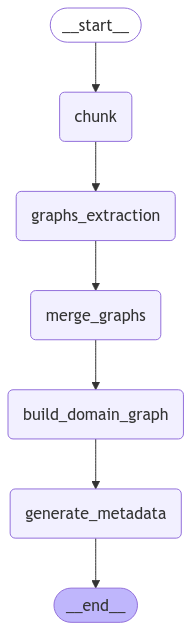

In [18]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

# Local Graph Merge

In [25]:
from typing import Any, Dict, List, Optional
from pydantic import BaseModel, Field

class LocalMetadata(BaseModel):
  section: str = Field(
    ..., description="Section Id associated with the text chunk"
  )
  subsections: List[str] = Field(
    ..., description="Sub Section Id associated with the text chunk"
  )

  class Config:
    populate_by_name = True


class LocalNode(BaseModel):
  id: str = Field(..., description="Unique identifier for the node")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the node"
  )
  type_: str = Field("", alias="type", description="Type of the node, in CamelCase")
  metadata: Dict[str, Any] = Field(
    {}, description="Metadata for the node"
  )

  class Config:
    populate_by_name = True


class LocalEdge(BaseModel):
  from_: str = Field(..., alias="from", description="Origin node ID")
  to: str = Field(..., description="Destination node ID")
  relationship: str = Field(..., description="Name of relationship between the nodes, in SNAKE_CASE")
  properties: Dict[str, Any] = Field(
    {}, description="Additional attributes for the edge"
  )
  metadata: Dict[str, Any] = Field(
    {}, description="Metadata for the node"
  )

  class Config:
    populate_by_name = True


class LocalGraph(BaseModel):
  """Generate a knowledge graph with entities and relationships.
  """

  metadata: LocalMetadata = Field(..., description="Metadata for the knowledge graph")
  nodes: List[LocalNode] = Field(..., description="List of nodes in the knowledge graph")
  edges: List[LocalEdge] = Field(..., description="List of edges in the knowledge graph")

  class Config:
    populate_by_name = True

In [26]:
from typing import List, Tuple
def create_staging_from_extracted_data(extracts: List[Type[BaseModel]]) -> Tuple[List[LocalNode], List[LocalEdge]]:
  staging_nodes = []
  staging_edges = []

  for ext in extracts:
    chunk_str = KnowledgeGraphYAMLExporter().to_yaml(ext)
    chunk = list(yaml.safe_load(chunk_str))

    for section in chunk:
      metadata = section.get('metadata', {})

      # Parse nodes
      for node_data in section.get('nodes', []):
        extracted_id = node_data['id']
        node_type = node_data['type']
        properties = node_data.get('properties', {})

        # Create node using model_validate
        node_obj = LocalNode.model_validate({
          "id": extracted_id,
          "type": node_type,  # Using "type" instead of "type_"
          "properties": properties,
          "metadata": {
            'section': metadata.get('section'),
            'subsections': metadata.get('subsections')
          }
        })

        staging_nodes.append(node_obj)

      # Parse edges
      for edge_data in section.get('edges', []):
        from_id = edge_data['from']
        to_id = edge_data['to']
        relationship = edge_data['relationship']
        properties = edge_data.get('properties', {})

        # Create edge using model_validate
        edge_obj = LocalEdge.model_validate({
          "from": from_id,  # Using "from" instead of "from_"
          "to": to_id,
          "relationship": relationship,
          "properties": properties,
          "metadata": {
            'section': metadata.get('section'),
            'subsections': metadata.get('subsections')
          }
        })

        staging_edges.append(edge_obj)

  return staging_nodes, staging_edges

In [27]:
def create_staging_from_extracted_metadata(ext: KnowledgeGraph) -> Tuple[List[LocalNode], List[LocalEdge]]:
  staging_nodes = []
  staging_edges = []

  metadata_str = KnowledgeGraphYAMLExporter().to_yaml(ext)
  metadata = dict(yaml.safe_load(metadata_str))

  # Parse nodes
  for node_data in metadata.get('nodes', []):
    extracted_id = node_data['id']
    node_type = node_data.get('type', 'Metadata')
    properties = node_data.get('properties', {})

    # Create node using model_validate
    node_obj = LocalNode.model_validate({
      "id": extracted_id,
      "type": node_type,  # Using "type" instead of "type_"
      "properties": properties
    })

    staging_nodes.append(node_obj)

  # Parse edges
  for edge_data in metadata.get('edges', []):
    from_id = edge_data['from']
    to_id = edge_data['to']
    relationship = edge_data['relationship']
    properties = edge_data.get('properties', {})

    # Create edge using model_validate
    edge_obj = LocalEdge.model_validate({
      "from": from_id,  # Using "from" instead of "from_"
      "to": to_id,
      "relationship": relationship,
      "properties": properties
    })

    staging_edges.append(edge_obj)

  return staging_nodes, staging_edges

In [28]:
from typing import Dict, List, Any, Union
import re
from datetime import datetime

class PropertyNormalizer:
    def __init__(self):
        self.unknown_values = {'<UNKNOWN>', 'UNKNOWN', 'N/A', 'None', ''}

    def normalize_property_value(self, value: Any) -> Any:
        if isinstance(value, str):
            # Handle unknown values
            if value.strip() in self.unknown_values:
                return None

            # Try date conversion
            # date_value = self.try_parse_date(value)
            # if date_value:
            #     return date_value

            # Try numeric conversion
            numeric_value = self.try_parse_numeric(value)
            if numeric_value is not None:
                return numeric_value

            # Clean text
            return self.clean_text(value)

        return value

    def try_parse_date(self, value: str) -> Union[datetime, None]:
        date_patterns = [
            r'\d{4}-\d{2}-\d{2}',
            r'\d{2}/\d{2}/\d{4}',
            r'\d{4}'  # Year only
        ]

        for pattern in date_patterns:
          match = re.search(pattern, value)
          if match:
            try:
              date_str = match.group()
              if len(date_str) == 4:  # Year only
                  return datetime.strptime(date_str, '%Y')
              elif '-' in date_str:
                  return datetime.strptime(date_str, '%Y-%m-%d')
              else:
                  return datetime.strptime(date_str, '%m/%d/%Y')
            except ValueError:
              continue
        return None

    def try_parse_numeric(self, value: str) -> Union[float, int, None]:
        # Remove common non-numeric characters
        clean_value = re.sub(r'[,$%]', '', value)

        try:
            if '.' in clean_value:
                return float(clean_value)
            numeric_value = int(clean_value)
            return numeric_value
        except ValueError:
            return None

    def clean_text(self, text: str) -> str:
        # Remove extra whitespace
        text = ' '.join(text.split())
        # Remove special characters but keep basic punctuation
        text = re.sub(r'[^\w\s.,;!?-]', '', text)
        return text.strip()

    def normalize_properties(self, properties: Dict[str, Any]) -> Dict[str, Any]:
        normalized = {}

        for key, value in properties.items():
            # Normalize key names
            clean_key = re.sub(r'([A-Z])', r'_\1', key).lower().strip('_')

            # Normalize values
            normalized_value = self.normalize_property_value(value)

            if normalized_value is not None:
                normalized[clean_key] = normalized_value

        return normalized

def normalize_graph_data(nodes: List[LocalNode], edges: List[LocalEdge]):
    normalizer = PropertyNormalizer()

    # Normalize node properties
    for node in nodes:
        node.properties = normalizer.normalize_properties(node.properties)
        if node.metadata:
            node.metadata = normalizer.normalize_properties(node.metadata)

    # Normalize edge properties
    for edge in edges:
        edge.properties = normalizer.normalize_properties(edge.properties)
        if edge.metadata:
            edge.metadata = normalizer.normalize_properties(edge.metadata)

    return nodes, edges

In [29]:
from transformers import AutoTokenizer, AutoModel
import torch
from typing import List, Dict, Tuple, Set

class BERTResolver:
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2'):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.similarity_threshold = 0.85
        self.type_groups = {}
        self.relationship_groups = {}
        self.id_map = {}  # Global id_map for tracking all node merges

    def get_embeddings(self, text: str) -> torch.Tensor:
        tokens = self.tokenizer(text, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            outputs = self.model(**tokens)
        return outputs.last_hidden_state.mean(dim=1)

    def group_by_type(self, nodes: List[LocalNode]):
        self.type_groups.clear()
        for node in nodes:
            if node.type_ not in self.type_groups:
                self.type_groups[node.type_] = []
            self.type_groups[node.type_].append(node)

    def group_by_relationship(self, edges: List[LocalEdge]):
        self.relationship_groups.clear()
        for edge in edges:
            if edge.relationship not in self.relationship_groups:
                self.relationship_groups[edge.relationship] = []
            self.relationship_groups[edge.relationship].append(edge)

    def compute_node_signature(self, node: LocalNode) -> torch.Tensor:
        text = ' '.join(f"{k}: {v}" for k, v in node.properties.items() if v and k != 'id')
        return self.get_embeddings(text)

    def compute_similarity(self, emb1: torch.Tensor, emb2: torch.Tensor) -> float:
        return torch.cosine_similarity(emb1, emb2, dim=1).item()

    def merge_properties(self, props1: Dict, props2: Dict) -> Dict:
        merged = props1.copy()
        for k, v2 in props2.items():
            if k not in merged or not merged[k]:
                merged[k] = v2
            elif v2 and len(str(v2)) > len(str(merged[k])):
                merged[k] = v2
        return merged

    def update_edge_references(self, edge_id: str, removed_id: str) -> str:
        """Update edge endpoint references based on node merges"""
        return self.id_map.get(edge_id, edge_id)

    def resolve_nodes(self, nodes: List[LocalNode]) -> List[LocalNode]:
        self.group_by_type(nodes)
        resolved_nodes = []
        processed: Set[int] = set()
        self.id_map.clear()  # Reset id_map for new resolution

        for type_, type_nodes in self.type_groups.items():
            embeddings = [(node, self.compute_node_signature(node)) for node in type_nodes]

            for i, (node1, emb1) in enumerate(embeddings):
                if i in processed:
                    continue

                merged_node = node1
                merged_props = node1.properties.copy()
                similar_nodes = []

                # Compare with remaining nodes of same type
                for j, (node2, emb2) in enumerate(embeddings[i+1:], i+1):
                    if j in processed:
                        continue

                    similarity = self.compute_similarity(emb1, emb2)
                    if similarity >= self.similarity_threshold:
                        similar_nodes.append(node2)
                        merged_props = self.merge_properties(merged_props, node2.properties)
                        self.id_map[node2.id] = node1.id  # Map merged node ID to surviving node
                        processed.add(j)

                if similar_nodes:
                    merged_node.properties = merged_props

                if i not in processed:
                    resolved_nodes.append(merged_node)
                    processed.add(i)

        return resolved_nodes

    def resolve_edges(self, edges: List[LocalEdge]) -> List[LocalEdge]:
        self.group_by_relationship(edges)
        resolved_edges = []
        edge_signatures = set()

        for rel_type, rel_edges in self.relationship_groups.items():
            for edge in rel_edges:
                # Update both endpoints using the id_map
                from_id = self.update_edge_references(edge.from_, edge.from_)
                to_id = self.update_edge_references(edge.to, edge.to)

                # Create unique signature for deduplication
                edge_sig = f"{from_id}|{rel_type}|{to_id}"

                if edge_sig not in edge_signatures:
                    new_edge = LocalEdge(
                        from_=from_id,
                        to=to_id,
                        relationship=rel_type,
                        properties=edge.properties.copy(),
                        metadata=edge.metadata.copy()
                    )
                    resolved_edges.append(new_edge)
                    edge_signatures.add(edge_sig)
                else:
                    # If edge exists, merge properties with existing edge
                    existing_edge = next(e for e in resolved_edges
                                      if f"{e.from_}|{e.relationship}|{e.to}" == edge_sig)
                    existing_edge.properties = self.merge_properties(
                        existing_edge.properties,
                        edge.properties
                    )

        return resolved_edges

def resolve_with_bert(nodes: List[LocalNode], edges: List[LocalEdge]) -> Tuple[List[LocalNode], List[LocalEdge]]:
    resolver = BERTResolver()
    resolved_nodes = resolver.resolve_nodes(nodes)
    resolved_edges = resolver.resolve_edges(edges)
    return resolved_nodes, resolved_edges

# Ingestion to Staging DB

In [55]:
import yaml
from typing import Dict, List, Any, Optional
import uuid

class Neo4jStagingManager:
    def __init__(self, staging_label: str = "Staging"):
        self.staging_label = staging_label

    def cleanup_staging(self) -> str:
        return f"MATCH (n:{self.staging_label}) DETACH DELETE n;"

    def get_staging_label(self) -> str:
        return self.staging_label

class Neo4jSchemaGenerator:
    def __init__(self, ontology: Dict[str, Any], staging_manager: Neo4jStagingManager):
        self.ontology = ontology
        self.staging_manager = staging_manager

    def generate_constraints(self, is_staging: bool = True) -> List[str]:
        constraints = []
        staging_label = self.staging_manager.get_staging_label() if is_staging else ""

        for entity_name, entity_def in self.ontology.get('entities', {}).items():
            properties = entity_def.get('properties', {})
            for prop_name, prop_def in properties.items():
                if self._should_create_constraint(prop_name, prop_def):
                    constraints.append(
                        self._create_constraint_stmt(entity_name, prop_name, staging_label)
                    )
        return constraints

    def _should_create_constraint(self, prop_name: str, prop_def: Dict) -> bool:
        if isinstance(prop_def, dict):
            return prop_def.get('unique', False) or prop_def.get('required', False) or prop_name in ['id', 'name']
        return False

    def _create_constraint_stmt(self, entity: str, prop: str, staging_label: str) -> str:
        prefix = f"staging_{entity.lower()}" if staging_label else entity.lower()
        labels = f"{entity}" if not staging_label else f"{entity}:{staging_label}"
        return f"""CREATE CONSTRAINT {prefix}_{prop}
                  IF NOT EXISTS FOR (n:{labels})
                  REQUIRE n.{prop} IS UNIQUE;"""

    def generate_indexes(self, is_staging: bool = True) -> List[str]:
        indexes = []
        staging_label = self.staging_manager.get_staging_label() if is_staging else ""

        for entity_name, entity_def in self.ontology.get('entities', {}).items():
            properties = entity_def.get('properties', {})
            for prop_name, prop_def in properties.items():
                if self._should_create_index(entity_name, prop_name, prop_def):
                    indexes.append(
                        self._create_index_stmt(entity_name, prop_name, staging_label)
                    )
        return indexes

    def _should_create_index(self, entity: str, prop: str, prop_def: Dict) -> bool:
        return prop_def.get('index', False) or (prop in ['type', 'name', 'id'] and not self._has_constraint(entity, prop))

    def _has_constraint(self, entity: str, prop: str) -> bool:
        return any(prop in c for c in self.generate_constraints())

    def _create_index_stmt(self, entity: str, prop: str, staging_label: str) -> str:
        prefix = f"staging_{entity.lower()}" if staging_label else entity.lower()
        labels = f"{entity}" if not staging_label else f"{entity}:{staging_label}"
        return f"""CREATE INDEX {prefix}_{prop}_idx
                  IF NOT EXISTS FOR (n:{labels})
                  ON (n.{prop});"""

class Neo4jIngestionGenerator:
  def __init__(self, ontology: Dict[str, Any], staging_manager: Neo4jStagingManager):
    self.staging_manager = staging_manager
    self.ontology = ontology

  def _get_unique_properties(self, node_type: str) -> List[str]:
    """Get unique properties for a node type from ontology"""
    entity_def = self.ontology.get('entities', {}).get(node_type, {})
    properties = entity_def.get('properties', {})

    unique_props = []
    for prop_name, prop_def in properties.items():
        if isinstance(prop_def, dict) and (
            prop_def.get('unique', False) or
            prop_def.get('required', False)
        ):
            unique_props.append(prop_name)
    return unique_props

  def generate_node_creation(self, nodes: List[LocalNode]) -> List[str]:
    statements = []
    staging_label = f":{self.staging_manager.get_staging_label()}" if self.staging_manager.get_staging_label() else ""

    for node in nodes:
        # Create node with labels
        CREATE_LABEL = 'MERGE'

        # Set properties individually
        set_stmts = []
        for key, value in node.properties.items():
            if value is not None:
                set_stmts.append(f"ON CREATE SET n.{key} = {self._sanitize_value(value)}")
        if len(set_stmts) == 0:
          CREATE_LABEL = 'CREATE'

        create_stmt = f"{CREATE_LABEL} (n:{node.type_}{staging_label})"

        # Combine all statements
        full_stmt = f"{create_stmt}\n" + "\n".join(set_stmts) + f" RETURN '{node.id}: ' + elementId(n);"
        print(full_stmt)
        statements.append(full_stmt)

    return statements

  def generate_relationship_creation(self, nodes: List[LocalNode], edges: List[LocalEdge]) -> List[str]:
    """
    Generate relationship creation statements using property-based node matching

    Args:
        nodes: List of LocalNode objects used for finding matching nodes
        edges: List of LocalEdge objects for relationship creation
    """
    statements = []
    staging_label = f":{self.staging_manager.get_staging_label()}" if self.staging_manager.get_staging_label() else ""

    for edge in edges:
        # Create relationship with type
        create_stmt = f"MERGE (source)-[r:{edge.relationship}]->(target)"

        # Handle relationship properties
        set_stmts = []
        if edge.properties:
            for key, value in edge.properties.items():
                if value is not None:
                    set_stmts.append(f"ON CREATE SET r.{key} = {self._sanitize_value(value)}")

        # Find source node
        source_node = next((n for n in nodes if n.id.lower() == edge.from_.lower()), None)
        target_node = next((n for n in nodes if n.id.lower() == edge.to.lower()), None)

        if not source_node or not target_node:
            raise ValueError(f"Could not find source or target node for edge: {edge}")

        # Build match conditions for source and target nodes
        def build_match_condition(node: LocalNode, alias: str) -> str:
            props = node.properties
            return f"elementId({alias}) = {self._sanitize_value(props['_id'])}"

        source_match = build_match_condition(source_node, 'source')
        target_match = build_match_condition(target_node, 'target')

        # Build MATCH statements
        match_stmt = f"""
        MATCH (source:{source_node.type_}{staging_label})
        WHERE {source_match}
        WITH source
        MATCH (target:{target_node.type_}{staging_label})
        WHERE {target_match}
        WITH source, target
        LIMIT 1"""

        # Combine all statements
        full_stmt = "\n".join([match_stmt, create_stmt] + set_stmts) + ";"
        print(f'\n{full_stmt}')
        statements.append(full_stmt)

    return statements

  def _sanitize_value(self, value: Any) -> str:
    if isinstance(value, str):
        escaped = value.replace('\\', '\\\\').replace("'", "\\'")
        return f"'{escaped}'"
    if isinstance(value, (list, dict)):
        return f"'{str(value)}'"
    return str(value).lower() if isinstance(value, bool) else str(value)

  def create_document_node(self, doc_metadata: LocalNode, nodes: List[LocalNode]) -> List[str]:
    """Creates document node and relationships to section nodes"""
    staging_label = f":{self.staging_manager.get_staging_label()}" if self.staging_manager.get_staging_label() else ""

    # Create document node
    doc_props = " ".join([f"SET d.{k} = {self._sanitize_value(v)}" for k, v in doc_metadata.properties.items()])
    return f"CREATE (d:Document{staging_label}) {doc_props}" + f" RETURN 'doc_id: ' + elementId(d);"

  def create_document_rels(self, doc_id: str, doc_metadata: LocalNode, nodes: List[LocalNode]) -> List[str]:
    """Creates document node and relationships to section nodes"""
    statements = []
    staging_label = f":{self.staging_manager.get_staging_label()}" if self.staging_manager.get_staging_label() else ""
    doc_metadata_props = doc_metadata.properties
    match_props = f"elementId(n) = {self._sanitize_value(doc_metadata_props['_id'])}"
    rel_stmt = f"""
    MATCH (d:Document{staging_label})
    WHERE elementId(d) = '{doc_id}'
    WITH d
    MATCH (n:{doc_metadata.type_}{staging_label})
    WHERE {match_props}
    MERGE (d)-[r:HAS]->(n)
    SET r.section = '{doc_metadata.type_}';
    """
    statements.append(rel_stmt)
    # Create relationships to sections
    section_types = self.ontology.get('sections', {})
    for node in nodes:
        if node.type_ in section_types:
            props = node.properties
            match_props = f"elementId(n) = {self._sanitize_value(props['_id'])}"
            rel_stmt = f"""
            MATCH (d:Document{staging_label})
            WHERE elementId(d) = '{doc_id}'
            WITH d
            MATCH (n:{node.type_}{staging_label})
            WHERE {match_props}
            MERGE (d)-[r:HAS]->(n)
            SET r.section = '{node.type_}';
            """
            statements.append(rel_stmt)

    return statements

class GraphMergeHelper:
    def __init__(self, staging_manager: Neo4jStagingManager):
        self.staging_manager = staging_manager

    def generate_er_queries(self, entity_rules: Dict[str, Dict]) -> List[str]:
        queries = []
        staging_label = self.staging_manager.get_staging_label()
        if staging_label:
            staging_label = f":{staging_label}"
        for entity_type, rules in entity_rules.items():
            match_conditions = ' AND '.join(
                f"s.{prop} = m.{prop}" for prop in rules.get('match_properties', [])
            )

            queries.append(f"""
            MATCH (s:{entity_type}{staging_label})
            MATCH (m:{entity_type}) WHERE NOT m{staging_label} AND {match_conditions}
            RETURN s, m, {rules.get('similarity_threshold', 0.8)} as threshold;
            """)
        return queries

    def generate_merge_queries(self, approved_matches: List[Dict]) -> List[str]:
        queries = []
        staging_label = self.staging_manager.get_staging_label()
        if staging_label:
            staging_label = f":{staging_label}"
        for match in approved_matches:
            # Create temporary relationship for merging
            queries.append(f"""
            MATCH (s{staging_label}) WHERE ID(s) = {match['staging_id']}
            MATCH (m) WHERE ID(m) = {match['main_id']} AND NOT m{staging_label}
            CALL apoc.merge.node(['{match['label']}'], {match['properties']}) YIELD node
            WITH s, m, node
            // Copy relationships from staging node
            CALL apoc.refactor.cloneSubgraph([s], [node]) YIELD input, output, error
            // Remove staging node
            DELETE s;
            """)
        return queries

    def generate_cleanup_query(self) -> str:
        return self.staging_manager.cleanup_staging()

In [31]:
import os
import getpass

NEO4J_HOST=getpass.getpass('URL for Neo4j: ')
NEO4J_USER=getpass.getpass('Username for Neo4j: ')
NEO4J_PASSWORD=getpass.getpass('Password for Neo4j: ')
NEO4J_DB='neo4j'


URL for Neo4j: ··········
Username for Neo4j: ··········
Password for Neo4j: ··········


In [58]:
from neo4j import GraphDatabase

def run_cypher(query: str, **kwargs):
  with GraphDatabase.driver(NEO4J_HOST, auth=(NEO4J_USER, NEO4J_PASSWORD)) as driver:
    driver.verify_connectivity()
    with driver.session(database=NEO4J_DB) as session:
      result = session.run(query, **kwargs).to_df()
      return result


def run_cypher_batch(queries: List[str], **kwargs) -> List[str]:
  results = []
  for query in queries:
    res = run_cypher(query, **kwargs)
    results.append(res)
  return results

In [43]:
def sanitise(nodes: List[LocalNode], edges: List[LocalEdge]) -> Tuple[List[LocalNode], List[LocalEdge]]:
  normalized_nodes, normalized_edges = normalize_graph_data(nodes, edges)
  resolved_nodes, resolved_edges = resolve_with_bert(normalized_nodes, normalized_edges)
  return resolved_nodes, resolved_edges

def ingest(ontology_yaml:str, resolved_nodes: List[LocalNode], resolved_edges: List[LocalEdge]):
  staging = Neo4jStagingManager("")
  ontology = yaml.safe_load(ontology_yaml)
  schema_gen = Neo4jSchemaGenerator(ontology, staging)
  staging_constraints = schema_gen.generate_constraints(is_staging=False)
  staging_indexes = schema_gen.generate_indexes(is_staging=False)

  ingestion_gen = Neo4jIngestionGenerator(ontology, staging)
  merge_helper = GraphMergeHelper(staging)

  node_stmts = ingestion_gen.generate_node_creation(resolved_nodes)
  run_cypher_batch(staging_constraints)
  run_cypher_batch(staging_indexes)
  nodes_with_ids = run_cypher_batch(node_stmts)
  resolved_nodes = set_node_id(nodes_with_ids, resolved_nodes)
  edge_stmts = ingestion_gen.generate_relationship_creation(edges=resolved_edges, nodes=resolved_nodes)
  run_cypher_batch(edge_stmts)

def create_document(ontology_yaml:str, metadata: LocalNode, nodes: List[LocalNode]):
  staging = Neo4jStagingManager("")
  ontology = yaml.safe_load(ontology_yaml)
  ingestion_gen = Neo4jIngestionGenerator(ontology, staging)
  stmt = ingestion_gen.create_document_node(metadata, nodes)
  doc_ids = run_cypher_batch([stmt])
  doc_id = doc_ids[0].iat[0, 0].split(': ')[1]
  stmts = ingestion_gen.create_document_rels(doc_id, metadata, nodes)
  run_cypher_batch(stmts)


def group_data_by_section(data: List[List[Type[BaseModel]]]) -> Dict[str, List[Type[BaseModel]]]:
  grouped_data = {}
  for items in data:
    for item in items:
      section = item.metadata.section
      if section not in grouped_data:
        grouped_data[section] = []
      grouped_data[section].append(item)
  return grouped_data

def set_node_id(nodes_with_ids, resolved_nodes: List[LocalNode]):
  node_map = {}
  for node in nodes_with_ids:
    arr = node.iat[0, 0].split(': ')
    node_map[arr[0]] = arr[1]
  for node in resolved_nodes:
    node.properties['_id'] = node_map[node.id]
  return resolved_nodes

In [57]:
def sanitise_and_ingest(ontology:str, metadata: List[KnowledgeGraph], data: List[List[Type[BaseModel]]]) -> str:
  nodes = List[LocalNode]
  edges = List[LocalEdge]
  nodes, edges = create_staging_from_extracted_metadata(metadata)
  sanitise(nodes, edges)
  ingest(ontology, nodes, edges)
  metadata_node = next((d for d in nodes if d.type_ == 'Metadata'), None)

  grouped_data = group_data_by_section(data)
  section_nodes = []
  for section, section_data in grouped_data.items():
    nodes = List[LocalNode]
    edges = List[LocalEdge]
    nodes, edges = create_staging_from_extracted_data(data)
    sanitise(nodes, edges)
    ingest(ontology, nodes, edges)
    section_nodes.extend(nodes)
  if metadata_node is not None:
    return create_document(ontology, metadata_node, section_nodes)
  return None


# Run pipeline

In [35]:
text_1="""Title: PART I
  Title: ITEM 1. BUSINESS
  Title: Cautionary Statement Regarding Forward-Looking Statements
  Title: The statements in this report include forward-looking statements within the meaning of the Private Securities Litigation Reform Act of 1995. These forward-looking statements are based on current expectations and beliefs and involve numerous risks and uncertainties that could cause actual results to differ materially from expectations. These forward-looking statements speak only as of the date hereof or as of the dates indicated in the statements and should not be relied upon as predictions of future events, as we cannot assure you that the events or circumstances reflected in these statements will be achieved or will occur. You can identify forward-looking statements by the use of forward-looking terminology including “believes,” “expects,” “may,” “will,” “should,” “seeks,” “intends,” “plans,” “pro forma,” “estimates,” “anticipates,” or the negative of these words and phrases, other variations of these words and phrases or comparable terminology. The forward-looking statements relate to, among other things: possible impact of future accounting rules on AMD’s consolidated financial statements; demand for AMD’s products; AMD’s strategy and expected benefits; the growth, change and competitive landscape of the markets in which AMD participates; international sales will continue to be a significant portion of total sales in the foreseeable future; that AMD’s cash, cash equivalents and short-term investment balances together with the availability under that certain revolving credit facility (the Revolving Credit Agreement) made available to AMD and certain of its subsidiaries, our commercial paper program, and our cash flows from operations will be sufficient to fund AMD’s operations including capital expenditures and purchase commitments over the next 12 months and beyond; AMD’s ability to obtain sufficient external financing on favorable terms, or at all; AMD’s expectation that based on management’s current knowledge, the potential liability related to AMD’s current litigation will not have a material adverse effect on its financial position, results of operation or cash flows; anticipated ongoing and increased costs related to enhancing and implementing information security controls; all unbilled accounts receivables are expected to be billed and collected within 12 months; revenue allocated to remaining performance obligations that are unsatisfied which will be recognized in the next 12 months; a small number of customers will continue to account for a substantial part of AMD’s revenue in the future; the expected implications from the development of the legal and regulatory environment relating to emerging technologies such as AI; AMD’s expectation that it will not pay dividends in the near future; AMD’s ability to achieve its corporate responsibility initiatives; expected future AI technology trends and developments. For a discussion of the factors that could cause actual results to differ materially from the forward-looking statements, see “Part I, Item 1A-Risk Factors” and the “Financial Condition” section set forth in “Part II, Item 7-Management’s Discussion and Analysis of Financial Condition and Results of Operations,” or MD&A, and such other risks and uncertainties as set forth below in this report or detailed in our other Securities and Exchange Commission (SEC) reports and filings. We assume no obligation to update forward-looking statements.
  Title: Additionally, we make certain voluntary disclosures in this report and on our website, which are informed by various standards and frameworks (including standards for the measurement of underlying data), and the interests of various stakeholders. As such, these voluntary disclosures may not necessarily be “material” under the federal securities laws for SEC reporting purposes. Furthermore, much of this information is subject to methodological considerations or information, including from third-parties, that is still evolving and subject to change, and which AMD does not independently verify. For example, our disclosures based on any standards may change due to revisions in framework requirements, availability of information, changes in our business or applicable government policies, or other factors, some of which may be beyond our control.
  References in this Annual Report on Form 10-K to “AMD,” “we,” “us,” “management,” “our” or the “Company” mean Advanced Micro Devices, Inc. and our consolidated subsidiaries.

Title: Overview
  We are a global semiconductor company primarily offering:
• server microprocessors (CPUs), graphics processing units (GPUs), accelerated processing units (APUs), data processing units (DPUs), Field Programmable Gate Arrays (FPGAs), Smart Network Interface Cards (SmartNICs), Artificial Intelligence (AI) accelerators and Adaptive System-on-Chip (SoC) products for data centers; 1
• CPUs, APUs and chipsets for desktop, notebook, and handheld personal computers;
• discrete GPUs, and semi-custom SoC products and development services; and
• embedded CPUs, GPUs, APUs, FPGAs, System on Modules (SOMs), and Adaptive SoC products.
From time to time, we may also sell or license portions of our intellectual property (IP) portfolio.

Title: Additional Information
  AMD was incorporated under the laws of Delaware on May 1, 1969 and became a publicly held company in 1972. Our common stock is currently listed on The NASDAQ Global Select Market (NASDAQ) under the symbol “AMD”. Our mailing address and executive offices are located at 2485 Augustine Drive, Santa Clara, California 95054, and our telephone number is (408) 749-4000. For financial information about geographic areas and for segment information with respect to revenues and operating results, refer to the information set forth in Note 4 of our consolidated financial statements. We use a 52- or 53-week fiscal year ending on the last Saturday in December. References in this report to 2023, 2022 and 2021 refer to the fiscal year unless explicitly stated otherwise.
AMD, the AMD Arrow logo, AMD CDNA, AMD Instinct, RDNA, Alveo, Artix, Athlon, CoolRunner, EPYC, FidelityFX, FirePro, FreeSync, Geode, Infinity Fabric, Kinex, Kria, Pensando, Radeon, ROCm, Ryzen, Spartan, Threadripper, UltraScale, UltraScale+, V-Cache, Versal, Virtex, Vitis, Vivado, Xilinx, XDNA, Zynq and combinations thereof are trademarks of Advanced Micro Devices, Inc.
Microsoft, Windows, DirectX and Xbox One are either registered trademarks or trademarks of Microsoft Corporation in the United States and/or other countries. PCIe is a registered trademark of PCI-SIG Corporation. Linux is the registered trademark of Linus Torvalds in the United States and/or other countries. PlayStation is a registered trademark or trademark of Sony Interactive Entertainment, Inc. Arm is a registered trademark of ARM Limited (or its subsidiaries) in the United States and/or other countries. Vulkan and the Vulkan logo are registered trademarks of Khronos Group Inc. Steam Deck and the Steam Deck logo are trademarks and/or registered trademarks of Valve Corporation in the United States and/or other countries.
Other names are for informational purposes only and are used to identify companies and products and may be trademarks of their respective owners.

Title: Website Access to Our SEC Filings and Corporate Governance Documents
  On the Investor Relations pages of our website, http://ir.amd.com, we post links to our filings with the SEC, our Principles of Corporate Governance, our Code of Ethics for our executive officers, all other senior finance executives and certain representatives from legal and internal audit, our Worldwide Standards of Business Conduct, which applies to our Board of Directors and all of our employees, and the charters of the committees of our Board of Directors. Our filings with the SEC are posted as soon as reasonably practical after they are electronically filed with, or furnished to, the SEC. The SEC website, www.sec.gov, contains reports, proxy and information statements, and other information regarding issuers that file electronically with the SEC. You can also obtain copies of these documents by writing to us at: Corporate Secretary, AMD, 2485 Augustine Drive, Santa Clara, California 95054, or emailing us at: Corporate.Secretary@amd.com. All of these documents and filings are available free of charge.
If we make substantive amendments to our Code of Ethics or grant any waiver, including any implicit waiver, to our principal executive officer, principal financial officer, principal accounting officer, controller or persons performing similar functions, we intend to disclose the nature of such amendment or waiver on our website.
The information contained on our website is not incorporated by reference in, or considered to be a part of, this report.

Title: Our Industry
  We are a global semiconductor company. Semiconductors are components used in a variety of electronic products and systems. An integrated circuit (IC) is a semiconductor device that consists of many interconnected transistors on a single chip. Since the invention of the transistor in 1948, improvements in IC process and design technologies have led to the development of smaller, more complex and more reliable ICs at a lower cost-per-function. 2

Title: Our Strategy
  AMD drives innovation through high-performance and adaptive computing technology, software and product leadership. Our strategy is to create and deliver the world’s leading high-performance and adaptive computing products across a diverse set of customer markets including data center, client, gaming and embedded. Our strategy is focused on five strategic pillars: extend leadership in foundational technology and IP, provide competitive software, tools and open-source enablement, re-use core technology across platforms to achieve economies of scale, build effective ecosystems with disciplined partnerships, and drive customer-centric go-to-market that leverages all of AMD’s capabilities.
With our high-performance product portfolios, we deliver solutions that are differentiated at the chip level, such as our semi-custom SoCs, Adaptive SoCs, and APUs, and at the platform level, such as in our customers’ client computing devices, embedded platforms and servers. We offer a deep portfolio of data center computing solutions including CPUs, GPUs, DPUs, SmartNICs, FPGAs, AI accelerators and Adaptive SoCs to meet the vast computing performance requirements of today’s data centers, supercomputers, AI and Machine Learning (ML) data center environments and cloud environments. AMD is a leader in adaptive and embedded computing, CPUs, APUs, FPGAs, SOMs and Adaptive SoCs for a variety of markets, including health care, automotive, industrial, storage and networking. We drive innovation with our line-up of CPUs, APUs and chipsets for desktop, notebook, commercial and handheld PCs to bring performance, efficiency and modern security features to gamers, creators, consumers and enterprises. Our GPUs, including discrete GPUs, semi-custom SoC products and development services, work together with software to power immersive gaming experiences for personal PCs, handheld PCs, the latest game consoles and cloud gaming services.
We believe that AI capabilities are central to products and solutions across our markets and we have a broad technology roadmap and products targeting AI training and inference spanning cloud, edge and intelligent endpoints. We offer products that include capabilities to support AI deployment and we expect this part of our business to grow. Our AI product portfolio caters to customers across strategic markets, from data center to enterprise to client. We achieve this through our family of CPUs, GPUs, FPGAs, and Adaptive SoCs. With the acquisitions of Mipsology SAS and Nod, Inc. in 2023, we expanded our AI software capabilities to accelerate our AI growth strategy centered on an open software ecosystem to help lower the barriers of entry for customers through developer tools, libraries and models.
We develop world-class software platforms that are used to enable our high-performance products. Our software platforms include development tools, compilers, and drivers for our CPUs, APUs, GPUs and FPGAs. We work closely with our customers to define and develop customized solutions to precisely match their requirements. We enable this by combining our broad portfolio of high-performance IP with our leadership design and packaging to deliver world-class customized solutions to our customers. We invest in innovative technology and solutions such as our custom-ready chiplet platform and AMD Infinity Architecture to maintain our leadership position as a custom-design silicon provider of choice.
Our four reportable segments are:
• the Data Center segment, which primarily includes server CPUs, GPUs, APUs, DPUs, FPGAs, SmartNICs, AI accelerators and Adaptive SoC products for data centers;
• the Client segment, which primarily includes CPUs, APUs, and chipsets for desktop, notebook and handheld personal computers;
• the Gaming segment, which primarily includes discrete GPUs, semi-custom SoC products and development services; and
• the Embedded segment, which primarily includes embedded CPUs, GPUs, APUs, FPGAs, SOMs, and Adaptive SoC products.
In addition to these reportable segments, we have an All Other category, which is not a reportable segment. 3

Title: Data Center Segment
  Title: Data Center Market
  The Data Center segment primarily includes server-class CPUs, GPUs, AI accelerators, DPUs, FPGAs, SmartNICs, and Adaptive SoC products. We leverage our technology to address the computational, visual data processing and AI workload acceleration needs in the data center market. Modern data centers require high performance, energy efficient, scalable and adaptable compute engines to meet the demand driven by the growing amount of data that needs to be stored, accessed, analyzed and managed. Different combinations of CPUs, GPUs, DPUs, FPGAs, SmartNICs, and Adaptive SoCs enable the optimization of performance and power for a diverse set of workloads.

Title: Data Center Products
  Title: Server CPUs.
  Our CPUs for server platforms currently include the AMD EPYC™ Series processors – AMD EPYC 9004 Series, AMD EPYC 8004 Series, AMD EPYC 7003 Series and AMD EPYC 7002 Series. Our 4 th Gen AMD EPYC 9004 Series processors are built on the “Zen 4” 5 nanometer (nm) process node and re designed to deliver leadership performance and energy efficiency across a range of market segments and workloads. The AMD EPYC 97x4, cloud native-optimized data center CPUs, formerly codenamed “Bergamo,” are built with our “Zen 4c” architecture core and further extend the EPYC 9004 Series of processors to deliver the thread density and scale needed for cloud native computing. Our AMD EPYC 8004 Series processors, formerly codenamed “Siena”, are also built on the “Zen 4c” core into a workload-optimized CPU. Our 3 rd Gen AMD EPYC and 4th Gen AMD EPYC portfolios both include processors that feature AMD 3D V-Cache™ technology for leadership performance in technical computing workloads.

Title: Data Center GPUs.
  Our AMD Instinct™ family of GPU accelerator products, including AMD Instinct MI200 and MI300 Series which are based on AMD CDNA architecture. AMD Instinct accelerators are designed to address the growing demand for compute-accelerated data center workloads, including AI training and inferencing, and a range of supercomputing applications where the compute capabilities of GPUs can provide additional performance. Combined with our AMD ROCm™ open software platform, our customers can deliver differentiated accelerated platforms to address the next-generation of computing challenges while minimizing power and space needs in the data center. Our visual cloud GPU offerings include products in the Radeon™ PRO V families. Our visual cloud data center GPUs include a range of solutions tailored towards workloads requiring remote visualization, such as Desktop-as-a-Service, Workstation-as-a-Service and Cloud Gaming.

Title: FPGAs and Adaptive SoCs.
  We offer a wide range of FPGAs, Adaptive SoCs and acceleration cards for the data center. Devices include the Virtex™ and Kintex™ FPGA products, as well as Zynq™, Zynq MPSoC, and Versal™ Adaptive SoC products. Our Alveo™ accelerator cards provide a platform for accelerating workloads including AI processing in the data center, at the edge or the cloud. Our AMD Alveo MA35D media accelerator is designed to deliver high channel density, power efficiency and ultra-low-latency performance. To make it accessible for developers, Alveo is available on most major OEM server platforms, as well as a growing presence across all major cloud providers who provide FPGA-as-a-Service (FaaS).

Title: DPUs.
  Our P4 programmable AMD Pensando DPUs are designed to help offload data center infrastructure services from the host CPU, and coupled with our comprehensive networking software stack, AMD DPUs help enable cloud and enterprise customers to optimize performance for network, storage, and security services at cloud scale. Designed for minimal latency, jitter and power impact, our DPUs can help large Infrastructure as a Service (IaaS) cloud providers improve workload performance for hosted virtualized and bare-metal offerings. 4

Title: Client Segment
  Title: Client Market
  Our CPUs are incorporated into computing platforms, which are a collection of technologies that are designed to work together to provide a more complete computing solution. We believe that integrated, balanced computing platforms consisting of CPUs, chipsets, GPUs (either as discrete GPUs or integrated into an APU or SoC) and AI accelerators that work together at the system level bring end users improved system stability, increased performance and enhanced power efficiency. In addition, we believe customers also benefit from an all-AMD platform (consisting of an APU or CPU, a discrete GPU, a chipset and AMD software), as we are able to optimize interoperability, provide our customers a single point of contact for the key platform components and enable them to bring the platforms to market quickly in a variety of PC form factors. We currently base our CPUs, APUs and chipsets on the x86 instruction set architecture and the AMD Infinity Fabric™, which connects an on-chip memory controller and input/output (I/O) channels directly to our compute engines and domain specific accelerators.

Title: Client Products
  Title: Desktop CPUs.
  Our CPUs and APUs for desktop platforms currently include the AMD Ryzen™ and AMD Athlon™ series processors. Our Ryzen 7000 Series desktop processors are based on “Zen 4” architecture and deliver leadership performance for gamers and content creators. Our AMD Ryzen 5000 Series desktop processor family powered by our “Zen 3” core architecture has up to 16 cores and provides price-performance for all levels of customers. For gaming enthusiasts, both the Ryzen 7000 Series and 5000 Series feature models with the AMD 3D V-Cache technology designed to improve gaming performance. AMD has returned to the high end desktop (HEDT) segment with Ryzen Threadripper™ 7000 Series processors featuring up to 64 cores.

Title: Notebook CPUs.
  Our mobile APUs, including AMD Ryzen and AMD Athlon mobile processors for the commercial and consumer markets, combine both high levels of performance and efficiency for notebook PCs. Our AMD Ryzen 7045 Series processors are designed to deliver high performance gaming solutions. Our AMD Ryzen 7040 Series processors for mobile applications have up to 8 “Zen 4” architecture cores, are built on 4 nm process technology, and feature AMD RDNA 3 graphics. Our Ryzen 7040 Series mobile processors also feature dedicated AI hardware in an x86 processor, with our XDNA architecture. Built on advanced 6 nm technology, our AMD Ryzen and Athlon 7020 C-Series processors have up to four cores and eight threads built on “Zen 2” architecture and AMD RDNA 2 integrated graphics to deliver fast and responsive performance for modern productivity, video conferencing, learning apps and streaming applications. We also offer AMD Ryzen 6000 Series mobile processors, built on “Zen 3+” architecture and AMD Ryzen 5000 Series mobile processors, which are powered by both our “Zen 2” and “Zen 3” core architectures, which are designed for mainstream solutions in both consumer and commercial markets. Our AMD Ryzen Z1 Series processors bring high-performance to handheld Windows-based PC gaming platforms. These processors feature “Zen 4” processor technology combined with RDNA 3 graphics to deliver fast PC gaming, incredible battery life, and immersive experiences in handheld systems.

Title: Commercial CPUs.
  We offer enterprise-class desktop and mobile PC solutions sold as AMD PRO Mobile and AMD PRO desktop processors with Radeon™ graphics for the commercial market. AMD Ryzen PRO, AMD Threadripper PRO and AMD Athlon PRO processors solutions are designed to provide enterprise customers with the performance, security capabilities and business features such as enhanced security and manageability, platform longevity and extended image stability. Our AMD Ryzen Threadripper PRO 7000 WX-Series processors with “Zen 4” core architecture and 5000 WX-Series processors with “Zen 3” core architecture provide full-spectrum performance across multiple workstation workloads due to the performance and efficiency of the Zen CPU core with core count scaling up to 96 cores in the 7000 WX-Series. Our Ryzen PRO 7040 Series Mobile processors are built on “Zen 4” architecture, AMD RDNA 3 integrated graphics, AMD PRO technologies and Ryzen AI, on select models. Our AMD Ryzen Threadripper PRO 7000 WX-Series processors are built on 5 nm “Zen 4” architecture.

Title: Chipsets.
  We offer a full suite of chipset products to support our AMD Ryzen and Threadripper platforms, including chipsets for the AM5 socket like the X670 chipsets which support PCIe ® 5.0 (fifth generation Peripheral Component Interconnect Express motherboard interface) designed for enthusiast desktop platforms. In the AM5 platform we also offer B650 chipsets to enable a broader range of solutions in the market. In the AM4 ecosystem for 5000-series processors and prior, we offer the X570, B550 and A520 chipsets. In addition, we continue to offer the B450 chipsets that are combined with AMD Ryzen processors for the AM4 desktop platform for the performance and affordable mainstream platforms segments. In HEDT and Workstation segments, we offer the WRX90 and TRX50 chipsets to support 7000-series Threadripper and Threadripper PRO platforms, as well as the WRX80 chipsets to support the 5000-series Threadripper PRO platforms. 5

Title: Gaming Segment
  Title: Gaming Market
  Graphics processing is a fundamental component across many of our products and can be found in APU, GPU, SoC or a combination of a discrete GPU with another product working in tandem. Our customers generally use our graphics solutions to enable or increase the speed of rendering images, to help improve image resolution and color definition and/or to process AI/ML based workloads. We develop our graphics products for use in various computing devices and entertainment platforms, including desktop PCs, notebook PCs, handheld PCs, All-in-Ones (AIOs), professional workstations, and the data center. With each of our graphics products, we have available drivers and supporting software packages that enable the effective use of these products under a variety of operating systems and applications. We have developed AMD RDNA™ 3, a high performing and power efficient graphics architecture, featuring a chiplet design, AI accelerators and the Radiance Display™ Engine. This generation continues to support advanced graphics features introduced with RDNA 2, such as ray tracing, AMD Infinity Cache™ and variable rate shading. The Sony PlayStation ® 5 and Microsoft ® Xbox Series S™ and X™ game consoles also feature our RDNA graphics architecture. Our APUs deliver visual processing functionality for value and mainstream PCs by integrating a CPU and a GPU on a single chip, while discrete GPUs (which are also known as dGPUs) offer high-performance graphics processing across all platforms. We leverage our core IP, including our graphics and processing technologies to develop semi-custom solutions. Here, semiconductor suppliers work alongside system designers and manufacturers to enhance the performance and overall user experience for semi-custom customers. We have used this collaborative co-development approach with many of today’s leading game console and handheld PC gaming manufacturers and can also address customer needs in many other markets. We leverage our existing IP to create a variety of products tailored to a specific customer’s needs, including complex fully-customized SoCs to more modest adaptations and integrations of existing CPU, APU or GPU products.

Title: Gaming Products
  Title: Semi-Custom Products.
  Our semi-custom products are tailored, high-performance, customer-specific solutions based on our CPU, GPU and multi-media technologies. We work closely with our customers to define solutions to precisely match the requirements of the device or application. We developed the semi-custom SoC products that power both the Sony PlayStation 5 as well as the Microsoft Xbox Series S and X game consoles. We partnered with Valve to create a semi-custom APU optimized for handheld gaming to power the Steam Deck™.

Title: Discrete Desktop and Notebook GPUs .
  Our AMD Radeon series discrete GPU processors for desktop and notebook PCs support current generation application program interfaces (APIs) like DirectX® 12 Ultimate and Vulkan ® , support high-refresh rate displays using AMD FreeSync™, AMD FreeSync Premium, and AMD FreeSync Premium Pro technologies, and are designed to support VR in PC platforms. Our AMD Radeon Software offers performance enhancing tools and enables new features and customization capabilities to customers and end-users. In addition, we also offer tools for game developers such as our AMD FidelityFX™ open-source image quality software toolkit that helps deliver improved visual quality with minimal performance overhead. FidelityFX Super Resolution (FSR) uses upscaling technologies to help boost frame rates in games. Our FSR 2.0 technology uses temporal data and optimized anti-aliasing to boost frame rates in supported games while delivering similar or better image quality than native resolution without the requirement of dedicated machine learning hardware. Our FSR 3.0 technology combines the upscaling features of prior versions while introducing our AMD Fluid Motion Frames Technology which generates interpolated frames between native frames to increase the frame rate of games for a smoother gaming experience. Varying versions of FSR are supported in over 250 games and multiple products including Radeon GPUs, Ryzen APUs, and many of our Semi-custom solutions. Being an open-source technology FSR works across competing hardware solutions as well.
Our AMD Radeon RX 7000 series are built on the high-performance, energy-efficient AMD RDNA3 architecture which provides up to 96 compute units, second generation high-bandwidth, low-latency AMD Infinity Cache technology as well as dedicated AI and ray tracing hardware. The AMD RDNA 3 architecture provides process optimizations plus firmware and software enhancements and supports AI-accelerated video encoding and hardware-accelerated AV1 encoding. It uses high-speed GDDR6 video RAM (VRAM) and targets discrete desktop GPUs with up to 24GB of VRAM, notebook GPUs with up to 16GB of VRAM. We continue to offer AMD Radeon RX 6000 series discrete graphics, based on our RDNA2 architecture, for high-performance gaming desktops and notebooks. Our AMD Advantage Design™ Framework is a collaboration with our global PC partners, delivering high-performance gaming notebooks by combining our AMD Radeon RX series mobile graphics, AMD Software: Adrenalin Edition, AMD Ryzen series mobile processors and utilizing AMD smart technologies to provide best-in-class gaming experiences. 6

Title: Professional GPUs.
  Our AMD Radeon W7000 PRO family of professional graphics products are based on the AMD RDNA3 architecture and are designed for integration in mobile and desktop workstations. AMD Radeon PRO graphics cards are designed to optimize design workloads across demanding use cases such as 3D rendering, design and manufacturing for CAD, and media and entertainment for broadcast and animation pipelines on high resolution displays. Our AMD Radeon PRO W7000 series supports workstation GPUs with up to 48GB of VRAM and features the AMD Radiance Display Engine™ featuring DisplayPort™ 2.1 that delivers very high resolution and refresh rates, image fidelity and color accuracy. We continue to offer our AMD Radeon PRO W6000 series workstation graphics products based on our AMD RDNA 2 architecture for high-performance workstations.

Title: Embedded Segment
  Title: The Embedded Market
  The Embedded segment primarily includes embedded CPUs, GPUs, APUs, FPGAs, and Adaptive SoC products. Embedded products address computing needs in automotive, industrial, test, measurement, emulation, medical, broadcast, professional audio visual (ProAV), aerospace, defense, communications, networking, security, and storage markets as well as thin clients, which are computers that serve as an access device on a network. Typically, our embedded products are used in applications that require varying levels of performance, where key features may include relatively low power, small form factors, and 24x7 operations. High-performance graphics are important in some embedded systems. Support for Linux ® , Windows ® and other operating systems as well as for increasingly sophisticated applications are also critical for some customers. Other requirements may include meeting rigid specifications for industrial temperatures, shock, vibration and reliability. The embedded market has moved from developing proprietary, custom designs to leveraging industry-standard instruction set architectures and processors as a way to help reduce costs and speed time to market.

Title: Embedded Products
  Title: Embedded CPUs, APUs and GPUs .
  Our products for embedded platforms include AMD EPYC Embedded CPUs, AMD Ryzen Embedded V-Series APUs and CPUs, AMD Ryzen Embedded R-Series APUs and CPUs, AMD Ryzen Embedded 5000 Series processors and AMD Ryzen Embedded 7000 Series processors . Our embedded processors and GPUs are designed to support high performance and bandwidth network connectivity and security, high-performance storage requirements for enterprise and cloud infrastructure, 3D graphics performance and 4K multimedia requirements of automotive infotainment systems. Our AMD Ryzen Embedded 5000 Series processors use “Zen 3” x86 CPU core architecture and are designed for enterprise reliability to support the consistent uptime requirements needed by security and networking customers. Our AMD Ryzen Embedded 7000 Series processor family combines “Zen 4” architecture and integrated Radeon RDNA 2 graphics for a wide range of embedded applications, including industrial automation, machine vision, robotics and edge servers.

Title: FPGAs and Adaptive SoCs.
  Our FPGA products are hardware-customizable devices that can be tailored to meet the specific needs of each customer, enabling them to differentiate their products and accelerate time-to-market. Our FPGA families include UltraScale+™ (based on 16 nm technology), UltraScale™ (20 nm), 7 Series (28 nm) and older series. Adaptive SoC products include the Zynq SoC and UltraScale+ Multi-Processing System on a Chip (MPSoCs) which combine FPGA technology with a heterogeneous processing system, as well as the industry’s first RFSoC architecture with integrated radio frequency (RF) data converters. The Versal portfolio is composed of software-programmable Adaptive SoCs, with a heterogeneous compute platform that combines Scalar Engines, Adaptable Engines, and Intelligent Engines to achieve dramatic performance improvements over today's fastest FPGA and accelerate applications in a wide variety of markets, including data center, wired network, 5G wireless infrastructure, automotive, industrial, scientific, medical, aerospace and defense.

Title: Development Boards, Kits and Configuration Products.
  We offer development kits for all our FPGA and Adaptive SoC products that include hardware, development tools, IP and reference designs that are designed to streamline and accelerate the development of domain-specific and market-specific applications. Our AMD Kria™ K24 SOM provides high determinism and low latency for powering electric drives and motor controllers used in compute-intensive digital signal processing (DSP) applications at the edge. Coupled with our KD240 Drives Starter Kit, an out-of-the-box-ready motor control-based development platform, the products offer a seamless path to production deployment with the K24 SOM. 7

Title: Legacy Product Families.
  Prior generation high-end Virtex FPGA families include Virtex-6, Virtex-5, Virtex-4, Virtex-II Pro, Virtex-II and the original Virtex family. Prior generation low end Spartan™ FPGA families include Spartan-6, Spartan-3, the Spartan-3E and Spartan-3A, Spartan-IIE, Spartan-II, Spartan XL and the original Spartan family. Complex Programmable Logic Devices (CPLDs) operate on the lowest end of the programmable logic density spectrum. CPLDs are single-chip, nonvolatile solutions characterized by instant-on and universal interconnect. Prior generations of CPLDs include the CoolRunner™ and XC9500 product families.

Title: Design Platforms and Services
  Title: Adaptable Platforms.
  We offer two types of platforms that support our customers' designs and reduce their development efforts: FPGAs and Adaptive SoCs. All devices feature adaptable hardware that enables our customers to implement customized, domain-specific architectures. With both hardware-accelerated performance and flexibility beyond what CPUs, GPUs, application-specific standard parts (ASSPs), and application-specific integrated circuits (ASICs) can offer, customers can introduce new innovations to the market quickly. FPGAs feature reconfigurable hardware as well as integrated memory, digital signal processing, analog mixed signal, high-speed serial transceivers, and networking cores coupled with advanced software for a broad range of applications in all of our end markets. Our Adaptive SoCs feature a heterogeneous processing subsystem with integrated programmable hardware fabric targeting embedded systems needing real-time control, analytics, sensor fusion, and adaptable hardware for differentiation and acceleration. Our Zynq UltraScale+ RFSoCs feature integrated high-performance RF data converters targeting wireless, radar, and cable access applications. Enabled by both hardware and software design tools and an extensive operating system, middleware, software stack, and IP ecosystem, SoC platforms target software developers as well as traditional hardware designers. Versal is the most recent addition to the silicon portfolio. Versal combines Scalar Processing Engines, Adaptable Hardware Engines, and Intelligent Engines with leading-edge memory and interfacing technologies to deliver powerful heterogeneous acceleration for any application. This product family is ideally suited to accelerate a broad set of applications in the emerging era of big data and AI. Versal hardware and software can be programmed and optimized by software developers, data scientists, and hardware developers alike, enabled by a host of tools, software, libraries, IP, middleware, and frameworks that enable industry-standard design flows.

Title: Software Development Platform.
  To accommodate hardware and software designers, as well as software developers and AI scientists, we provide design tools and software stacks tailored to each user profile. Our Vivado™ ML Edition provides hardware design teams with the tools and methodology needed to program FPGAs and Adaptive SoCs. Our Vitis™ unified software platform enables the development and deployment of embedded software and accelerated applications, on our FPGAs and Adaptive SoCs. Our Vitis AI unified software platform enables the development and deployment of AI software on our FPGAs and Adaptive SoCs.

Title: Sales and Marketing
  We sell our products through our direct sales force and through independent distributors and sales representatives in both domestic and international markets. Our sales arrangements generally operate on the basis of product forecasts provided by the particular customer, but do not typically include any commitment or requirement for minimum product purchases. We primarily use product quotes, purchase orders, sales order acknowledgments and contractual agreements as evidence of our sales arrangements. Our agreements typically contain standard terms and conditions covering matters such as payment terms, warranties and indemnities for issues specific to our products.
We generally warrant that our products sold to our customers will conform to our approved specifications and be free from defects in material and workmanship under normal use and conditions for one year. We offer up to three-year limited warranties for certain product types, and sometimes provide other warranty periods based on negotiated terms with certain customers.
We market and sell our latest products under the AMD trademark. Our client processors include: AMD Ryzen, AMD Ryzen PRO, AMD Ryzen Threadripper, AMD Ryzen Threadripper PRO, AMD Athlon, AMD Athlon PRO, and AMD PRO A-Series. These products service desktop and notebook personal computers.
Our product brand for the consumer graphics market is AMD Radeon graphics, and AMD Embedded Radeon graphics is our product brand for the embedded graphics market.
Our product brand for professional graphics products is AMD Radeon PRO graphics. 8
Our product brands for data center graphics are Radeon PRO V-series, and AMD Instinct accelerators for servers. We also market and sell our chipsets under AMD trademarks.
Our product brand for server microprocessors is AMD EPYC processors.
We also sell low-power versions of our AMD Athlon, as well as AMD Geode™, AMD Ryzen, AMD EPYC, AMD R-Series and G-Series processors as embedded processor solutions.
Our FPGA product brands are Virtex-6, Virtex-7, Virtex UltraScale+, Kintex-7, Kintex UltraScale, Kintex UltraScale+, Artix-7, Artix UltraScale+, Spartan-6 and Spartan-7.
Our product brands for Adaptive SoCs are Zynq-7000, Zynq UltraScale+ MPSoC, Zynq UltraScale+ RFSoCs, Versal HBM, Versal Premium, Versal Prime, Versal AI Core, Versal AI Edge, Vitis and Vivado.
Our product brand for System-on-Module (SOM) is Kria.
Our compute and network acceleration board products are sold under the Alveo and Pensando brands.
We market our products through direct marketing and co-marketing programs. In addition, we have cooperative advertising and marketing programs with customers and third parties, including market development programs, pursuant to which we may provide product information, training, marketing materials and funds. Under our co-marketing development programs, eligible customers can use market development funds as reimbursement for advertisements and marketing programs related to our products and third-party systems integrating our products, subject to meeting defined criteria.

Title: Customers
  Our Data Center Segment customers consist primarily of hyperscale data centers, original equipment manufacturers (OEMs), original design manufacturers (ODMs), system integrators and independent distributors in both domestic and international markets. ODMs provide design and/or manufacturing services to branded and unbranded private label resellers, OEMs and system builders.
Customers of our Client Segment products consist primarily of PC OEMs, a network of independent distributors and, for chipset products, ODMs that manufacture motherboards. Our Gaming Segment customers include PC OEMs and independent distributors as well as add-in-board manufacturers (AIBs), independent game console and portable gaming devices manufacturers and contract manufacturers for AMD branded graphics cards.
Our Embedded Segment products are sold to customers in a very wide range of markets such as Aerospace and Defense, Test and Measurement, Industrial, Automotive, Consumers, Broadcast, Communication Infrastructure and Data Center. For these products we either sell directly to our customers or through a network of distributors and OEM partners. We are also developing a network of Value Added Resellers (VARs) and Integrated Solution Vendors (ISVs) for our Alveo products.
We work closely with our customers to define product features, performance and timing of new products so that the products we are developing meet our customers’ needs. We also employ application engineers to assist our customers in designing, testing and qualifying system designs that incorporate our products. We believe that our commitment to customer service and design support improves our customers’ time-to-market and fosters relationships that encourage customers to use the next generation of our products.
We also work with our customers to create differentiated products that leverage our CPU, GPU, DPU and APU technology. Certain customers pay us non-recurring engineering fees for design and development services and a purchase price for the resulting products.
One customer accounted for 18 % of our consolidated net revenue for the year ended December 30, 2023. Sales to this customer consisted of sales of products from our Gaming segment. A loss of this customer would have a material adverse effect on our business. 9

Title: Original Equipment Manufacturers
  We focus on three types of OEM partners: multi-nationals, selected regional accounts and selected global and local system integrators, who target commercial and consumer end customers of all sizes. Large multi-nationals and regional accounts are the core of our OEM partners’ business; however, we are increasingly focused on the VAR channel which resells OEM systems to the mid-market and the small and medium business (SMB) segments. Additionally, we have increased our focus on global system integrators, which resell OEM systems, coupled with their software and services solutions into Enterprise, high performance computing (HPC) and Cloud Service Provider customers. Our OEM customers include numerous foreign and domestic manufacturers of servers and workstations, desktops, notebooks, PC motherboards and game consoles.

Title: Hyperscale Data Centers
  Large multi-national public cloud service providers and hyperscale private data centers directly and indirectly purchase a substantial portion of our data center-focused products, including server CPUs, GPU accelerators, DPUs, FPGAs and Adaptive SOCs. These products are incorporated into servers and other data center appliances sold by OEMs to the hyperscale customers or into custom servers or hardware designed by or for these customers and manufactured by ODMs or contract manufacturers. Hyperscale data centers use these products to operate web-based applications or to support public cloud computing and storage service offerings, including but not limited to AI workloads such as generative AI models.

Title: Third-Party Distributors
  Our authorized channel distributors resell to sub-distributors and OEMs, ODMs, and other customers. Typically, distributors handle a wide variety of products, and may include products from other manufacturers that compete with our products. Distributors typically maintain an inventory of our products. In most instances, our agreements with distributors protect their inventory of our products against price reductions and provide certain return rights with respect to any product that we have removed from our price book or otherwise subject to discontinuation. In addition, some agreements with our distributors may contain standard stock rotation provisions permitting limited product returns.

Title: Add-in-Board (AIB) Manufacturers and System Integrators
  We offer component-level graphics and chipset products to AIB manufacturers who in turn build and sell board-level products using our technology to system integrators (SIs), retail buyers and sub distributors. Our agreements with AIBs protect their inventory of our products against price reductions. We also sell directly to our SI customers. SIs typically sell from positions of regional or product-based strength in the market. They usually operate on short design cycles and can respond quickly with new technologies. SIs often use discrete graphics solutions as a means to differentiate their products and add value to their customers.

Title: Competition
  The markets in which our products are sold are highly competitive and delivering the latest and best products to market on a timely basis is critical to achieving revenue growth. We believe that the main factors that determine our product competitiveness are total cost of ownership, timely product introductions, product quality, product features and capabilities (including accelerations for key workloads such as AI, energy efficiency (including power consumption and battery life, given their impact on total cost of ownership), reliability, processor clock speed, performance, size (or form factor), selling price, cost, adherence to industry standards (and the creation of open industry standards), level of integration, software and hardware compatibility, ease of use and functionality of software design tools, completeness of applicable software solutions, security and stability, brand recognition and availability. We expect that competition will continue to be intense due to rapid technological changes, frequent product introductions by our competitors or new competitors of products that may provide better performance or experience or that may include additional features that render our products comparatively less competitive.

Title: Competition in Data Center Segment
  In Data Center, we compete against Intel Corporation (Intel) and NVIDIA Corporation (NVIDIA) with our CPU, GPU and DPU server products. In addition, we compete against Intel with our FPGA and Adaptive SoC server products. A variety of smaller fabless silicon companies offer proprietary accelerator solutions and ARM based CPUs targeting data center use-cases. In addition, some of our customers are internally developing their own data center microprocessor products and accelerator products which could impact the available market for our products. 10

Title: Competition in Client Segment
  Our primary competitor in the supply of CPUs and APUs is Intel. A variety of companies provide or have developed ARM-based microprocessors and platforms. ARM-based designs are being used in the PC market, which could lead to further growth and development of the ARM ecosystem.

Title: Competition in Gaming Segment
  In the graphics market, our principal competitor in the supply of discrete graphics is NVIDIA, who is the market share leader, and Intel, who manufactures and sells integrated graphics processors and gaming-focused discrete GPUs. With respect to integrated graphics, higher unit shipments of our APUs and Intel’s integrated graphics may drive computer manufacturers to reduce the number of systems they build paired with discrete graphics components, particularly for notebooks, because they may offer satisfactory graphics performance for most mainstream PC users at a lower cost. We are the market share leader in semi-custom game console products, where graphics performance is critical.

Title: Competition in Embedded Segment
  We expect continued competition from our primary FPGA competitors such as Intel, Lattice Semiconductor Corporation and Microsemi Corporation (Microsemi, acquired by Microchip), from ASSP vendors such as Broadcom Corporation, Marvell Technology Group, Ltd., Analog Devices, Texas Instruments Incorporated and NXP Semiconductors N.V., and from NVIDIA. In addition, we expect continued competition from the ASIC market, which has been ongoing since the inception of FPGAs. Intel is our main competitor for embedded CPUs. Other competitors include manufacturers of high-density programmable logic products characterized by FPGA-type architectures; high-volume and low-cost FPGAs as programmable replacements for ASICs and ASSPs; ASICs and ASSPs with incremental amounts of embedded programmable logic; high-speed, low-density complex programmable logic devices (CPLDs); high-performance digital signal processing (DSP) devices; products with embedded processors; products with embedded multi-gigabit transceivers; discrete general-purpose GPUs targeting data center and automotive applications; and other new or emerging programmable logic products .

Title: Research and Development
  We focus our research and development (R&D) activities on designing and developing products. Our main area of focus is on delivering the next generation of processors (CPU and GPU), FPGAs and Adaptive SoCs, accelerators (adaptive, graphics and DPU), System on Modules (SOMs) and SmartNICs and associated software. We focus on designing new ICs with improved performance and performance-per-watt in advanced semiconductor manufacturing processes, the design of logic and interface IP, advanced packaging technologies, and heterogeneous integration technologies. We also focus on software as part of the development of our products, including design automation tools for hardware, embedded software, optimized software tools and libraries that extend the reach of our platforms to software and AI developers. Through our R&D efforts, we were able to introduce a number of new products and enhance our IP core offerings and software.
We also work with industry leaders on process technology, design tools, intellectual property, software and other industry consortia to conduct early-stage research and development. We are also actively contributing to numerous industry open-source software initiatives across a broad range of technologies. We conduct product and system research and development activities for our products in the United States with additional design and development engineering teams located in various countries who undertake specific activities at the direction of our U.S. headquarters.

Title: Manufacturing Arrangements and Assembly and Test Facilities
  Title: Third-Party Wafer Foundry Facilities
  We have foundry arrangements with Taiwan Semiconductor Manufacturing Company Limited (TSMC) for the production of wafers for our HPC, FPGA and Adaptive SoC products. We are also a party to a Wafer Supply Agreement (WSA) with GLOBALFOUNDRIES Inc. (GF), with respect to wafer purchases for our HPC products at the 12 nm and 14 nm technology nodes. Additionally, we utilize TSMC, United Microelectronics Corporation (UMC) and Samsung Electronics Co., Ltd. for the production of our integrated circuits (IC) in the form of programmable logic devices. 11

Title: Other Third-Party Manufacturers
  We outsource board-level graphics product manufacturing to third-party manufacturers.

Title: Assembly, Test, Mark and Packaging Facilities
  Wafers for our products are either sorted by the foundry or delivered by the foundry to our assembly, test, mark and packaging (ATMP) partners or subcontractors located in the Asia-Pacific region who package and test our final semiconductor products. We are party to two ATMP joint ventures (collectively, the ATMP JVs) with Tongfu Microelectronics Co., Ltd. The ATMP JVs, Siliconware Precision Industries Ltd. (SPIL) and King Yuan Electronics Company (KYEC) provide ATMP services for our products.

Title: Intellectual Property and Licensing
  We rely on contracts and intellectual property rights to protect our products and technologies from unauthorized third-party copying and use. Intellectual property rights include copyrights, patents, patent applications, trademarks, trade secrets and mask work rights. As of December 30, 2023, we had approximately 7,500 patents in the United States and approximately 2,000 patent applications pending in the United States. In certain cases, we have filed corresponding applications in foreign jurisdictions. Including United States and foreign matters, we have approximately 18,500 patent matters worldwide consisting of approximately 12,800 issued patents and 5,600 patent applications pending. We expect to file future patent applications in both the United States and abroad on significant inventions, as we deem appropriate. We do not believe that any individual patent, or the expiration of any patent, is or would be material to our business. As is typical in the semiconductor industry, we have numerous cross-licensing and technology exchange agreements with other companies under which we both transfer and receive technology and intellectual property rights. We have acquired various licenses from external parties to certain technologies that are implemented in our products, including our IP cores and devices. These licenses support our continuing ability to make and sell our products. We have also acquired licenses to certain proprietary software, open-source software, and related technologies, such as compilers, for our design tools. Continued use of such software and technology is important to the operation of the design tools upon which our customers depend .

Title: Backlog
  Sales are made primarily pursuant to purchase orders for current delivery or agreements covering purchases over a period of time. Although such orders or agreements may provide visibility into future quarters, they may not necessarily be indicative of actual sales for any succeeding period as some of these orders or agreements may be revised or canceled without penalty.

Title: Seasonality
  Our operating results tend to vary seasonally. Historically, our net revenue has been generally higher in the second half of the year than in the first half of the year, although market conditions and product transitions could impact these trends.

Title: Human Capital
  As of December 30, 2023, we had approximately 26,000 employees in our global workforce. We believe we are at our best when our culture of innovation, creative minds and people from all kinds of backgrounds work together in an engaging and open environment. Areas of focus for us include the following:

Title: Mission, Culture, and Engagement
  Our History - Founded in 1969 as a Silicon Valley start-up, the AMD journey began with dozens of employees focused on leading-edge semiconductor products. From those modest beginnings, we have grown into a global company achieving many important industry firsts along the way. Today, we develop high-performance and adaptive computing to solve some of the world’s toughest and most interesting challenges.
Our Vision - High performance and adaptive computing is transforming our lives.
Our Mission - Build great products that accelerate next-generation computing experiences.
Our employees are driven by this vision and mission. Innovation occurs when creative minds and diverse perspectives from all over the world work together. This is the foundation of our unique culture and the reason why we believe our employees are among the most engaged in our industry. 12
We conduct a confidential annual survey of our global workforce to measure our culture, engagement, and manager quality. The results are reviewed by our Board of Directors and acted upon by our senior leadership team and individual managers at every level. Results from our 2023 survey reported scores that continued to be among the very best for global companies in the technology industry. Our employees described our culture as inclusive, innovative, open, and respectful, and rated the quality of our managers among the top 10% of our technology industry peers.

Title: Diversity, Belonging and Inclusion (DB&I)
  Our diverse and inclusive workforce encourages employees to share their opinions and different perspectives. We believe that building a diverse talent pipeline, encouraging a culture of respect and belonging, and increasing inclusion of unique and underrepresented voices makes our company stronger. Our Employee Resource Groups, which are open to all our employees, encourage employee engagement and play an important role in our culture. More than 85% of all new hires join at least one of AMD’s employee resource groups when starting employment.
We are focused on hiring and developing underrepresented groups and women leaders. In 2023, we increased focus on developing our female engineering community by launching an experiential program, “Advancing Women in Technology,” that aims to support career development. We are proud to be led by Dr. Lisa Su, a highly regarded CEO who has won many esteemed awards for her business and leadership prowess.

Title: Total Rewards
  We invest in our workforce by offering competitive salaries, incentives, and benefits to ensure that we continue to attract and retain the industry’s best and brightest in an equitable manner. We perform pay equity analysis regularly and act on results, if warranted. Our rewards are guided by employees’ preferences and the market for talent. We focus on flexibility and choice in our benefits that resonate with a multi-generational workforce as well as offering inclusive benefits that support our DB&I objectives, such as global parental and bereavement leave, and financial assistance to build a family through adoption or surrogacy. While we believe that there is unique collaboration that can occur when employees meet in person, we have not mandated that all employees return to the office five days a week, allowing flexibility with hybrid and remote work as options for our employees.
We have a strong pay for performance culture that we believe drives superior results. Our employees have benefited from our robust financial results through our strong short-term and long-term incentive programs. Our rewards programs enable us to attract, retain and motivate our workforce.

Title: Development
  We offer our employees opportunities to advance their careers at the Company and the majority of our new leaders are promoted from within. We are focused on leadership progression and encourage our employees to take advantage of new opportunities. Our manager and leadership development programs are highly rated, and we provide specialized development programs for our employees as well as educational assistance in the form of tuition reimbursement for eligible employees to continue their university education or achieve advanced certifications.
We have an enterprise-wide mentoring program where employees have the opportunity to learn from experienced colleagues, develop new skills, and build their professional networks. The program also supports effective onboarding, helping new hires more quickly acclimate to our company culture and work processes. We believe that our mentoring program is a valuable investment in our workforce, and we are committed to its ongoing success.

Title: Employee Voice
  At AMD, we value the importance of employee voice and actively engage in efforts to ensure that our employees' opinions and perspectives are heard and considered. Our employee voice strategy includes an annual AMDer Survey (engagement survey). Our scores rank AMD in the top 10% of high tech firms on like questions, categories and overall score. Additionally, we measure effectiveness across all elements of the employee lifecycle, including onboarding, exit, and various ad hoc surveys including benefits and total rewards satisfaction. Further, our executive team holds frequent employee roundtables, town halls and global team meetings with question-and-answer segments which facilitates open communication and feedback from our workforce. 13

Title: Government Regulations
  Our global operations are subject to various United States and foreign laws and regulations, including, but not limited to, those relating to export control, customs, intellectual property, data privacy and security, climate, environmental, health and safety requirements, cybersecurity, tax, employment, competition and anti-trust, anti-corruption, anti-bribery, conflict minerals, corporate governance, financial and other disclosures, and AI. Compliance with these governmental laws and regulations do not presently have a material adverse impact on our capital expenditures, results of operations or competitive position. However, compliance with changes to existing or new regulations may have a material adverse impact on our future capital expenditures, results of operations or competitive position. In addition, the failure to comply with government laws and regulations may subject us to consequences including fines, limits on our ability to sell our products, suspension of certain of our business activities, reputational damage, criminal and civil liabilities, and sanctions, which may have a material adverse effect on our capital expenditures, results of operations or competitive position. For additional information about government regulations applicable to our business, and their potential impacts see Risk Factors in Item 1A.

Title: Environmental Regulations
  Our operations and properties are subject to various United States and foreign laws and regulations, including those relating to materials used in our products and the manufacturing processes of our products, discharge of pollutants into the environment, the treatment, transport, storage and disposal of solid and hazardous wastes and remediation of contamination. These laws and regulations require our suppliers to obtain permits for operations making our products, including the discharge of air pollutants and wastewater. Environmental laws are complex, change frequently and tend to become more stringent over time. For example, the European Union (EU) and China are among a growing number of jurisdictions that have enacted restrictions on the use of lead and other materials in electronic products. These regulations affect semiconductor devices and packaging. Jurisdictions including the EU, Australia, California and China are developing or have finalized market entry or public procurement regulations for computers and servers based on ENERGY STAR specifications as well as additional energy consumption limits.
Certain environmental laws, including the United States Comprehensive, Environmental Response, Compensation and Liability Act of 1980, or the Superfund Act, impose strict or, under certain circumstances, joint and several liability on current and previous owners or operators of real property for the cost of removal or remediation of hazardous substances and impose liability for damages to natural resources. These laws often impose liability even if the owner or operator did not know of, or was not responsible for, the release of such hazardous substances. These environmental laws also assess liability on persons who arrange for hazardous substances to be sent to disposal or treatment facilities when such facilities are found to be contaminated. Such persons can be responsible for cleanup costs even if they never owned or operated the contaminated facility. We have been named as a responsible party on Superfund clean-up orders for three sites in Sunnyvale, California that are on the National Priorities List. Since 1981, we have discovered hazardous material releases to the groundwater from former underground tanks and proceeded to investigate and conduct remediation at these three sites. The chemicals released into the groundwater were commonly used in the semiconductor industry in the United States in the wafer fabrication process prior to 1979.
In 1991, we received Final Site Clean-up Requirements Orders from the California Regional Water Quality Control Board relating to the three sites. We have entered into settlement agreements with other responsible parties on two of the orders. During the term of such agreements, other parties have agreed to assume most of the foreseeable costs as well as the primary role in conducting remediation activities under the orders. We remain responsible for additional costs beyond the scope of the agreements as well as all remaining costs in the event that the other parties do not fulfill their obligations under the settlement agreements.
To address anticipated future remediation costs under the orders, we have computed and recorded an estimated environmental liability of approximately $ 4.8 million and have not recorded any potential insurance recoveries in determining the estimated costs of the cleanup. The progress of future remediation efforts cannot be predicted with certainty and these costs may change. We believe that any amount in addition to what has already been accrued would not be material.

Title: ITEM 1A. RISK FACTORS
  Title: The risks and uncertainties described below are not the only ones we face. If any of the following risks actually occurs, our business, financial condition or results of operations could be materially adversely affected. In addition, you should consider the interrelationship and compounding effects of two or more risks occurring simultaneously.
  Title: Risk Factors Summary
  The following is a summary of the principal risks that could adversely affect our business, financial condition and results of operations.

Title: Economic and Strategic Risks
  • Intel Corporation’s dominance of the microprocessor market and its aggressive business practices may limit our ability to compete effectively on a level playing field.
• Economic and market uncertainty may adversely impact our business and operating results.
• The semiconductor industry is highly cyclical and has experienced severe downturns.
• The demand for our products depends in part on the market conditions in the industries into which they are sold. There may be fluctuations in demand for our products or a market decline in any of these industries.
• The loss of a significant customer may have a material adverse effect on us.
• We are subject to risks associated with public health crises, such as pandemics and epidemics.
• The markets in which our products are sold are highly competitive.
• Our operating results are subject to quarterly and seasonal sales patterns.
• If we cannot adequately protect our technology or other intellectual property through patents, copyrights, trade secrets, trademarks and other measures, we may lose a competitive advantage and incur significant expenses.
• Unfavorable currency exchange rate fluctuations could adversely affect us.

Title: Operational and Technology Risks
  • We rely on third parties to manufacture our products, and if they are unable to do so on a timely basis in sufficient quantities and using competitive technologies, our business could be materially adversely affected.
• Essential equipment, materials, substrates or manufacturing processes may not be available to us.
• We may fail to achieve expected manufacturing yields for our products.
• The success of our business is dependent upon our ability to introduce products on a timely basis with features and performance levels that provide value to our customers while supporting significant industry transitions.
• Our revenue from our semi-custom System-on-Chip (SoC) products is dependent upon our semi-custom SoC products being incorporated into customers’ products and the success of those products.
• Our products may be subject to security vulnerabilities that could have a material adverse effect on us.
• IT outages, data loss, data breaches and cyberattacks could disrupt operations and compromise our intellectual property or other sensitive information, be costly to remediate or cause significant damage to our business, reputation, financial condition and results of operations.
• We may encounter difficulties in operating our newly upgraded enterprise resource planning (ERP) system.
• Uncertainties involving the ordering and shipment of our products could materially adversely affect us.
• Our ability to design and introduce new products includes the use of third-party intellectual property.
• We depend on third-party companies for the design, manufacture and supply of motherboards, software, memory and other computer platform components to support our business and products. 15
• If we lose Microsoft Corporation’s support for our products or other software vendors do not design and develop software to run on our products, our ability to sell our products could be materially adversely affected.
• Our reliance on third-party distributors and add-in-board (AIB) partners subjects us to certain risks.
• Our business depends on the proper functioning of our internal business processes and information systems.
• Our products may not be compatible with some or all industry-standard software and hardware.
• Costs related to defective products could have a material adverse effect on us.
• We may fail to maintain the efficiency of our supply chain as we respond to changes in customer demand.
• We outsource to third parties certain supply-chain logistics functions.
• We may be unable to effectively control the sales of our products on the gray market.
• Climate change may have a long-term impact on our business.

Title: Legal and Regulatory Risks
  • Government actions and regulations may limit our ability to export our products to certain customers.
• If we cannot realize our deferred tax assets, our results of operations could be adversely affected.
• Our business is subject to potential tax liabilities, including as a result of tax regulation changes.
• We are party to litigation and may become a party to other claims or litigation.
• We are subject to environmental laws, conflict minerals-related provisions of the Dodd-Frank Wall Street Reform and Consumer Protection Act, and other laws or regulations that could result in additional costs and liabilities.
• Evolving expectations from governments, investors, customers and other stakeholders regarding corporate responsibility matters could result in additional costs, harm to our reputation and a loss of customers.
• Issues related to the responsible use of AI may result in reputational, competitive and financial harm and liability.

Title: Merger, Acquisition and Integration Risks
  • Acquisitions, joint ventures, and/or investments, and the failure to integrate acquired businesses may fail to materialize their anticipated benefits and disrupt our business.
• Any impairment of our tangible, definite-lived intangible or indefinite-lived intangible assets, including goodwill, may adversely impact our financial position and results of operations.

Title: Liquidity and Capital Resources Risks
  • The agreements governing our notes, our guarantees of Xilinx’s notes, and our Revolving Credit Agreement impose restrictions on us that may adversely affect our ability to operate our business.
• Our indebtedness could adversely affect our financial position and prevent us from implementing our strategy or fulfilling our contractual obligations.
• We may not generate sufficient cash to meet our working capital requirements. If we cannot generate sufficient revenue and operating cash flow, we may face a cash shortfall. Also, our cash and cash equivalents could be adversely affected if the financial institutions in which we hold our cash and cash equivalents fail.

Title: General Risks
  • Our worldwide operations are subject to political, legal and economic risks and natural disasters.
• We may incur future impairments of our technology license purchases.
• Our inability to continue to attract and retain qualified personnel may hinder our business.
• Our stock price is subject to volatility.
For a more complete discussion of the material risks facing our business, see below.

Title: Economic and Strategic Risks
  Title: Intel Corporation’s dominance of the microprocessor market and its aggressive business practices may limit our ability to compete effectively on a level playing field.
  Intel’s microprocessor market share position, significant financial resources, introduction of competitive new products, and existing relationships with top-tier OEMs have enabled it to market and price its products aggressively, to target our customers and our channel partners with special incentives and to influence customers who do business with us. These aggressive activities have in the past resulted in lower unit sales and a lower average selling price for many of our products and adversely affected our margins and profitability. Intel also dominates the computer system platform and has a heavy influence on PC manufacturers, other PC industry participants, and benchmarks. It is able to drive de facto standards and specifications for x86 microprocessors that could cause us and other companies to have delayed access to such standards. We may be materially adversely affected by Intel’s business practices, including rebating and allocation strategies and pricing actions, designed to limit our market share and margins; product mix and introduction schedules; product bundling, marketing and merchandising strategies; and exclusivity payments to its current and potential customers, retailers and channel partners. We expect Intel to continue to heavily invest substantial resources in marketing, research and development, new manufacturing facilities and other technology companies. To the extent Intel manufactures a significantly larger portion of its microprocessor products using more advanced process technologies or introduces competitive new products into the market before we do, we may be more vulnerable to Intel’s aggressive marketing and pricing strategies for microprocessor products.
We also compete with Intel in field programmable gate arrays (FPGAs) and Adaptive SoC products. In the graphics processing unit (GPU) market, Intel has developed and released their own high-end discrete GPUs, including gaming focused discrete GPUs. Intel could take actions that place our GPUs at a competitive disadvantage, including giving one or more of our competitors in the graphics market preferential access to its proprietary graphics interface or other useful information or restricting access to external companies.

Title: Economic and market uncertainty may adversely impact our business and operating results.
  Uncertain global or regional economic conditions have and may in the future adversely impact our business. Uncertainty in the economic environment or other unfavorable changes in economic conditions, such as inflation, higher interest rates, recession, slowing growth, increased unemployment, tighter credit markets, changes in fiscal monetary or trade policy, or currency fluctuations, may negatively impact consumer confidence and spending causing our customers to stop or postpone purchases. For example, our Client segment revenue decreased due to a decline in the PC market in the second half of 2022 and the first half of 2023, and our Embedded segment revenue decreased as a result of an inventory correction in several end markets in the second half of 2023. During challenging economic times, our current or potential future customers may experience cash flow problems and as a result may modify, delay or cancel plans to purchase our products. Additionally, if our customers are not successful in generating sufficient revenue or are unable to secure financing, they may not be able to pay, or may delay payment of, accounts receivable that they owe us. The risk related to our customers potentially defaulting on or delaying payments to us is increased because we expect that a small number of customers will continue to account for a substantial part of our revenue. Any inability of our current or potential future customers to pay us for our products may adversely affect our earnings and cash flow. Moreover, our key suppliers may reduce their output or become insolvent, thereby adversely impacting our ability to manufacture our products. Adverse changes in economic conditions could increase costs of memory, equipment, materials or substrates and other supply chain expenses. If we are not able to procure a stable supply of materials on an ongoing basis and at reasonable costs to meet our production requirements, we could experience a supply shortage or an increase in production costs, which could negatively impact our gross margin and materially adversely affect our business. In addition, uncertain economic conditions could lead to higher borrowing costs and reduced availability of capital and credit markets, making it more difficult for us to raise funds through borrowings or private or public sales of debt or equity securities. An economic downturn or increased uncertainty could also lead to failures of counterparties including financial institutions and insurers, asset impairments and declines in the value of our financial instruments. 17

Title: The semiconductor industry is highly cyclical and has experienced severe downturns that have materially adversely affected, and may continue to materially adversely affect, our business in the future.
  The semiconductor industry is highly cyclical and has experienced significant downturns, often in conjunction with constant and rapid technological change, wide fluctuations in supply and demand, continuous new product introductions, price erosion and declines in general economic conditions. We have incurred substantial losses in previous downturns, due to substantial declines in average selling prices; the cyclical nature of supply and demand imbalances in the semiconductor industry; a decline in demand for end-user products that incorporate our products; and excess inventory levels and periods of inventory adjustment. Such industry-wide fluctuations may materially adversely affect us in the future.
Global economic uncertainty and weakness have in the past impacted the semiconductor market as consumers and businesses have deferred purchases, which negatively impacted demand for our products. For example, our Client segment revenue decreased due to a decline in the PC market in the second half of 2022 and the first half of 2023, and our Embedded segment revenue decreased as a result of an inventory correction in several end markets in the second half of 2023. Our financial performance has been, and may in the future be, negatively affected by these downturns.
The growth of our business is also dependent on continued demand for our products from high-growth adjacent emerging global markets. Our ability to be successful in such markets depends in part on our ability to establish adequate local infrastructure, as well as our ability to cultivate and maintain local relationships in these markets. If demand from these markets is below our expectations, sales of our products may decrease, which would have a material adverse effect on us.

Title: The demand for our products depends in part on the market conditions in the industries into which they are sold. Fluctuations in demand for our products or a market decline in any of these industries could have a material adverse effect on our results of operations.
  Industry-wide fluctuations in the computer marketplace have materially adversely affected us in the past and may materially adversely affect us in the future. We offer products that are used in different end markets and the demand for our products can vary among our Data Center, Client, Gaming and Embedded end markets. For instance, in our Data Center segment, we offer products that are optimized for generative AI applications and in the fourth quarter of 2023, we experienced significant demand for our AI accelerators. The demand for such products will depend on the extent to which our customers utilize generative AI solutions in a wide variety of applications. Also, in our Client segment revenue is focused on the consumer desktop and notebook PC segments. Our Client segment revenue decreased due to a decline in the PC market in the second half of 2022 and the first half of 2023. In the past, revenues from the Client and Gaming segments have experienced a decline driven by, among other factors, the adoption of smaller and other form factors, increased competition and changes in replacement cycles. In addition, our GPU revenue in the past has been affected in part by the volatility of the cryptocurrency mining market. If we are unable to manage the risks related to the volatility of the cryptocurrency mining market (including potential actions by global monetary authorities), our GPU business could be materially adversely affected. The success of our semi-custom SoC products in our Gaming segment is dependent on securing customers for our semi-custom design pipeline and consumer market conditions, including the success of game console systems and next generation consoles for Sony and Microsoft. Our Embedded segment primarily includes embedded CPUs and GPUs, APUs, FPGAs and Adaptive SoC products some of which are subject to macroeconomic trends and volatile business conditions. To the extent our embedded customers are faced with higher inventory levels, they may choose to draw down their existing inventory and order less of our products. Our Embedded segment revenue decreased as a result of an inventory correction in several end markets in the second half of 2023.

Title: The loss of a significant customer may have a material adverse effect on us.
  We depend on a small number of customers for a substantial portion of our business and we expect that a small number of customers will continue to account for a significant part of our revenue in the future. If one of our key customers decides to stop buying our products, materially reduces its operations or its demand for our products, or has operations that are materially impaired for a significant period of time such that it is unable to receive or utilize our products, our business would be materially adversely affected. 18

Title: We are subject to risks associated with public health crises, such as pandemics and epidemics, including the COVID-19 pandemic, which may have a material adverse effect on our business.
  We are subject to risks associated with public health crises, such as pandemics and epidemics, which may have a material adverse effect on our business. Global health outbreaks, such as COVID-19, have and may continue to adversely affect our employees, disrupt our business operations and practices, as well those of our customers, partners, vendors and suppliers. Public health measures by government authorities such as travel bans, social-distancing, lockdown measures, vaccination requirements may cause us to incur additional costs, limit our operations, modify our business practices, diminish employee productivity or disrupt our supply chain, which may have a material adverse effect on our business. To the extent a public health crisis will impact our business, financial condition and results of operations depends on factors outside of our control, including severity, duration and the measures to contain the health outbreak.

Title: The markets in which our products are sold are highly competitive.
  The markets in which our products are sold are highly competitive and delivering the latest and best products to market on a timely basis is critical to achieving revenue growth. We believe that the main factors that determine our product competitiveness are total cost of ownership, timely product introductions, product quality, product features and capabilities (including accelerations for key workloads such as artificial intelligence (AI)), energy efficiency relating to power consumption and battery life given their impact on total cost of ownership, reliability, processor clock speed, performance, size (or form factor), selling price, cost, adherence to industry standards (and the creation of open industry standards), level of integration, software and hardware compatibility, ease of use and functionality of software design tools, completeness of applicable software solutions, security and stability, brand recognition and availability.
We expect that competition will continue to be intense due to rapid technological changes, frequent product introductions by our competitors or new competitors of products that may provide better performance/experience or that may include additional features that render our products comparatively less competitive. We may also face aggressive pricing by competitors, especially during challenging economic times. In addition, our competitors have significant marketing and sales resources which could increase the competitive environment in a declining market or during challenging economic times, leading to lower prices and margins. Some competitors may have greater access or rights to complementary technologies, including interface, processor and memory technical information. For instance, with our APU products and other competing solutions with integrated graphics, we believe that demand for additional discrete graphics chips and cards may decrease in the future due to improvements in the quality and performance of integrated graphics. If competitors introduce competitive new products into the market before us, demand for our products could be adversely impacted and our business could be adversely affected. In addition, Intel is expanding its position in integrated graphics for the PC market with high-end discrete graphics solutions for a broad range of computing markets, which may negatively impact our ability to compete in these computing markets, and Nvidia has added an ARM CPU offering which adds competition in the CPU market. Also, increased adoption of ARM-based semiconductor designs could lead to further growth and development of the ARM ecosystem. While we see significant opportunity in AI, we expect intense competition from companies such as Nvidia in the supply of GPUs and other accelerators for the AI market.
In addition, we are entering markets with current and new competitors who may be able to adapt more quickly to customer requirements and emerging technologies. We cannot guarantee that we will be able to compete successfully against current or new competitors who may have stronger positions in these new markets or superior ability to anticipate customer requirements and emerging industry trends. Furthermore, we may face competition from some of our customers who internally develop the same products as us. We may face delays or disruptions in research and development efforts, or we may be required to invest significantly greater resources in research and development than anticipated. Also, the semiconductor industry has seen several mergers and acquisitions over the last number of years. Further consolidation could adversely impact our business due to there being fewer suppliers, customers and partners in the industry.
From time to time, governments provide incentives or make other investments that could benefit and give a competitive advantage to our competitors. For example, the United States government enacted the Creating Helpful Incentives to Produce Semiconductors for America and Science Act (CHIPS Act) of 2022 to provide financial incentives to the U.S. semiconductor industry. Government incentives, including the CHIPS Act, may not be available to us on acceptable terms or at all. If our competitors can benefit from such government incentives and we cannot, it could strengthen our competitors’ relative position and have a material adverse effect on our business. 19

Title: Our operating results are subject to quarterly and seasonal sales patterns.
  The profile of our sales may be weighted differently during the year. A large portion of our quarterly sales have historically been made in the last month of the quarter. This uneven sales pattern makes prediction of revenue for each financial period difficult and increases the risk of unanticipated variations in quarterly results and financial condition. In addition, our operating results tend to vary seasonally with the markets in which our products are sold. For example, historically, our net revenue has been generally higher in the second half of the year than in the first half of the year, although market conditions and product transitions could impact these trends. Many of the factors that create and affect quarterly and seasonal trends are beyond our control.

Title: If we cannot adequately protect our technology or other intellectual property in the United States and abroad, through patents, copyrights, trade secrets, trademarks and other measures, we may lose a competitive advantage and incur significant expenses.
  We rely on a combination of protections provided by contracts, including confidentiality and nondisclosure agreements, copyrights, patents, trademarks and common law rights, such as trade secrets, to protect our intellectual property. However, we cannot assure you that we will be able to adequately protect our technology or other intellectual property from third-party infringement or from misappropriation in the United States and abroad. Any patent licensed by us or issued to us could be challenged, invalidated, expire, or circumvented or rights granted thereunder may not provide a competitive advantage to us.
Furthermore, patent applications that we file may not result in issuance of a patent or, if a patent is issued, the patent may not be issued in a form that is advantageous to us. Despite our efforts to protect our intellectual property rights, others may independently develop similar products, duplicate our products or design around our patents and other rights. In addition, it is difficult to monitor compliance with, and enforce, our intellectual property on a worldwide basis in a cost-effective manner. In jurisdictions where foreign laws provide less intellectual property protection than afforded in the U.S. and abroad, our technology or other intellectual property may be compromised, and our business would be materially adversely affected.

Title: Unfavorable currency exchange rate fluctuations could adversely affect us.
  We have costs, assets and liabilities that are denominated in foreign currencies. As a consequence, movements in exchange rates could cause our foreign currency denominated expenses to increase as a percentage of revenue, affecting our profitability and cash flows. Whenever we believe appropriate, we hedge a portion of our foreign currency exposure to protect against fluctuations in currency exchange rates. We determine our total foreign currency exposure using projections of long-term expenditures for items such as payroll. We cannot assure you that these activities will be effective in reducing foreign exchange rate exposure. Failure to do so could have an adverse effect on our business, financial condition, results of operations and cash flow. In addition, the majority of our product sales are denominated in U.S. dollars. Fluctuations in the exchange rate between the U.S. dollar and the local currency can cause increases or decreases in the cost of our products in the local currency of such customers. An appreciation of the U.S. dollar relative to the local currency could reduce sales of our products.

Title: Operational and Technology Risks
  Title: We rely on third parties to manufacture our products, and if they are unable to do so on a timely basis in sufficient quantities and using competitive technologies, our business could be materially adversely affected.
  We utilize third-party wafer foundries to fabricate the silicon wafers for all of our products. We rely on Taiwan Semiconductor Manufacturing Company Limited (TSMC) for the production of all wafers for microprocessor and GPU products at 7 nanometer (nm) or smaller nodes, and we rely primarily on GLOBALFOUNDRIES Inc. (GF) for wafers for microprocessor and GPU products manufactured at process nodes larger than 7 nm. We also utilize TSMC, United Microelectronics Corporation (UMC) and Samsung Electronics Co., Ltd. for our integrated circuits (IC) in the form of programmable logic devices. We also rely on third-party manufacturers to assemble, test, mark and pack (ATMP) our products. Our third-party package assembly partners are responsible for packaging technology used to fabricate our products. It is important to have reliable relationships with all of these third-party manufacturing suppliers to ensure adequate product supply to respond to customer demand. 20
We cannot guarantee that these manufacturers or our other third-party manufacturing suppliers will be able to meet our near-term or long-term manufacturing requirements. If we experience supply constraints from our third-party manufacturing suppliers, we may be required to allocate the reduced quantities of affected products amongst our customers, which could have a material adverse effect on our relationships with these customers and on our financial condition. In addition, if we are unable to meet customer demand due to fluctuating or late supply from our manufacturing suppliers, it could result in lost sales and have a material adverse effect on our business. For example, if TSMC is not able to manufacture wafers for our microprocessor and GPU products at 7 nm or smaller nodes and our newest IC products in sufficient quantities to meet customer demand, it could have a material adverse effect on our business.
We do not have long-term commitment contracts with some of our third-party manufacturing suppliers. We obtain many of these manufacturing services on a purchase order basis and these manufacturers are not required to provide us with any specified minimum quantity of product beyond the quantities in an existing purchase order. Accordingly, we depend on these suppliers to allocate to us a portion of their manufacturing capacity sufficient to meet our needs, to produce products of acceptable quality and at acceptable manufacturing yields and to deliver those products to us on a timely basis and at acceptable prices. The manufacturers we use also fabricate wafers and ATMP products for other companies, including certain of our competitors. They could choose to prioritize capacity for other customers, increase the prices that they charge us on short notice, require onerous prepayments, or reduce or eliminate deliveries to us, which could have a material adverse effect on our business.
Other risks associated with our dependence on third-party manufacturers include limited control over delivery schedules, yield, cycle times, quality assurance, price increases, lack of capacity in periods of excess demand, misappropriation of our intellectual property, dependence on several subcontractors, and limited ability to manage inventory and parts. Moreover, if any of our third-party manufacturers (or their subcontractors) suffer any damage to facilities, lose benefits under material agreements, experience power outages, water shortages, or high heat events, lack sufficient capacity to manufacture our products, encounter financial difficulties, are unable to secure necessary raw materials from their suppliers, suffer any other disruption or reduction in efficiency, or experience uncertain environmental, social, atmospheric or natural, economic or political circumstances or conditions, we may encounter supply delays or disruptions. If we are unable to secure sufficient or reliable supplies of products, our ability to meet customer demand may be adversely affected and this could materially affect our business.
If we transition the production of some of our products to new manufacturers, we may experience delayed product introductions, lower yields or poorer performance of our products. If we experience problems with product quality or are unable to secure sufficient capacity from a particular third-party manufacturer, or if we for other reasons cease utilizing one of those manufacturers, we may be unable to timely secure an alternative supply for any specific product. We could experience significant delays in the shipment of our products if we are required to find alternative third-party manufacturers, which could have a material adverse effect on our business.
We are a party to a wafer supply agreement (WSA) with GF that governs the terms by which we purchase products manufactured by GF and this agreement is in place through 2025. GF will provide a minimum annual capacity allocation to us through 2025 and we have corresponding annual wafer purchase targets. If we do not meet the annual wafer purchase target, we will be required to pay to GF a portion of the difference between the actual wafer purchases and the wafer purchase target for such year. AMD and GF also have agreed to wafer pricing through 2025. We do not have any exclusivity commitments with GF, and we have full flexibility to contract with any wafer foundry with respect to all products manufactured at any technology node. If our actual wafer requirements are less than the number of wafers required to meet the applicable annual wafer purchase target, we could have excess inventory or higher inventory unit costs, both of which may adversely impact our gross margin and our results of operations. If GF fails to meet its minimum annual capacity allocation obligations, we could experience significant delays in the shipment of our products, which could have a material adverse effect on our business.
We are party to two ATMP joint ventures (collectively, the ATMP JVs) with affiliates of Tongfu Microelectronics Co., Ltd. The majority of our ATMP services are provided by the ATMP JVs and there is no guarantee that the ATMP JVs will be able to fulfill our long-term ATMP requirements. If we are unable to meet customer demand due to fluctuating or late supply from the ATMP JVs, it could result in lost sales and have a material adverse effect on our business. 21

Title: If essential equipment, materials, substrates or manufacturing processes are not available to manufacture our products, we could be materially adversely affected.
  We may purchase equipment, materials and substrates for use by our back-end manufacturing service providers from a number of suppliers and our operations depend upon obtaining deliveries of adequate supplies of equipment and materials on a timely basis. Our third-party suppliers also depend on the same timely delivery of adequate quantities of equipment and materials in the manufacture of our products. In addition, as many of our products increase in technical complexity, we rely on our third-party suppliers to update their processes in order to continue meeting our back-end manufacturing needs. Certain equipment and materials that are used in the manufacture of our products are available only from a limited number of suppliers, or in some cases, a sole supplier. We also depend on a limited number of suppliers to provide the majority of certain types of IC packages for our microprocessors, including our APU products. Similarly, certain non-proprietary materials or components such as memory, printed circuit boards (PCBs), interposers, substrates and capacitors used in the manufacture of our products are currently available from only a limited number of suppliers. If we are unable to procure a stable supply of memory, equipment, materials or substrates on an ongoing basis and at reasonable costs to meet our production requirements, we could experience a shortage in memory, equipment, materials or substrate supply or an increase in production costs, which could have a material adverse effect on our business. We have long-term purchase commitments and prepayment arrangements with some of our suppliers. If the delivery of such supply is delayed or does not occur for any reason, it could materially impact our ability to procure and process the required volume of supply to meet customer demand. Conversely, a decrease in customer demand could result in excess inventory and an increase in our production costs, particularly since we have prepayment arrangements with certain suppliers. Because some of the equipment and materials that we and our third-party manufacturers purchase are complex, it is sometimes difficult to substitute one equipment or materials supplier for another.
From time to time, suppliers may extend lead times, limit supply or increase prices due to capacity constraints or other factors. Also, some of these materials and components may be subject to rapid changes in price and availability. Interruption of supply or increased demand in the industry could cause shortages and price increases in various essential materials. Dependence on a sole supplier or a limited number of suppliers exacerbates these risks. If we are unable to procure certain of these materials for our back-end manufacturing operations, or our third-party manufacturers are unable to procure materials for manufacturing our products, our business would be materially adversely affected.

Title: Failure to achieve expected manufacturing yields for our products could negatively impact our results of operations.
  Semiconductor manufacturing yields are a result of product design, process technology and packaging technology, which is typically proprietary to the manufacturer, and low yields can result from design failures, packaging technology failures, process technology failures or a combination of some or all of these. Our third-party manufacturers are responsible for the process technologies used to fabricate silicon wafers. If our third-party manufacturers experience manufacturing inefficiencies or encounter disruptions, errors or difficulties during production, we may fail to achieve acceptable yields or we may experience product delivery delays. We cannot be certain that our third-party manufacturers will be able to develop, expand, obtain or successfully implement leading-edge manufacturing process or packaging technologies needed to manufacture future generations of our products profitably or on a timely basis or that our competitors will not develop new technologies, products or processes earlier. Moreover, during periods when our third-party manufacturers are implementing new process or packaging technologies, their manufacturing facilities may not be fully productive. A substantial delay in the technology transitions to smaller process technologies could have a material adverse effect on us, particularly if our competitors transition to more cost effective technologies before us. For example, we are presently focusing our 7 nm and lower product microprocessor and GPU portfolio on TSMC’s processes. If TSMC is not able to manufacture wafers for our products at 7 nm or smaller nodes in sufficient quantities to meet customer demand, it could have a material adverse effect on our business. Moreover, we rely on TSMC, UMC and our other foundries to produce wafers with competitive performance attributes for our IC products. Therefore, the foundries, particularly TSMC which manufactures our newest IC products, must be able to transition to advanced manufacturing process technologies and increased wafer sizes, produce wafers at acceptable yields and deliver them in a timely manner.
Any decrease in manufacturing yields could result in an increase in per unit costs, which would adversely impact our gross margin and/or force us to allocate our reduced product supply amongst our customers, which could harm our relationships and reputation with our customers and materially adversely affect our business. 22

Title: The success of our business is dependent upon our ability to introduce products on a timely basis with features and performance levels that provide value to our customers while supporting and coinciding with significant industry transitions.
  Our success depends to a significant extent on the development, qualification, implementation and acceptance of new product designs and improvements that provide value to our customers. Our ability to develop, qualify and distribute, and have manufactured, new products and related technologies to meet evolving industry requirements, at prices acceptable to our customers and on a timely basis, are significant factors in determining our competitiveness in our target markets. We cannot assure you that our efforts to execute our product roadmap will result in innovative products and technologies that provide value to our customers. If we fail to or are delayed in developing, qualifying or shipping new products or technologies that provide value to our customers and address these new trends or if we fail to predict which new form factors, product features preferences or requirements, consumers will adopt and adjust our business accordingly, we may lose competitive positioning, which could cause us to lose market share and require us to discount the selling prices of our products. Although we make substantial investments in research and development, we cannot be certain that we will be able to develop, obtain or successfully implement new products and technologies on a timely basis or that they will be well-received by our customers. Moreover, our investments in new products and technologies involve certain risks and uncertainties and could disrupt our ongoing business. New investments may not generate sufficient revenue, may incur unanticipated liabilities and may divert our limited resources and distract management from our current operations. We cannot be certain that our ongoing investments in new products and technologies will be successful, will meet our expectations and will not adversely affect our reputation, financial condition and operating results. For example, as part of our Pervasive AI strategy, we have a portfolio of hardware products and software tools to allow our customers to develop scalable and pervasive AI solutions. We are increasingly building AI capabilities into our products, but if we fail to develop and timely offer such products and technologies or keep pace with the product offerings of our competitors, our business could be adversely affected. Additionally, our efforts in developing new AI technology solutions are inherently risky and may not always succeed. We may incur significant costs, resources, investments and delays and not achieve a return on investment or capitalize on the opportunities presented by demand for AI solutions. Moreover, while AI adoption is likely to continue and may accelerate, the long-term trajectory of this technological trend is uncertain.
Delays in developing, qualifying or shipping new products can also cause us to miss our customers’ product design windows or, in some cases, breach contractual obligations or cause us to pay penalties. If our customers do not include our products in the initial design of their computer systems or products, they will typically not use our products in their systems or products until at least the next design configuration. The process of being qualified for inclusion in a customer’s system or product can be lengthy and could cause us to further miss a cycle in the demand of end-users, which also could result in a loss of market share and harm our business. We also depend on the success and timing of our customers’ platform launches. If our customers delay their product launches or if our customers do not effectively market their platforms with our products, it could result in a delay in bringing our products to market and cause us to miss a cycle in the demand of end-users, which could materially adversely affect our business. In addition, market demand requires that products incorporate new features and performance standards on an industry-wide basis. Over the life of a specific product, the sale price is typically reduced over time. The introduction of new products and enhancements to existing products is necessary to maintain the overall corporate average selling price. If we are unable to introduce new products with sufficiently high sale prices or to increase unit sales volumes capable of offsetting the reductions in the sale prices of existing products over time, our business could be materially adversely affected.

Title: Our revenue from our semi-custom SoC products is dependent upon our semi-custom SoC products being incorporated into customers’ products and the success of those products.
  The revenue that we receive from our semi-custom SoC products is in the form of non-recurring engineering fees charged to third parties for design and development services and revenue received in connection with sales of our semi-custom SoC products to these third parties. As a result, our ability to generate revenue from our semi-custom products depends on our ability to secure customers for our semi-custom design pipeline, our customers’ desire to pursue the project and our semi-custom SoC products being incorporated into those customers’ products. Any revenue from sales of our semi-custom SoC products is directly related to sales of the third-party’s products and reflective of their success in the market. Moreover, we have no control over the marketing efforts of these third parties, and we cannot make any assurances that sales of their products will be successful in current or future years. Consequently, the semi-custom SoC product revenue expected by us may not be fully realized and our operating results may be adversely affected. 23

Title: Our products may be subject to security vulnerabilities that could have a material adverse effect on us.
  The products that we sell are complex and have been and may in the future be subject to security vulnerabilities that could result in, among other things, the loss, corruption, theft or misuse of confidential data or system performance issues. Our efforts to prevent and address security vulnerabilities may decrease performance, be only partially effective or not successful at all. We may depend on vendors to create mitigations to their technology that we incorporate into our products and they may delay or decline to make such mitigations. We may also depend on third parties, such as customers and end users, to deploy our mitigations alone or as part of their own mitigations, and they may delay, decline or modify the implementation of such mitigations. Our relationships with our customers could be adversely affected as some of our customers may stop purchasing our products, reduce or delay future purchases of our products, or use competing products. Any of these actions by our customers could adversely affect our revenue. We have and may in the future be subject to claims and litigation related to security vulnerabilities. Actual or perceived security vulnerabilities of our products may subject us to adverse publicity, damage to our brand and reputation, and could materially harm our business or results of operations.

Title: IT outages, data loss, data breaches and cyberattacks could disrupt operations and compromise our intellectual property or other sensitive information, be costly to remediate or cause significant damage to our business, reputation, financial condition and results of operations.
  Our business relies on technology hardware, software, cloud services, infrastructure, networks and systems (collectively, IT Systems). We own and manage some IT Systems but also rely on critical third-party IT Systems, products and services. In the ordinary course of business, we and various third-party providers and business partners process and maintain sensitive data, including personal information about workers, customers and others, as well as intellectual property and proprietary or confidential information relating to our business and that of our customers and business partners (collectively, Confidential Data). Maintaining the availability, integrity and security of our IT Systems and Confidential Data is critical to our business and reputation. While we and others have implemented various controls and defenses, AMD and companies like AMD and our vendors and customers have been and are increasingly subject to cybersecurity attacks, risks and threats. Threat actors range in sophistication from individual hackers and insiders to ransom gangs and state-sponsored attackers. Cyber threats may be generic, or they may be custom-crafted against our IT Systems or supply chain. The increased prevalence of remote working arrangements at AMD and our providers present additional operational risks and attack vectors to our IT Systems. Our IT Systems and Confidential Data are vulnerable to a range of cybersecurity risks and threats, including malicious code that is added to widely available open-source software, compromised commercial software or security vulnerabilities in our products or systems, or those of a third party, that are being used by attackers prior to mitigations being put in place, such as zero-day attacks. Cyberattacks have and may come into our IT Systems through the compromise of user’ access credentials. Users’ access credentials can be compromised by phishing, vishing, smishing, multi-factor authentication (MFA) prompt bombing, hacking, or other social engineering, cybersecurity, or theft activities.
Threat actors are also increasingly using tools and techniques that circumvent controls, evade detection, and remove forensic evidence, which means that we and others may be unable to anticipate, detect, deflect, contain or recover from cyberattacks in a timely or effective manner. As AI capabilities improve and are increasingly adopted, we may see cyberattacks created through AI. These attacks could be crafted with an AI tool to directly attack IT Systems with increased speed and/or efficiency than a human threat actor or create more effective phishing emails. In addition, the threat could be introduced from the result of our or our customers and business partners incorporating the output of an AI tool that includes a threat, such as introducing malicious code by incorporating AI generated source code. Our network and storage applications, as well as those of our customers, business partners, and third-party providers, may be subject to unauthorized access by hackers or breached due to operator error, malfeasance or other system disruptions. 24
Cyberattacks that breach our security measures, or those of our third-party service providers, customers or business partners, could result in any or all of the following, which individually or collectively could materially adversely affect our financial condition, our competitive position; unauthorized access to, misuse or disclosure of Confidential Data (such as intellectual property, sensitive business information or personally identifiable information (PII)); reputational harm and/or diminution in our competitiveness; loss of existing and/or future customers; litigation and/or regulatory investigations or enforcement; significant remediation, restoration and compliance costs; and the diversion of management’s attention and key information technology resources. In addition, many governments have enacted and are continuing to enact strict privacy and security laws, such as the UK’s and European Union’s General Data Protection Regulation (GDPR) and the California Consumer Privacy Act of 2018 (CCPA), as amended by the California Privacy Rights Act (CPRA), which provide for fines, penalties, and in the case of the CCPA and similar legislation, the basis for private claims for certain types of data breaches. We anticipate ongoing and increasing costs related to enhancing and implementing information security controls, including costs related to upgrading application, computer, and network security components; training workers to maintain and monitor our security controls; investigating, responding to and remediating any data security breach, and addressing any related litigation or regulatory proceedings; mitigating reputational harm; and complying with external regulations.

Title: We may encounter difficulties in operating our newly upgraded enterprise resource planning system, which could materially adversely affect us.
  We have recently upgraded our enterprise resource planning (ERP) system to help us manage our operations and financial reporting. Our newly upgraded ERP system may not operate as we expect it to and may cause disruption to our operations, which could have a material adverse effect on our business. Difficulties that may occur in connection with operating our newly upgraded ERP system include disruptions to business continuity, administrative or technical problems, difficulty in maintaining effective internal controls, and interruptions or delays to our sales processes. Any of these events could have an adverse effect on our business, operating results and financial condition.

Title: Uncertainties involving the ordering and shipment of our products could materially adversely affect us.
  We typically sell our products pursuant to individual purchase orders. We generally do not have long-term supply arrangements with our customers or minimum purchase requirements except that orders generally must be for standard pack quantities. Generally, our customers may cancel orders for standard products more than 30 days prior to shipment without incurring significant fees. We base our inventory levels in part on customers’ estimates of demand for their products, which may not accurately predict the quantity or type of our products that our customers will want in the future or ultimately end up purchasing. Our ability to forecast demand is further complicated when our products are sold indirectly through downstream channel distributors and customers, as our forecasts for demand are then based on estimates provided by multiple parties throughout the downstream channel. To the extent we fail to forecast demand and product mix accurately or are unable to increase production or secure sufficient capacity and there is a mismatch between supply and demand for our products, it could limit our ability to meet customer demand and have a material adverse effect on our business. Many of our markets are characterized by short product lifecycles, which can lead to rapid obsolescence and price erosion. In addition, our customers may change their inventory practices on short notice for any reason. For example, our Client segment revenue decreased due to a decline in the PC market in the second half of 2022 and the first half of 2023, and our Embedded segment revenue decreased as a result of an inventory correction in several end markets in the second half of 2023. We may build inventories during periods of anticipated growth, and the cancellation or deferral of product orders or overproduction due to failure of anticipated orders to materialize could result in excess or obsolete inventory, which could result in write-downs of inventory and an adverse effect on gross margins. Our customers may also experience a shortage of, or delay in receiving certain components to build their products, which in turn may affect the demand for or the timing of our products. For instance, OEMs have and continue to experience industry-wide challenges securing matched component sets to build their products.
Excess or obsolete inventory have resulted in, and may in the future result in, write-downs of the value of our inventory. For example, in the third quarter of 2022, we recorded certain charges primarily for inventory, pricing and related reserves in the Gaming and Client segments. Factors that may result in excess or obsolete inventory, a reduction in the average selling price, or a reduction in our gross margin include: a sudden or significant decrease in demand for our products; a production or design defect in our products; a higher incidence of inventory obsolescence because of rapidly changing technology and customer requirements; a failure to accurately estimate customer demand for our products, including for our older products as our new products are introduced; or our competitors introducing new products or taking aggressive pricing actions. 25

Title: Our ability to design and introduce new products in a timely manner includes the use of third-party intellectual property.
  In the design and development of new and enhanced products, we rely on third-party intellectual property such as development and testing tools for software and hardware. Furthermore, certain product features may rely on intellectual property acquired from third parties that incorporate into our software or hardware. The design requirements necessary to meet customer demand for more features and greater functionality from semiconductor products may exceed the capabilities of the third-party intellectual property or development or testing tools available to us. If the third-party intellectual property that we use becomes unavailable, is not available with required functionality or performance in the time frame, manufacturing technology, or price point needed for our new products or fails to produce designs that meet customer demands, or laws are adopted that affect our use of third party intellectual property in certain regions or products, our business could be materially adversely affected.

Title: We depend on third-party companies for the design, manufacture and supply of motherboards, software, memory and other computer platform components to support our business and products.
  We depend on third-party companies for the design, manufacture and supply of motherboards, graphics cards, software (e.g., BIOS, operating systems, drivers), memory and other components that we use to design, support and sell, and our customers utilize to support and/or use our product offerings. We also rely on our AIB partners to support our products. In addition, our microprocessors are not designed to function with motherboards and chipsets designed to work with Intel microprocessors. If the designers, manufacturers, AIBs and suppliers of motherboards, graphics cards, software, memory and other components cease or reduce their design, manufacture or production of current or future products that are based on, utilized in, or support our products, or laws are adopted that result in the same, our business could be materially adversely affected.

Title: If we lose Microsoft Corporation’s support for our products or other software vendors do not design and develop software to run on our products, our ability to sell our products could be materially adversely affected.
  Our ability to innovate beyond the x86 instruction set controlled by Intel depends partially on Microsoft designing and developing its operating systems to run on or support our x86-based microprocessor products. With respect to our graphics products, we depend in part on Microsoft to design and develop its operating system to run on or support our graphics products. Similarly, the success of our products in the market, such as our APU products, is dependent on independent software providers designing and developing software to run on our products. If Microsoft does not continue to design and develop its operating systems so that they work with our x86 instruction sets or does not continue to develop and maintain their operating systems to support our graphics products, independent software providers may forego designing their software applications to take advantage of our innovations and customers may not purchase PCs with our products. In addition, some software drivers licensed for use with our products are certified by Microsoft. If Microsoft did not certify a driver, or if we otherwise fail to retain the support of Microsoft or other software vendors, our ability to market our products would be materially adversely affected.

Title: Our reliance on third-party distributors and AIB partners subjects us to certain risks.
  We market and sell our products directly and through third-party distributors and AIB partners pursuant to agreements that can generally be terminated for convenience by either party upon prior notice. These agreements are non-exclusive and permit both our distributors and AIB partners to offer our competitors’ products. We are dependent on our distributors and AIB partners to supplement our direct marketing and sales efforts. If any significant distributor or AIB partner or a substantial number of our distributors or AIB partners terminated their relationship with us, decided to market our competitors’ products over our products or decided not to market our products at all, our ability to bring our products to market would be impacted and we would be materially adversely affected. We extend credit to certain of our distributors and AIB partners. If we are unable to collect accounts receivable from our significant distributors and/or AIB partners or incur higher allowances for credit losses, it could have a material adverse effect on our business. If we are unable to manage the risks related to the use of our third-party distributors and AIB partners or offer appropriate incentives to focus them on the sale of our products, our business could be materially adversely affected. 26
Additionally, distributors and AIB partners typically maintain an inventory of our products. In most instances, our agreements with distributors protect their inventory of our products against price reductions, as well as provide return rights for any product that we have removed from our price book that is less than 12 months older than the manufacturing date. Some agreements with our distributors also contain standard stock rotation provisions permitting limited levels of product returns. Our agreements with AIB partners protect their inventory of our products against price reductions. In the event of a significant decline in the price of our products, the price protection rights we offer would materially adversely affect us because our revenue and corresponding gross margin would decline.

Title: Our business is dependent upon the proper functioning of our internal business processes and information systems and modification or interruption of such systems may disrupt our business, processes and internal controls.
  We rely upon a number of internal business processes and information systems to support key business functions, and the efficient operation of these processes and systems is critical to our business. Our business processes and information systems need to be sufficiently scalable to support the growth of our business and may require modifications or upgrades that expose us to a number of operational risks. As such, our information systems will continually evolve and adapt in order to meet our business needs. These changes may be costly and disruptive to our operations and could impose substantial demands on management time.
These changes may also require changes in our information systems, modification of internal control procedures and significant training of employees and third-party resources. We continuously work on simplifying our information systems and applications through consolidation and standardization efforts. There can be no assurance that our business and operations will not experience any disruption in connection with this transition. Our information technology systems, and those of third-party information technology providers or business partners, may also be vulnerable to damage or disruption caused by circumstances beyond our control including catastrophic events, power anomalies or outages, natural disasters, viruses or malware, cyberattacks, insider threat attacks, unauthorized system or data modifications, data breaches and computer system or network failures, exposing us to significant cost, reputational harm and disruption or damage to our business.
In addition, as our IT environment continues to evolve, we are embracing new ways of communicating and sharing data internally and externally with customers and partners using methods such as mobility and the cloud that can promote business efficiency. However, these practices can also result in a more distributed IT environment, making it more difficult for us to maintain visibility and control over internal and external users, and meet scalability and administrative requirements. If our security controls cannot keep pace with the speed of these changes or if we are not able to meet regulatory and compliance requirements, our business would be materially adversely affected.

Title: If our products are not compatible with some or all industry-standard software and hardware, we could be materially adversely affected.
  Our products may not be fully compatible with some or all industry-standard software and hardware. Further, we may be unsuccessful in correcting any such compatibility problems in a timely manner. If our customers are unable to achieve compatibility with software or hardware, we could be materially adversely affected. In addition, the mere announcement of an incompatibility problem relating to our products could have a material adverse effect on our business.

Title: Costs related to defective products could have a material adverse effect on us.
  Products as complex as those we offer may contain defects or failures when first introduced or when new versions or enhancements to existing products are released. We cannot assure you that, despite our testing procedures, errors will not be found in new products or releases after commencement of commercial shipments in the future, which could result in loss of or delay in market acceptance of our products, material recall and replacement costs, loss of revenue, writing down the inventory of defective products, the diversion of the attention of our engineering personnel from product development efforts, defending against litigation related to defective products or related liabilities, including property damage, personal injury, damage to our reputation in the industry and loss of data or intangible property, and could adversely affect our relationships with our customers. In addition, we may have difficulty identifying the end customers of the defective products in the field. As a result, we could incur substantial costs to implement modifications to correct defects. Any of these problems could materially adversely affect our business. 27
We could be subject to potential product liability claims if one of our products causes, or merely appears to have caused, an injury, whether tangible or intangible. Claims may be made by consumers or others selling our products, and we may be subject to claims against us even if an alleged injury is due to the actions of others. A product liability claim, recall or other claim with respect to uninsured liabilities or for amounts in excess of insured liabilities could have a material adverse effect on our business.

Title: If we fail to maintain the efficiency of our supply chain as we respond to changes in customer demand for our products, our business could be materially adversely affected.
  Our ability to meet customer demand for our products depends, in part, on our ability to deliver the products our customers want on a timely basis. Accordingly, we rely on our supply chain for the manufacturing, distribution and fulfillment of our products. As we continue to grow our business, expand to high-growth adjacent markets, acquire new customers and strengthen relationships with existing customers, the efficiency of our supply chain will become increasingly important because many of our customers tend to have specific requirements for particular products, geographic requirements, and specific time-frames in which they require delivery of these products. If we are unable to consistently deliver the right products to our customers on a timely basis in the right locations, our customers may reduce the quantities they order from us, which could have a material adverse effect on our business.

Title: We outsource to third parties certain supply-chain logistics functions, including portions of our product distribution, transportation management and information technology support services.
  We rely on third-party providers to operate our regional product distribution centers and to manage the transportation of our work-in-process and finished products among our facilities, to our third-party manufacturers and to our customers. In addition, we rely on third parties to provide certain information technology services to us, including help desk support, desktop application services, business and software support applications, server and storage administration, data center operations, database administration and voice, video and remote access. We cannot guarantee that these providers will fulfill their respective responsibilities in a timely manner in accordance with the contract terms, in which case our internal operations and the distribution of our products to our customers could be materially adversely affected. Also, we cannot guarantee that our contracts with these third-party providers will be renewed, in which case we would have to transition these functions in-house or secure new providers, which could have a material adverse effect on our business if the transition is not executed appropriately.

Title: Our inability to effectively control the sales of our products on the gray market could have a material adverse effect on us.
  We market and sell our products directly to OEMs and through authorized third-party distributors. From time to time, our products are diverted from our authorized distribution channels and are sold on the “gray market.” Gray market products result in shadow inventory that is not visible to us, thus making it difficult to forecast demand accurately. Also, when gray market products enter the market, we and our distribution channels compete with these heavily discounted gray market products, which adversely affects demand for our products and negatively impacts our margins. In addition, our inability to control gray market activities could result in customer satisfaction issues because any time products are purchased outside our authorized distribution channels there is a risk that our customers are buying counterfeit or substandard products, including products that may have been altered, mishandled or damaged, or are used products represented as new. 28

Title: Climate change may have a long-term impact on our business.
  Climate change may have an adverse impact on our business and the business of our suppliers and customers. Global climate change may result in certain natural disasters and climate-related events occurring with increasing frequency and severity and its physical impact on the U.S., China and other major regions where we have operations has the potential to disrupt our business and those of our customers and suppliers. Our headquarters and some of our operations and facilities are located in areas that are susceptible to earthquakes and tsunamis, wildfires, extreme storms, extreme heat, drought, freezing and other natural disasters. Water and energy availability and reliability in the regions where we have facilities and where our suppliers have operations is important to our business. Certain natural disasters, including drought, wildfires, storms, sea-level rise and flooding could disrupt the availability of water necessary for the operations of our business or those of our suppliers and customers. Global climate change may also result in chronic changes that result in certain natural disasters occurring more frequently or with greater intensity, which could disrupt our operations, or the operations of our third parties. Such disruptions could cause delays in manufacturing or shipping our products, affect our supply chain and may result in the loss of business, and additional costs to maintain or resume operations, any of which could adversely affect our business and results of operation. We may also experience contractual disputes relating to supply chain delays resulting from climate change related disruptions, which could result in increased litigation and costs. Data centers depend on access to clean water and reliable energy, thus potential power or water shortages could impair our customer’s ability to expand their data center capacity and consume our products and services.
Although we maintain insurance coverage for a variety of property, casualty, and other risks, the types and amounts of insurance we obtain vary depending on coverage, availability and cost. Some of our policies have large deductibles and broad exclusions. Additionally, our insurance providers may be unable or unwilling to pay a claim. Losses not covered by insurance may be large, which could harm our results of operations and financial condition.
Our business and the business of our suppliers and customers may also be subject to further climate-related regulations, contract terms and lawsuits. New increased regulations regarding carbon taxes, greenhouse gas emissions, fuel or energy taxes and other climate-related risks could result in greater costs; for example, as a result of carbon pricing impacts on electrical utilities and/or necessitating that we purchase more renewable energy than otherwise planned. Our supply chain manufacturing suppliers may be exposed to increased costs of doing business should they be affected by new climate-related expectations such as those affecting abatement equipment, renewable energy, and/or alter production processes and materials selections. The additional compliance costs incurred by our suppliers may be passed on to us and result in greater indirect costs to us. These costs and restrictions could harm our business and results of operations by increasing our expenses, impacting our reputation if there is actual or perceived non-compliance, or requiring us to alter our operations and products. The long-term effects of climate change on the global economy and the technology industry are unclear but could be severe.

Title: Legal and Regulatory Risks
  Title: Government actions and regulations such as export regulations, tariffs, and trade protection measures may limit our ability to export our products to certain customers.
  We have equity interests in two joint ventures (collectively, the THATIC JV) with Higon Information Technology Co., Ltd. (THATIC), a third-party Chinese entity. In June 2019, the Bureau of Industry and Security (BIS) of the United States Department of Commerce added certain Chinese entities to the Entity List, including THATIC and the THATIC JV. Since that time, the United States administration has called for changes to domestic and foreign policy, including policies with respect to China and Russia. Specifically, United States-China trade relations remain uncertain as the United States continues to add more Chinese companies to the Entity List and more regulations targeted to advanced computing, semiconductor manufacturing, and emerging technologies such as AI. Further, the United States and other countries and coalitions have issued sanctions and revisions to export control and other regulations against Russia, Belarus and the DNR and LNR regions of Ukraine, due to the conflict in Ukraine. 29
In October 2023, BIS issued new requirements for certain advanced computing items that apply to the export of products classified ECCN 3A090 or 4A090 to a party headquartered in, or with an ultimate parent headquartered in, any of Country Groups D1, D4 or D5, including China. These controls prevent us from shipping our AMD Instinct™ MI250, MI300X, MI300A, MI388X integrated circuits and our Versal™ VC2802, VE2802 FPGAs to China, or to customers outside of the United States whose ultimate parent is headquartered in a D5 country (including China), without a license. These controls also require us to file a Notified Advanced Computing (NAC) notification with BIS 25 days before shipping certain Versal VC2602 and VE2602 FPGAs to China, or to customers outside of the United States whose ultimate parent is headquartered in a D5 country (including China). In December 2023, BIS published a series of frequently asked questions indicating an intent to revise certain sections of the controls issued in October. Such revisions may bring certain other products including the AMD Instinct MI210 into the NAC notification requirement. The NAC notification process could result in BIS prohibiting a shipment or requiring a license application before shipping a product that is the subject of a NAC notification. BIS may issue new licensing requirements and regulatory controls in the future. Even new products that fall below the licensing thresholds may not be successful because we have no assurances BIS will agree that the alternative products are not subject to the new licensing requirements or that future regulations will not control the alternative products. A significant trade disruption or the establishment or increase of any tariffs, trade protection measures or restrictions, or retaliatory actions from foreign governments could result in lost sales adversely impacting our reputation and business. There is also a possibility of future tariffs, trade protection measures, import or export regulations or other restrictions imposed on our current and future products, customers, or suppliers by the United States, China or other countries that could have a material adverse effect on our business. New export control restrictions may adversely impact the ability of our research and development teams located outside of the United States from executing our product roadmaps in a timely manner or at all. In addition, deemed export restrictions could further affect our ability to provide services or develop products in the United States.
We may, from time to time, receive technical data from third parties that is subject to the International Traffic and Arms Regulations (ITAR), which are administered by the U.S. Department of State. Export Administration Regulation (EAR) governs the export and re-export of certain AMD products, including FPGAs, as well as the transfer of related technologies or provision of services, whether in the U.S. or abroad. We are required to maintain an internal compliance program and security infrastructure to meet EAR and ITAR requirements. An inability to obtain the required export licenses, or to predict when or pursuant to which conditions they will be granted, increases the difficulties of forecasting shipments. When we file license applications or Notification Advanced Computing (NAC) exception notices we have no assurance that BIS will grant any exemptions or licenses or that the BIS will act on the filings in a timely manner. Even if BIS grants a requested license, the license may come with burdensome conditions that we cannot or decide not to fulfill. In addition, security or compliance program failures that could result in penalties or a loss of export privileges, as well as stringent licensing restrictions that may make our products less attractive to overseas customers, could have a material adverse effect on our business, financial condition and/or operating results.

Title: If we cannot realize our deferred tax assets, our results of operations could be adversely affected.
  Our deferred tax assets include net operating losses and tax credit carryforwards that can be used to offset taxable income and reduce income taxes payable in future periods. Each quarter, we consider both positive and negative evidence to determine whether all or a portion of the deferred tax assets are more likely than not to be realized. If we determine that some or all of our deferred tax assets are not realizable, it could result in a material expense in the period in which this determination is made which may have a material adverse effect on our financial condition and results of operations.
In addition, a significant amount of our deferred tax assets related to net operating losses or tax credits which remain under a valuation allowance could be subject to limitations under Internal Revenue Code Section 382 or 383, separate return loss year rules, or dual consolidated loss rules. The limitations could reduce our ability to utilize the net operating losses or tax credits before the expiration of the tax attributes. 30

Title: Our business is subject to potential tax liabilities, and exposure to greater-than-anticipated income tax liabilities as a result of changes in tax rules and regulations, changes in interpretation of tax rules and regulations, or unfavorable assessments from tax audits, could affect our effective tax rates, financial condition, and results of operations.
  We are a U.S.-based multinational company subject to income tax, indirect tax or other tax claims in multiple U.S. and foreign tax jurisdictions in which we conduct business. Significant judgment is required in determining our worldwide provision for income taxes. Tax laws are dynamic and subject to change as new laws are passed and new interpretations of the law are issued or applied. Any changes to tax laws could have a material adverse effect on our tax obligations and effective tax rate. Our income tax obligations could be affected by many factors, including, but not limited to, changes to our corporate operating structure, intercompany arrangements, and tax planning strategies.
Our income tax expense is computed based on tax rates enacted at the time of the respective financial period. Our future effective tax rates, financial condition and results from operations could be unfavorably affected by changes in the tax rates in jurisdictions where our income is earned, by changes in the tax rules and regulations or the interpretation of tax rules and regulations in the jurisdictions in which we do business or by changes in the valuation of our deferred tax assets. Many countries have started to implement legislation and other guidance to align their international tax rules with the Organization for Economic Co-operation and Development’s (OECD) Base Erosion and Profit Shifting recommendations and action plan that aim to standardize and modernize global corporate tax policy, including changes to cross-border tax, transfer pricing documentation rules, and nexus-based tax incentive practices. The OECD is also continuing discussions surrounding fundamental changes in allocation of profits among tax jurisdictions in which companies do business, as well as the implementation of a global minimum tax (namely the “Pillar One” and “Pillar Two” proposals). The Council of the European Union has adopted the global corporate 15% minimum tax as provided for in Pillar Two and has directed EU member states to implement legislation enacting Pillar Two. Many countries, including non-EU member states, have implemented laws based on Pillar Two proposals, which may materially adversely impact our provision for income taxes, net income and cash flows. As a result of this heightened scrutiny, prior decisions by tax authorities regarding treatments and positions of corporate income taxes could be subject to review and inquiry, which could also result in changes in tax policies or existing tax rulings, and may have a material adverse effect on us.
In addition, we are subject to examinations of our income tax returns by domestic and foreign tax authorities. We regularly assess the likelihood of outcomes resulting from these examinations to determine the adequacy of our provision for income taxes and have reserved for potential adjustments that may result from the current examinations. There can be no assurance that the final determination of any of these examinations will not have an adverse effect on our effective tax rates, financial condition, and results of operations.
In the ordinary course of our business, there are many transactions and calculations where the ultimate income tax, indirect tax, or other tax determination is uncertain. Although we believe our tax estimates are reasonable, we cannot assure that the final determination of any tax audits or litigation will not be materially different from that which is reflected in historical tax provisions and accruals. Should additional taxes be assessed as a result of an audit, assessment or litigation, there could be a material adverse effect on our cash, tax provisions and results of operations in the period or periods for which that determination is made.

Title: We are party to litigation and may become a party to other claims or litigation that could cause us to incur substantial costs or pay substantial damages or prohibit us from selling our products.
  From time to time, we are a defendant or plaintiff in various legal actions, as described in Note 17 - Contingencies of the Notes to our Consolidated Financial Statements. For example, we have been subject to certain claims concerning federal securities laws and corporate governance. Our products are purchased by and/or used by consumers, which could increase our exposure to consumer actions such as product liability claims and consumer class action claims. On occasion, we receive claims that individuals were allegedly exposed to substances used in our former semiconductor wafer manufacturing facilities and that this alleged exposure caused harm. Litigation can involve complex factual and legal questions, and its outcome is uncertain. It is possible that if a claim is successfully asserted against us, it could result in the payment of damages that could be material to our business. 31
With respect to intellectual property litigation, from time to time, we have been notified of, or third parties may bring or have brought, actions against us and/or against our customers based on allegations that we are infringing the intellectual property rights of others, contributing to or inducing the infringement of the intellectual property rights of others, improperly claiming ownership of intellectual property or otherwise improperly using the intellectual property of others. If any such claims are asserted, we may seek to obtain a license under the third parties’ intellectual property rights. We cannot assure you that we will be able to obtain all of the necessary licenses on satisfactory terms, if at all. These parties may file lawsuits against us or our customers seeking damages (potentially up to and including treble damages) or an injunction against the sale of products that incorporate allegedly infringed intellectual property or against the operation of our business as presently conducted, which could result in our having to stop the sale of some of our products or to increase the costs of selling some of our products or which could damage our reputation. The award of damages, including material royalty payments, or other types of damages, or the entry of an injunction against the manufacture and sale of some or all of our products could have a material adverse effect on us. We could decide, in the alternative, to redesign our products or to resort to litigation to challenge such claims. Such challenges could be extremely expensive and time-consuming regardless of their merit, could cause delays in product release or shipment and/or could have a material adverse effect on us. We cannot assure you that litigation related to our intellectual property rights or the intellectual property rights of others can always be avoided or successfully concluded.
Even if we were to prevail, any litigation could be costly and time-consuming and would divert the attention of our management and key personnel from our business operations, which could have a material adverse effect on us.

Title: We are subject to environmental laws, conflict minerals-related provisions of the Dodd-Frank Wall Street Reform and Consumer Protection Act as well as a variety of other laws or regulations that could result in additional costs and liabilities.
  Our operations and properties are subject to various United States and foreign laws and regulations, including those relating to materials used in our products and the manufacturing processes of our products, discharge of pollutants into the environment, the treatment, transport, storage and disposal of solid and hazardous wastes and remediation of contamination. In addition, our operations and those of our suppliers are further governed by regulations prohibiting the use of forced labor (e.g., mining conflict materials), and restrictions on other materials, as well as laws or regulations governing the operation of our facilities, sale and distribution of our products, and real property. For the manufacturing of our products, these laws and regulations require our suppliers to obtain permits for operations, including the discharge of air pollutants and wastewater. Although our management systems are designed to oversee our suppliers’ compliance, we cannot assure you that our suppliers have been or will be in complete compliance with such laws, regulations and permits. If our suppliers violate or fail to comply with any of them, a range of consequences could result, including fines, suspension of production, alteration of manufacturing processes, import/export restrictions, sales limitations, criminal and civil liabilities or other sanctions. Such non-compliance from our manufacturing suppliers could result in disruptions in supply, higher sourcing costs, and/or reputational damage for us. We could also be held liable for any and all consequences arising out of exposure to hazardous materials used, stored, released, disposed of by us or located at, under or emanating from our current or former facilities or other environmental or natural resource damage. We have been named as a responsible party at three Superfund sites in Sunnyvale, California and we are subject to Final Site Clean-up Requirements Orders from the California Regional Water Quality Control Board relating to the three sites and we have entered into settlement agreements with other responsible parties on two of the orders. During the term of such agreements, other parties have agreed to assume most of the foreseeable costs as well as the primary role in conducting remediation activities under the orders. We remain responsible for additional costs beyond the scope of the agreements as well as all remaining costs in the event that the other parties do not fulfill their obligations under the settlement agreements. The progress of future remediation efforts cannot be predicted with certainty and these costs may change. Although we have not been, we could be named a potentially responsible party at other Superfund or contaminated sites in the future. In addition, contamination that has not been identified could exist at our other facilities.
Future environmental legal requirements may become more stringent or costly. As such, the costs of complying with current and future environmental and health and safety laws, and our liabilities arising from past and future releases of, or exposure to, hazardous substances may increase and could have a material adverse effect on us. 32
Environmental laws are complex, change frequently and tend to become more stringent over time. For example, the European Union (EU) and China are among a growing number of jurisdictions that have enacted restrictions on the use of lead and other materials in electronic products. These regulations affect semiconductor devices and packaging. As regulations restricting materials in electronic products continue to increase around the world, there is a risk that the cost, quality and manufacturing yields of products that are subject to these restrictions may be less favorable compared to products that are not subject to such restrictions, or that the transition to compliant products may not meet customer roadmaps, or produce sudden changes in demand, which may result in excess inventory. Jurisdictions including the EU, Australia, California and China are developing or have finalized market entry or public procurement regulations for computers and servers based on ENERGY STAR specifications, and the like, as well as additional energy consumption limits. Certain of our products may be excluded from some of these markets which could materially adversely affect us.
We incur costs associated with complying with conflict minerals reporting requirements to our customers and the SEC. In addition to the SEC regulation, the EU, China and other jurisdictions are developing new policies focused on conflict minerals that may impact and increase the cost of our compliance program. Customers are increasingly seeking information about the source of minerals used in our supply chain beyond those addressed in laws and regulations. Given the complexity of mineral supply chains, we may be unable to sufficiently verify the origins of the subject minerals and thus our reputation may be harmed. Moreover, we are likely to encounter challenges to satisfy customers who require that all of the components of our products be certified as “conflict free.” If we cannot satisfy these customers, they may choose a competitor’s products. In addition, new or increased regulations limiting the use of such components, or regulation regarding greenhouse gas emissions and climate change-related risks, could increase our energy costs, for example as a result of carbon pricing impacts on electrical utilities and/or necessitating that we purchase more renewable energy than otherwise planned. Our supply chain manufacturing suppliers may be exposed to increased cost of doing business should they be affected by new climate-related regulations, for example, affecting abatement equipment, renewable energy, and/or alter production processes and materials selections.
In addition to our Company, customers, governments and authorities continue to focus on eliminating risks of forced labor in supply chains which may increase the cost of our compliance program. Several customers have also issued expectations to eliminate these occurrences, if any, that may impact us. While we have a Human Rights Policy and management systems to identify and avoid these practices in our supply chain, we cannot guarantee that our suppliers will always be in conformance with laws and expectations. Our failure to satisfy customer expectations on forced and trafficked labor policies may result in these customers choosing a competitor’s product or enforcement liability and reputational challenges.
In addition, many governments have enacted laws around PII, such as the GDPR and the CCPA, and the failure to comply could result in sanctions or other actions by the governments. The GDPR imposes significant requirements on how we collect, process and transfer personal data, as well as significant fines for non-compliance.
New emerging technology trends, such as AI, require us to keep pace with evolving regulations and industry standards. Given the complexity and rapid development of AI, there are various current and proposed regulatory frameworks relating to the use of AI in products and services in the U.S. and foreign jurisdictions such as the EU. For example, in the EU, an AI act is being considered. Such laws and regulations may impede our ability to offer certain products and services in certain jurisdictions if we are unable to comply with them. We expect that the legal and regulatory environment relating to emerging technologies such as AI will continue to develop and could increase the cost of doing business, and create compliance risks and potential liability, all which may have a material adverse effect on our financial condition and results of operations. Governments are also considering the new issues in intellectual property law that AI creates, which could result in different intellectual property rights in technology we create with AI and development processes and procedures and could have a material adverse effect on our business. 33

Title: Evolving expectations from governments, investors, customers and other stakeholders regarding corporate responsibility matters could result in additional costs, harm to our reputation and a loss of customers.
  There are evolving expectations from governments, investors, customers and other stakeholders regarding corporate responsibility matters including those involving the environment and climate, energy and water consumption, diversity and inclusion, human rights and cybersecurity. This development on corporate responsibility is resulting in increased mandatory and voluntary reporting standards and disclosures. For example, various jurisdictions have adopted or are contemplating adopting legislation and regulations that may impact how we and our suppliers and customers conduct business or report on business by requiring the disclosure and tracking of greenhouse gas emissions, climate change-related risks and other sustainability matters related to our business. As the nature, scope and complexity of corporate responsibility reporting and disclosure requirements continue to evolve, we may incur additional compliance costs and indirect compliance costs from our customers and, suppliers that are passed on to us. In addition, certain corporate responsibility legislation and regulation may require us to adapt our business or supply chain in ways that are costly or inefficient. Emerging legal and regulatory requirements, can be unpredictable, are subject to change, and may be difficult for us to comply with given the complexity of our supply chain and our outsourced manufacturing. Our failure to comply, or the appearance of our failure to comply, with these legal and regulatory requirements can result in regulatory penalties, fines and legal liabilities, increase costs, and harm our reputation – any of which could have a material adverse effect on our business, financial condition and results of operation. In addition, while we may at times engage in voluntary initiatives (such as voluntary disclosures, certifications, or targets, among others) or commitments to improve our corporate responsibility profile and/or products or to respond to stakeholder expectations, such initiatives or achievement of such commitments may be costly, may not have the desired effect or may impact our reputation with other stakeholders and have a material adverse effect on our business.
We have publicly announced certain corporate responsibility goals spanning multiple topics informed by input from various of our stakeholders, including customers, investors and employees. These goals, which reflect our current plans and aspirations based on known conditions; thus, in the future they may change or may not be achieved. We may not achieve, for instance, our stated 30x25 energy efficiency goal to deliver a 30x increase in energy efficiency by 2025, for our processors and accelerators powering servers for high-performance computing and AI training from a 2020 baseline. We are also pursuing and annually reporting our progress toward a science-based target (aligned with a 1.5˚C scenario) of a 50% absolute reduction in greenhouse gas emissions from our operations (Scope 1 and 2) by 2030, from a 2020 base year. Our achievement of these goals, aspirations and other corporate responsibility initiatives is not certain and is subject to various challenges, risks and expectations such as standards, processes, and methodologies that continue to evolve or emerge. Our progress towards some goals receive third-party limited assurance and not reasonable assurance, or may rely on receipt of others’ information and data that may not be subject to either third-party limited or reasonable assurance. Any failure to achieve such goals (or achieve these goals within the set timeframe) or the perception by stakeholders of such failure to achieve these goals may result in reputational or financial harm. Simultaneously, there are efforts by some stakeholders to reduce companies’ efforts on certain environmental, social and sustainability-related matters. Both advocates and opponents to these matters are increasingly resorting to a range of activism forms, including media campaigns and litigation, to advance their perspectives. To the extent we are subject to such activism or litigation, it may require us to incur costs or otherwise adversely impact our business. Additionally, stakeholder groups may find our stated goals to be insufficiently responsive to the implications of issues, such as climate change, and any failure to set or achieve corporate responsibility initiatives that meet stakeholder expectations may result in loss of customers or in investors selling their shares, which could harm our reputation and could have a material adverse effect on our business. 34

Title: Issues related to the responsible use of AI may result in reputational, competitive and financial harm and liability.
  We offer products that include capabilities to support AI deployment and we expect this part of our business to grow. As with many new emerging technologies, AI presents risks and challenges and increasing ethical concerns relating to its responsible use that could affect the adoption of AI, and thus our business. Third-party misuse of AI applications, models, or solutions, or ineffective or inadequate AI development or deployment practices by us or our customers, could cause harm to individuals or society and impair the public’s acceptance of AI. Moreover, we may be subject to competitive harm, regulatory action and legal liability as a result of new proposed legislation regulating AI, new applications of existing data protection, privacy and intellectual property and other laws. Such regulations could cause us to incur greater compliance costs and could also impact our ability to sell or the ability of our customers and users worldwide to acquire, deploy and use systems that include our AI-related products and services, which could thus require us to change our business practices and could adversely affect our business, financial condition and results of operations. If the AI-related products that we offer have unintended consequences or unintended usage or customization by our customers or are otherwise controversial due to their perceived or actual impact on human rights, privacy, employment or other social, economic or political issues the public’s acceptance of AI may be impaired and may result in reputational and financial harm and liability to our business.

Title: Merger, Acquisition and Integration Risks
  Title: Acquisitions, joint ventures, and/or investments, and the failure to integrate acquired businesses, may fail to materialize their anticipated benefits and could disrupt our business, which could adversely affect our results of operation and financial condition.
  We have acquired and invested in businesses, and may continue to do so, that offer products, services and technologies that we believe will help expand our product offerings and grow our business in response to changing technologies, customer demands and competitive pressures. Acquisitions or joint ventures include numerous risks including our inability to identify suitable opportunities in a timely manner or on terms acceptable to us; failure to complete a transaction in a timely manner, or at all, due to our inability to obtain required government or other approvals or IP disputes or other litigation; difficulty in obtaining financing on terms acceptable to us or at all; or other unforeseen factors. Even if we successfully complete an acquisition or joint venture, we may not be able to realize any of the anticipated benefits in a timely manner or at all for a variety of reasons, including, but not limited to: difficulty in integrating the technology, systems, products, policies, processes or operations and integrating and retaining the employees including key personnel of the acquired business; diversion of capital and other resources, including management’s attention from our existing business; unanticipated costs or liabilities, such as increased interest expense and compliance with debt covenants or other obligations; coordinating and integrating in countries in which we have not previously operated; the potential impact of the acquisitions on our relationships with employees, vendors, suppliers and customers; our inability to effectively retain suppliers, vendors and customers of the acquired businesses; entry into geographic or business markets in which we have little or no experience; adverse changes in general economic conditions in regions in which we and the acquired companies operate; potential litigation associated with the acquisitions; difficulties in the assimilation of employees and culture; difficulties in managing the expanded operations of a larger and more complex company; and difficulties with integrating and upgrading our and the acquired companies’ financial reporting systems. Any one of these factors could have a material adverse effect on our business, financial condition, results of operations, or cash flows.
In addition, to complete an acquisition, we may issue equity securities, which would dilute our stockholders’ ownership and could adversely affect the price of our common stock, and/or incur debt, assume contingent liabilities or have amortization expenses and write-downs of acquired assets, which could adversely affect our results of operations. 35
Moreover, we may not adequately assess the risks of new business initiatives and subsequent events may arise that alter the risks that were initially considered. Acquisitions, joint ventures and other investments involve significant challenges and risks and could impair our ability to grow our business, develop new products or sell our products, which could have a negative impact on our results of operations. Acquisitions or joint ventures may also reduce our cash available for operation and other uses which could harm our business. For example, the majority of our ATMP services are provided by the ATMP JVs, and there is no guarantee that the JVs will be able to fulfill our long-term ATMP requirements. If we are unable to meet customer demand due to fluctuating or late supply from the ATMP JVs, it could result in lost sales and have a material adverse effect on our business. We may not realize the expected benefits from the THATIC JV’s expected future performance, including the receipt of any future milestone payments and any royalties from certain licensed intellectual property. In June 2019, the BIS added certain Chinese entities to the Entity List, including THATIC and the THATIC JV. We are complying with U.S. law pertaining to the Entity List designation.
Furthermore, we may at times invest in private companies to further our strategic objectives and to support certain key business initiatives. Many of the instruments that we invest in are non-marketable and illiquid at the time of our initial investment, and we are not always able to achieve a return. To the extent any of the companies in which we invest in are not successful, we could recognize an impairment and/or lose all or part of our investment.

Title: Any impairment of our tangible, definite-lived intangible or indefinite-lived intangible assets, including goodwill, may adversely impact our financial position and results of operations.
  We account for certain acquisitions, including the Xilinx, Inc. (Xilinx) and Pensando Systems Inc. (Pensando) acquisitions, using the acquisition method of accounting under the provisions of ASC 805, Business Combinations, with AMD representing the accounting acquirer under this guidance. We record assets acquired, including identifiable intangible assets, and liabilities assumed, at their respective fair values at the acquisition date. Any excess of the purchase price over the net fair value of such assets and liabilities will be recorded as goodwill. In connection with the Xilinx and Pensando acquisitions, we recorded significant goodwill and other intangible assets on our consolidated balance sheet. Indefinite-lived intangible assets, including goodwill, are tested for impairment at least annually, and all tangible and intangible assets including goodwill will be tested for impairment when certain indicators are present. If, in the future, we determine that tangible or intangible assets, including goodwill, are impaired, we would record an impairment charge at that time. Impairment testing of goodwill requires significant use of judgment and assumptions, particularly as it relates to the determination of fair value. Subsequent to our annual goodwill impairment analysis, we monitor for any events or changes in circumstances, such as significant adverse changes in business climate or operating results, changes in management’s business strategy, an inability to successfully introduce new products in the marketplace, an inability to successfully achieve internal forecasts or significant declines in our stock price, which may represent an indicator of impairment . A decrease in the long-term economic outlook and future cash flows of our business could significantly impact asset values and potentially result in the impairment of tangible and intangible assets, including goodwill and may require us to record future impairment charges, which may have a material adverse impact on our financial position and results of operations.

Title: Liquidity and Capital Resources Risks
  Title: The agreements governing our notes, our guarantees of the Assumed Xilinx Notes, and our Revolving Credit Agreement impose restrictions on us that may adversely affect our ability to operate our business.
  The indenture governing our 3.924% Senior Notes due 2032 and 4.393% Senior Notes due 2052 contains various covenants that limit our ability to, among other things: create liens on certain assets to secure debt, enter into certain sale and leaseback transactions; and consolidate with, merge into or sell, convey or lease all or substantially all of our assets to any other person.
Additionally, in connection with the acquisition of Xilinx, we entered into supplemental indentures for the Xilinx’s 2.950% Notes and 2.375% Notes (together, the Assumed Xilinx Notes ), pursuant to which all obligations of Xilinx under the Assumed Xilinx Notes are unconditionally guaranteed on a senior unsecured basis by us. The indentures governing the Assumed Xilinx Notes also contain various covenants which limit our ability to, among other things, create certain liens on principal property or the capital stock of certain subsidiaries, enter into certain sale and leaseback transactions with respect to principal property, and consolidate or merge with, or convey, transfer or lease all or substantially all our assets, taken as a whole, to another person. 36
We also have an unsecured revolving credit facility in the aggregate principal amount of $3.0 billion (Revolving Credit Agreement). Our Revolving Credit Agreement contains various covenants which limit our ability to, among other things, incur liens; and consolidate or merge or sell our assets as an entirety or substantially as an entirety (in each case, except for certain customary exceptions). In addition, our Revolving Credit Agreement requires us to maintain a minimum consolidated interest coverage ratio at the end of each fiscal quarter. The agreement governing our convertible notes and our Revolving Credit Agreement contains provisions whereby a payment default or acceleration under certain agreements with respect to other material indebtedness would result in cross defaults under our convertible indenture or the Revolving Credit Agreement and allow note holders or the lenders under our Revolving Credit Agreement to declare all amounts outstanding under certain of our indentures or the Revolving Credit Agreement to be immediately due and payable. If the lenders under our Revolving Credit Agreement accelerate the repayment of borrowings, we cannot assure you that we will have sufficient assets to repay those borrowings.

Title: Our indebtedness could adversely affect our financial position and prevent us from implementing our strategy or fulfilling our contractual obligations.
  Our total debt principal amount outstanding as of December 30, 2023 was $2.5 billion. Our indebtedness may make it difficult for us to satisfy our financial obligations, including making scheduled principal and interest payments; limit our ability to borrow additional funds for working capital, capital expenditures, acquisitions and general corporate and other purposes; limit our ability to use our cash flow or obtain additional financing for future working capital, capital expenditures, acquisitions or other general corporate purposes; require us to use a substantial portion of our cash flow from operations to make debt service payments; place us at a competitive disadvantage compared to our competitors with relatively less debt; and increase our vulnerability to the impact of adverse economic and industry conditions.
We enter into sale and factoring arrangements from time to time with respect to certain accounts receivables, which arrangements are non-recourse to us in the event that an account debtor fails to pay for credit-related reasons, and are not included in our indebtedness. We could become obligated to repurchase such accounts receivables or otherwise incur liability to the counterparties under these arrangements under certain circumstances, such as where a commercial dispute arises between us and an account debtor.

Title: We may not be able to generate sufficient cash to meet our working capital requirements. If we cannot generate sufficient revenue and operating cash flow, we may face a cash shortfall and be unable to make all of our planned investments in research and development or other strategic investments. Also, our cash and cash equivalents could be adversely affected if the banking institutions in which we hold our cash and cash equivalents fail.
  Our ability to generate sufficient cash to meet our working capital requirements will depend on our financial and operating performance, which may fluctuate significantly from quarter to quarter, and is subject to prevailing economic, financial and business conditions along with other factors, many of which are beyond our control. We cannot assure you that we will be able to generate cash flow in amounts sufficient to enable us to meet our working capital requirements. If we are not able to generate sufficient cash flow from operations, we may be required to sell assets or equity, reduce expenditures, refinance all or a portion of our existing debt or obtain additional financing.
In addition, our ability to fund research and development expenditures depends on generating sufficient revenue and cash flow from operations and the availability of external financing, if necessary. Our research and development expenditures, together with ongoing operating expenses, will be a substantial drain on our cash flow and may decrease our cash balances. If new competitors, technological advances by existing competitors, or other competitive factors require us to invest significantly greater resources than anticipated in our research and development efforts, our operating expenses would increase. If we are required to invest significantly greater resources than anticipated in research and development efforts without an increase in revenue, our operating results could decline.
Our inability to generate sufficient cash from operations may require us to abandon projects or curtail planned investments in research and development or other strategic initiatives. If we curtail planned investments in research and development or abandon projects, our products may fail to remain competitive and our business would be materially adversely affected. 37
We maintain our cash and cash equivalents in accounts at certain banking institutions, and our deposits at these banking institutions may exceed insured limits. If a banking institution in which we hold funds fails or is subject to significant adverse conditions in the financial or credit markets, we could be subject to a risk of loss of all or a portion of such uninsured funds or be subject to a delay in accessing all or a portion of such uninsured funds. Any such loss or lack of access to these funds could adversely impact our short-term liquidity and ability to meet our operating expense obligations. Further, these events may make equity or debt financing more difficult to obtain, and additional equity or debt financing might not be available on reasonable terms, if at all.

Title: General Risks
  Title: Our worldwide operations are subject to political, legal and economic risks and natural disasters, which could have a material adverse effect on us.
  We maintain operations around the world, including in the United States, Canada, Europe, Australia, Latin America and Asia. We rely on third-party wafer foundries in the United States, Europe and Asia. Nearly all product assembly and final testing of our products is performed at third-party operated manufacturing facilities, in China, Malaysia and Taiwan. Our shipping services are provided by third-party subcontractors. We also have international sales operations. International sales, as a percent of net revenue, were 65% for the year ended December 30, 2023. We expect that international sales will continue to be a significant portion of total sales in the foreseeable future. The political, legal and economic risks associated with our operations in foreign countries include, without limitation: expropriation; changes in a specific country’s or region’s political or economic conditions; changes in tax laws, trade protection measures and import or export licensing requirements and restrictions; difficulties in protecting our intellectual property; difficulties in managing staffing and exposure to different employment practices and labor laws; changes in foreign currency exchange rates; restrictions on transfers of funds and other assets of our subsidiaries between jurisdictions; changes in freight rates; changes to macroeconomic conditions, including interest rates, inflation and recession; disruption in air transportation between the U.S. and our overseas facilities; loss or modification of exemptions for taxes and tariffs; and compliance with U.S. laws and regulations related to international operations, including export control and economic sanctions laws and regulations and the Foreign Corrupt Practices Act. Recently, the U.S. and other countries and coalitions have issued sanctions and revisions to export control and other regulations against Russia, Belarus, and the DNR and LNR regions of Ukraine, due to the conflict in Ukraine. Also, geopolitical changes between China and Taiwan could disrupt the operations of our Taiwan-based third-party wafer foundries, manufacturing facilities and subcontractors, and materially adversely affect delivery of products and our business, financial condition and/or operating results. Moreover, the Ukraine-Russia and Israel-Hamas conflicts could escalate and expand, which in turn could have negative impacts on the global economy and financial markets.
In addition, our worldwide operations (or those of our business partners) could be subject to natural disasters and climate change such as earthquakes, tsunamis, flooding, typhoons, droughts, fires, sea-level rise, extreme heat and volcanic eruptions that disrupt our operations, or those of our manufacturers, vendors or customers. For example, our Santa Clara and San Jose operations are located near major earthquake fault lines in California. We also have operations and employees in regions that have experienced extreme weather such as prolonged heat waves, wildfires and freezing. Extreme weather events and natural disasters can also disrupt the ability of our suppliers to deliver expected manufacturing parts and/or services for periods of time. In addition, certain natural disasters, including drought, wildfires, storms, sea-level rise and flooding, could disrupt the availability of water necessary for the operations of our business or the business of our suppliers or customers. Global climate change also may result in chronic changes that result in certain natural disasters occurring more frequently or with greater intensity, which could disrupt our operations, or the operations of our third parties. There may be conflict or uncertainty in the countries in which we operate, including public health issues (for example, an outbreak of a contagious disease such as COVID-19, avian influenza, measles or Ebola), safety issues, natural disasters, fire, disruptions of service from utilities, nuclear power plant accidents or general economic or political factors. We have experienced, and will continue to experience, disruptions to our business as these measures have, and will continue to have, an effect on our business operations and practices. 38
The United States has been and may continue to be involved in armed conflicts that could have a further impact on our sales and our supply chain. The consequences of armed conflict, political instability or civil or military unrest are unpredictable, and we may not be able to foresee events that could have a material adverse effect on us. Terrorist attacks or other hostile acts may negatively affect our operations, or adversely affect demand for our products, and such attacks or related armed conflicts may impact our physical facilities or those of our suppliers or customers. Furthermore, these attacks or hostile acts may make travel and the transportation of our products more difficult and more expensive, which could materially adversely affect us. Any of these events could cause consumer spending to decrease or result in increased volatility in the U.S. economy and worldwide financial markets.
Any of the above risks, should they occur, could result in increased costs, shipment delays, general business interruptions, the inability to obtain, or delays in obtaining export licenses for certain technology, penalties or a loss of export privileges, as well as stringent licensing restrictions that may make our products less attractive to international customers, tariffs and other barriers and restrictions, longer payment cycles, increased taxes, restrictions on the repatriation of funds and the burdens of complying with a variety of foreign laws, any of which could ultimately have a material adverse effect on our business.

Title: We may incur future impairments of our technology license purchases.
  We license certain third-party technologies and tools for the design and production of our products. We report the value of those licenses as other non-current assets on the balance sheet and we periodically evaluate the carrying value of those licenses based on their future economic benefit to us. Factors such as the life of the assets, changes in competing technologies, and changes to the business strategy may represent an indicator of impairment. The occurrence of any of these events may require us to record future technology license impairment charges.

Title: Our inability to continue to attract and retain qualified personnel may hinder our business.
  Much of our future success depends upon the continued service of numerous qualified engineering, marketing, sales and executive employees. Competition for highly skilled executives and employees in the technology industry, especially in the areas of AI and machine learning, is intense and our competitors have targeted individuals in our organization that have desired skills and experience. If we are not able to continue to attract, train and retain our leadership team and our qualified employees necessary for our business, the progress of our product development programs could be hindered, and we could be materially adversely affected. To help attract, retain and motivate our executives and qualified employees, we use share-based incentive awards such as employee stock options and non-vested share units (restricted stock units). If the value of such stock awards does not appreciate as measured by the performance of the price of our common stock, or if our share-based compensation otherwise ceases to be viewed as a valuable benefit, our ability to attract, retain and motivate our executives and employees could be weakened, which could harm our results of operations. Also, if the value of our stock awards increases substantially, this could potentially create great personal wealth for our executives and employees and affect our ability to retain our personnel. In addition, any future restructuring plans may adversely impact our ability to attract and retain key employees.

Title: Our stock price is subject to volatility.
  Our stock price has experienced price and volume fluctuations and could be subject to wide fluctuations in the future. The trading price of our stock may fluctuate widely due to various factors including actual or anticipated fluctuations in our financial conditions and operating results, changes in financial estimates by us or financial estimates and ratings by securities analysts, changes in our capital structure, including issuance of additional debt or equity to the public, interest rate changes, inflation, news regarding our products or products of our competitors, and broad market and industry fluctuations. Stock price fluctuations could impact the value of our equity compensation, which could affect our ability to recruit and retain employees. In addition, volatility in our stock price could adversely affect our business and financing opportunities.
We have an approved stock repurchase program that authorizes repurchases of up to $12 billion of our common stock (Repurchase Program). As of December 30, 2023, $5.6 billion remained available for future stock repurchases under the Repurchase Program. The Repurchase Program does not obligate us to acquire any common stock, has no termination date and may be suspended or discontinued at any time. Our stock repurchases could affect the trading price of our stock, the volatility of our stock price, reduce our cash reserves, and may be suspended or discontinued at any time, which may result in a decrease in our stock price. 39

Title: ITEM 1B. UNRESOLVED STAFF COMMENTS
  None.

Title: ITEM 1C. CYBERSECURITY
  Title: Cybersecurity Risk Management and Strategy
  We have developed and implemented a cybersecurity risk management program intended to protect the confidentiality, integrity, and availability of our critical systems and information.
We design and assess our program based on the National Institute of Standards and Technology Cybersecurity Framework (NIST CSF and AI Risk Management Framework). This does not mean that we meet any particular technical standards, specifications, or requirements, but only that we use the NIST CSF as a guide to help us identify, assess, and manage cybersecurity risks relevant to our business.
Information about cybersecurity risks and our risk management processes is collected, analyzed and considered as part of our overall enterprise risk management program.
Key components of our cybersecurity risk management program include:
• risk assessments designed to help identify cybersecurity risks to our critical systems, information, services, and our broader enterprise IT environment;
• a security team principally responsible for managing (1) our cybersecurity risk assessment processes, (2) our security controls, and (3) our response to cybersecurity incidents;
• the use of external service providers, where appropriate, to assess, test or otherwise assist with aspects of our security processes;
• cybersecurity awareness training of our employees, incident response personnel and senior management;
• a cybersecurity incident response plan that includes procedures for responding to cybersecurity incidents; and
• a third-party cyber risk management process for vendors including, among other things, a security assessment and contracting program for vendors based on their risk profile.
At this time, we have not identified risks from known cybersecurity threats, including as a result of any prior cybersecurity incidents, that have materially affected us, including our operations, business strategy, results of operations, or financial condition. We face certain ongoing risks from cybersecurity threats that, if realized, are reasonably likely to materially affect us, including our operations, business strategy, results of operations, or financial condition. See “Risk Factors - IT outages, data loss, data breaches and cyberattacks could disrupt operations and compromise our intellectual property or other sensitive information, be costly to remediate or cause significant damage to our business, reputation, financial condition and results of operations.”

Title: Cybersecurity Governance
  Our Board considers cybersecurity risk as part of its risk oversight function and has delegated to the Audit and Finance Committee (Committee) oversight of cybersecurity and other information technology risks. The Committee oversees management’s implementation of our cybersecurity risk management program.
The Committee receives quarterly reports from management on our cybersecurity risks. In addition, management updates the Committee, as necessary, regarding any significant cybersecurity incidents.
The Committee reports to the full Board regarding its activities, including those related to cybersecurity. The full Board also receives a briefing from management on our cyber risk management program at least annually. Board members receive presentations on cybersecurity matters from our Chief Information Security Officer (CISO), information security team or external experts as part of the Board’s continuing education on topics that impact public companies. 40
Our management team, led by our CISO and Sr. Director of Information Security, are responsible for assessing and managing our material risks from cybersecurity threats. The team has primary responsibility for our overall cybersecurity risk management program and supervises both our internal cybersecurity personnel and any retained external cybersecurity consultants. Our Sr. Director of Information Security has served in various roles in information technology and information security for over 20 years and holds multiple industry-recognized certifications. Our CISO, who is also our Chief Information Officer, has over 20 years of experience managing global IT operations, including strategy, applications, infrastructure, information security, support and execution.
Our management team, led by our CISO and Sr. Director of Information Security, is informed about and monitors the prevention, detection, mitigation, and remediation of cybersecurity risks and incidents through various means, which may include, among other things, briefings with internal security personnel, threat intelligence and other information obtained from governmental, public or private sources, including external consultants engaged by us, and alerts and reports produced by security tools deployed in our IT environment.

Title: ITEM 2. PROPERTIES
  As of December 30, 2023, we have approximately 6 million square feet of space for research and development, engineering, administrative and warehouse use throughout the world. These facilities include approximately 5 million square feet of leased space and approximately 1 million square feet of owned space. Our headquarters are located in Santa Clara, California, and we have significant operations in Austin, Texas; San Jose, California; Shanghai, China; Markham, Ontario, Canada; Longmont, Colorado; Dublin, Ireland; Singapore; and Bangalore and Hyderabad, India. We also have a number of regional sales offices located in commercial centers near customers, principally in the United States, Europe, Asia and Latin America.
We currently do not anticipate difficulty in either retaining occupancy of any of our facilities through lease renewals prior to expiration or through month-to-month occupancy or replacing them with equivalent facilities. We believe that our existing facilities are suitable and adequate for our present purposes and that the productive capacity of such facilities is substantially being utilized or we have plans to utilize such capacity.

Title: ITEM 3. LEGAL PROCEEDINGS
  For a discussion of our legal proceedings, refer to Note 17 – Contingencies of the Notes to Consolidated Financial Statements (Part II, Item 8 of this Form 10-K).

Title: ITEM 4. MINE SAFETY DISCLOSURES
  Not Applicable. 41"""

# Global ER pipeline

In [56]:
state_input = {"text": text_1, "ontology_str": ontology, "ontology_obj": form10k}
# result = app.invoke(state_input)
doc_id = sanitise_and_ingest(ontology, result['metadata'], result['domain_graphs'])

MERGE (n:Metadata)
ON CREATE SET n.name = 'Form10K_2023'
ON CREATE SET n.type = 'financial_report'
ON CREATE SET n.about = 'Form 10K Annual report containing companys financial statements and operations'
ON CREATE SET n.context = 'Forward-looking statements section discussing potential risks and uncertainties' RETURN 'metadata_2023: ' + elementId(n);
[Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: []]
[Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: [], Empty DataFrame
Columns: []
Index: []]
[                    'metadata_2023: ' + elementId(n)
0  met

In [46]:
doc_id

In [43]:
from typing import Optional, List, Dict
from dataclasses import dataclass
from neo4j import GraphDatabase

@dataclass
class DbNode:
    id: str
    labels: List[str]
    properties: Dict

@dataclass
class DbEdge:
    id: str
    type: str
    properties: Dict
    source_id: str
    target_id: str

class StagingGraphExtractor:
    def __init__(self, uri: str, username: str, password: str):
        self.driver = GraphDatabase.driver(uri, auth=(username, password))

    def get_subgraph(self, doc_id: str) -> tuple[List[Node], List[Edge]]:
        with self.driver.session() as session:
            # First get all nodes connected to document
            nodes_query = """
            MATCH (doc:Document WHERE elementId(doc) = $doc_id)
            CALL apoc.path.subgraphNodes(doc, {
                relationshipFilter: '>',
                maxLevel: 1000
            })
            YIELD node
            RETURN collect({node: node, elementId: elementId(node)}) as nodeWithIds
            """

            # Then get all relationships between these nodes
            rels_query = """
            MATCH (doc:Document WHERE elementId(doc) = $doc_id)
            CALL apoc.path.subgraphAll(doc, {
                relationshipFilter: '>',
                maxLevel: 1000
            })
            YIELD relationships
            UNWIND relationships as rel
            RETURN collect({rel: rel, elementId: elementId(rel), start: elementId(startNode(rel)), end: elementId(endNode(rel))}) as relationshipWithIds
            """

            # Execute queries
            nodes_result = session.run(nodes_query, doc_id=doc_id)
            nodes_data = nodes_result.single()["nodeWithIds"]

            rels_result = session.run(rels_query, doc_id=doc_id)
            rels_data = rels_result.single()["relationshipWithIds"]

            # Convert to our data classes
            nodes = [
                DbNode(
                    id=n['elementId'],
                    labels=list(n['node'].labels),
                    properties={**n['node']},  # Convert neo4j node props to dict
                )
                for n in nodes_data
            ]

            edges = [
                DbEdge(
                    id=r['elementId'],
                    type=r['rel'].type,
                    properties={**r['rel']},  # Convert neo4j rel props to dict
                    source_id=r['start'],
                    target_id=r['end']
                )
                for r in rels_data
            ]

            return nodes, edges

    def validate_subgraph(self, nodes: List[DbNode], edges: List[DbEdge]) -> bool:
        """
        Validate that the subgraph is properly connected
        """
        # Create set of all node IDs
        node_ids = {node.id for node in nodes}

        # Check if all edge endpoints exist in nodes
        for edge in edges:
            if edge.source_id not in node_ids or edge.target_id not in node_ids:
                return False

        return True

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.driver.close()

In [44]:
with StagingGraphExtractor(NEO4J_HOST, NEO4J_USER, NEO4J_PASSWORD) as extractor:
    doc_id = "4:93633211-0ed9-49c4-9ba7-184e29458a9e:9"
    nodes, edges = extractor.get_subgraph(doc_id)
    print(nodes, edges)
    # Validate the subgraph
    if extractor.validate_subgraph(nodes, edges):
        print(f"Retrieved valid subgraph with {len(nodes)} nodes and {len(edges)} edges")

        # Print some statistics
        label_counts = {}
        for node in nodes:
            for label in node.labels:
                label_counts[label] = label_counts.get(label, 0) + 1

        print("\nNode label distribution:")
        for label, count in label_counts.items():
            print(f"{label}: {count}")

        print("\nRelationship type distribution:")
        rel_type_counts = {}
        for edge in edges:
            rel_type_counts[edge.type] = rel_type_counts.get(edge.type, 0) + 1

        for rel_type, count in rel_type_counts.items():
            print(f"{rel_type}: {count}")
    else:
        print("Retrieved disconnected or invalid subgraph")

[DbNode(id='4:93633211-0ed9-49c4-9ba7-184e29458a9e:9', labels=['Document'], properties={'filing_date': '2023-12-31', 'name': 'Form10K_2023', 'about': 'Form 10K Annual report containing companys financial statements and operations', 'context': 'Annual report describing Adams Resources  Energys business operations including crude oil marketing, transportation, and storage services', '_id': '4:93633211-0ed9-49c4-9ba7-184e29458a9e:23', 'type': 'financial_report'}), DbNode(id='4:93633211-0ed9-49c4-9ba7-184e29458a9e:7', labels=['PartI'], properties={}), DbNode(id='4:93633211-0ed9-49c4-9ba7-184e29458a9e:23', labels=['Metadata'], properties={'name': 'Form10K_2023', 'about': 'Form 10K Annual report containing companys financial statements and operations', 'context': 'Annual report describing Adams Resources  Energys business operations including crude oil marketing, transportation, and storage services', 'type': 'financial_report', 'filing_date': '2023-12-31'}), DbNode(id='4:93633211-0ed9-49c4-